This notebook develops a controlled visual stimulus designed to investigate the perceptual asymmetry between **foveal (central)** and **peripheral vision**. The goal is to generate an image containing a spatial pattern that appears clear, segmented, and structured at the point of gaze (fixation) and around the macula but becomes different when viewed in the periphery.

![Teaser image](../files/2026-07-31-pale-blue-dots.svg)

<!-- TEASER_END -->
# An Ambiguous Arrangement of Dots

### Baseline Stimulus Interpretation

The baseline image serves as the control for all later experiments. When viewing this output, fixate on any single dot in the center of the field and then shift your attention to the edges without moving your eyes. 

**Expected Observation:** You should perceive clear, distinct dots at the point of fixation, while the periphery appears more blended or texture-like. This confirms that the combination of current $\lambda$ settings and grid density is sufficient to evoke the intended center-periphery dissociation, consistent with foveal cone resolution versus peripheral rod pooling.

TODO: The are two stategies
1/ ambiguous or collapses into a blurred background 

![Teaser image](../files/2026-07-31-pale-blue-dots_pale.svg)

2/ the context makes it different

### Perceptual and Physiological Basis

This phenomenon is rooted in the non-uniform distribution of photoreceptors across the retina:

1.  **The Foveal Region (Center):** The macula, particularly the fovea, possesses an extremely high density of **cone photoreceptors**. This allows for high spatial resolution (fine detail) and precise chromatic discrimination. When we fixate on a point in this image, our cones resolve the sharp edges and specific colors of the dots, leading to clear segmentation from the background.
2.  **The Peripheral Retina:** As eccentricity increases, cone density drops sharply and **rod photoreceptors** become dominant. While rods are highly sensitive to luminance changes, they have much larger receptive fields (broader pooling) and lack chromatic specificity. In the periphery, the fine-grained structure of the dot lattice is "pooled" or smoothed out.

Consequently, a single static image can evoke two different perceptions: a structured array at fixation and a blurred background in the periphery. As a rule of thumb, the macular region (where this high-fidelity processing occurs) corresponds roughly to the apparent size of a thumb held at arm's length. Outside this zone, feature integration becomes coarser, leading to perceptual "crowding" and the collapse of local dot structure.

The following sections detail the step-by-step implementation of the stimulus and analyze how specific parameters (size, color, density) modulate this effect.

### Method Step 1: Initialize Numerical Tools

We begin by importing `numpy` for all geometric and color computations. We configure numeric printing to ensure that precision is maintained without cluttering the output, making subsequent parameter sweeps easy to verify.

In [1]:
import numpy as np
np.set_printoptions(precision=2, suppress=True)
import os

### Method Step 2: Coordinate and Color Mapping

To create the stimulus, we need to map physical properties (wavelengths in $\text{nm}$) to a digital color space ($\text{sRGB}$). We implement a `Lambda2color` class that utilizes standard CIE color-matching functions. This ensures that our chromatic choices are based on actual light spectra rather than arbitrary RGB values, allowing for better scientific control over the resulting visual contrast.

### Method Step 3: Rendering Infrastructure

We use the `pycairo` library as our rendering engine. Cairo provides precise control over vector graphics and rasterization, which is essential when small differences in dot spacing or contour sharpness are expected to produce significant perceptual effects.

In [2]:
%pip install -U pip

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pycairo

Note: you may need to restart the kernel to use updated packages.


### Method Step 4: Define Canvas Geometry

We define the image dimensions to establish a fixed aspect ratio (approximately $1.618$, following the golden ratio). This choice determines the total spatial footprint of the lattice and allows us to consistently map pixels to visual angles, ensuring that the eccentricity range over which central and peripheral processing are compared is well-controlled.

In [4]:
import cairo
from IPython.display import Image, display
from math import pi
from io import BytesIO

N_height, N_width = int(1400/1.618), 1400
N_height, N_width = int(1400/3.), 1400
N_height, N_width

(466, 1400)

### Method Step 5: Display and Export Utilities

To facilitate a rapid "tweak-and-verify" workflow, we implement helper functions for on-screen visualization and file export. By coupling stimulus generation with immediate rendering in PNG, PDF, and SVG formats, we can iteratively refine the parameters to find the exact regime where the center-periphery dissociation is most prominent.

In [5]:
figpath = '../files'
%mkdir -p {figpath}
from IPython import get_ipython
ip = get_ipython()
# print(ip.user_ns)
study_name = None
if '__vsc_ipynb_file__' in ip.user_ns:
    # https://github.com/msm1089/ipynbname/issues/17
    study_name = os.path.split(os.path.basename(ip.user_ns['__vsc_ipynb_file__']))[1]
elif '__file__' in ip.user_ns:
    study_name = ip.user_ns['__file__']#.replace('.ipynb', '')
else:
    import ipynbname
    study_name = ipynbname.name()

savepath = os.path.join(figpath, study_name.replace('.ipynb', ''))
print(f'{savepath=}')

savepath='../files/2026-07-31-pale-blue-dots'


In [6]:
def disp(draw_func):
    surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, N_width, N_height)
    ctx = cairo.Context(surface)
    draw_func(ctx, N_height=N_height, N_width=N_width)
    with BytesIO() as fileobj:
        surface.write_to_png(fileobj)
        display(Image(fileobj.getvalue(), width=N_width))

def render_pdf(draw_func, savepath):
    with cairo.PDFSurface(f"{savepath}.pdf", N_width, N_height) as surface:
        ctx = cairo.Context(surface)
        draw_func(ctx, N_height=N_height, N_width=N_width)        

def render_svg(draw_func, savepath):
    with cairo.SVGSurface(f"{savepath}.svg", N_width, N_height) as surface:
        ctx = cairo.Context(surface)
        draw_func(ctx, N_height=N_height, N_width=N_width)   


### Method Step 5: Isoluminant Color Control

A critical requirement for this stimulus is the ability to manipulate hue and saturation while keeping luminance constant. This is necessary because rod and cone photoreceptors respond differently to brightness vs color. To avoid introducing luminance confounds that would make the dots globally obvious, we implement an isoluminance control mechanism using the `Lambda2color` class and a target luminance value.

The approximate peak sensitivity wavelengths for human cone types are:
- **S cones (short - blueish):** $\approx 420\text{ nm}$
- **M cones (medium - greenish):** $\approx 530\text{ nm}$
- **L cones (long - reddish):** $\approx 560\text{ nm}$

By controlling these spectral properties, we can create "pale" colors that are just distinct enough for the fovea to resolve but easily pooled by the peripheral retina.


A relavant library is [lambda2color](https://github.com/laurentperrinet/lambda2color). This is a simple library to transform a given light wavelength into the corresponding RGB color.
It is based on the different sensitivities to a novel color space called the [CIE 193 “ XYZ” color space](https://en.wikipedia.org/wiki/CIE_1931_color_space) and defined by the CIE colour matching function for 380 - 780 nm in 5 nm intervals :

![CIE colour matching function](https://raw.githubusercontent.com/laurentperrinet/lambda2color/master/cmf.png)

This allows to simply compute for instance the color of different monochromatic lights:

![Rainbow](https://raw.githubusercontent.com/laurentperrinet/lambda2color/master/spectrum.png)

For more advanced uses, see for instance this blog post computing [the color of the sky](https://laurentperrinet.github.io/sciblog/posts/2020-07-04-colors-of-the-sky.html).

In [7]:
%pip install -U lambda2color

Note: you may need to restart the kernel to use updated packages.


In [8]:
from lambda2color import Lambda2color, xyz_from_xy, rgb_to_luminance


In [9]:
# a standard white:
illuminant_D65 = xyz_from_xy(0.3127, 0.3291)
# color conversion class
cs_srgb = Lambda2color(red=xyz_from_xy(0.64, 0.33),
                       green=xyz_from_xy(0.30, 0.60),
                       blue=xyz_from_xy(0.15, 0.06),
                       white=illuminant_D65)


In [10]:
wavelengths = cs_srgb.cmf[1:, 0]
wavelengths, wavelengths.shape


(array([385., 390., 395., 400., 405., 410., 415., 420., 425., 430., 435.,
        440., 445., 450., 455., 460., 465., 470., 475., 480., 485., 490.,
        495., 500., 505., 510., 515., 520., 525., 530., 535., 540., 545.,
        550., 555., 560., 565., 570., 575., 580., 585., 590., 595., 600.,
        605., 610., 615., 620., 625., 630., 635., 640., 645., 650., 655.,
        660., 665., 670., 675., 680., 685., 690., 695., 700., 705., 710.,
        715., 720., 725., 730., 735., 740., 745., 750., 755., 760., 765.,
        770., 775., 780.]),
 (80,))

In [11]:
N_wavelengths = len(wavelengths)
hues = np.zeros((N_wavelengths, 3))
for i_wavelength in range(N_wavelengths):
    spec = np.zeros((N_wavelengths+1))
    spec[i_wavelength] = 1
    hues[i_wavelength, :] = cs_srgb.spec_to_rgb(spec)
hues.shape

(80, 3)

In [12]:
i_wavelength = np.argmin(np.abs(wavelengths - 455))
i_wavelength, wavelengths[i_wavelength], hues[i_wavelength, :]

(np.int64(14), np.float64(455.0), array([0.16, 0.  , 1.  ]))

In [13]:
for spec, color in [(445, 'blue'), (555, 'green'), (600, 'red')]:
  i_wavelength = np.argmin(np.abs(wavelengths - spec))
  print(f' RGB for the {color=} at wavelength {wavelengths[i_wavelength]} nm: {hues[i_wavelength, :]}')

 RGB for the color='blue' at wavelength 445.0 nm: [0.21 0.   1.  ]
 RGB for the color='green' at wavelength 555.0 nm: [0.02 1.   0.  ]
 RGB for the color='red' at wavelength 600.0 nm: [1.   0.15 0.  ]


In [14]:
i_wavelength = np.argmin(np.abs(wavelengths - 455))
i_wavelength, wavelengths[i_wavelength], hues[i_wavelength, :]

(np.int64(14), np.float64(455.0), array([0.16, 0.  , 1.  ]))

In [15]:
for spec, color in [(445, 'blue'), (555, 'green'), (600, 'red')]:
  i_wavelength = np.argmin(np.abs(wavelengths - spec))
  print(f' RGB for the {color=} at wavelength {wavelengths[i_wavelength]} nm: {hues[i_wavelength, :]}')

 RGB for the color='blue' at wavelength 445.0 nm: [0.21 0.   1.  ]
 RGB for the color='green' at wavelength 555.0 nm: [0.02 1.   0.  ]
 RGB for the color='red' at wavelength 600.0 nm: [1.   0.15 0.  ]


In [16]:
def get_spec(lambda_dev, lambda_std):
    """Return a spectrum corresponding to a Gaussian distribution of wavelengths.

    The mean wavelength is lambda_dev and the standard deviation is lambda_std.
    The output spectrum is normalized to have a maximum value of 1.

    """
    wavelengths = cs_srgb.cmf[:, 0]
    spec = np.exp(-0.5 * ((wavelengths - lambda_dev) / lambda_std) ** 2)
    # spec /= np.sum(spec)
    return spec

In [17]:
spec = get_spec(500, 8)
spec, spec.shape

(array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.04, 0.17,
        0.46, 0.82, 1.  , 0.82, 0.46, 0.17, 0.04, 0.01, 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  ]),
 (81,))

In [18]:
rgb = cs_srgb.spec_to_rgb(spec)
rgb

array([0.  , 1.  , 0.69])

In [19]:
%pip install colormath

Note: you may need to restart the kernel to use updated packages.


### Note on Luminance Scaling

Linearly scaling CIELAB $L^*$ by the ratio of target to current luminance is incorrect because $L^*$ and relative luminance $Y$ are related non-linearly: $L^* = 116 \, (Y/Y_n)^{1/3} - 16$ for $Y/Y_n > 0.008856$, and $L^* = 903.3 \, (Y/Y_n)$ otherwise.
To obtain the correct $L^*$ for a desired target luminance, we invert this relation rather than scaling proportionally.


In [20]:
from colormath.color_objects import sRGBColor, LabColor
from colormath.color_conversions import convert_color
from colormath.color_constants import ILLUMINANTS

    
def isoluminant_rgb(rgb, target_luminance=0.5):
    """Adjust RGB (0-1) to match target luminance while preserving hue/saturation.

    Args:
        rgb: array-like of (R, G, B) values in range [0, 1].
        target_luminance: Desired relative luminance in [0, 1].

    Returns:
        np.ndarray: Isoluminant RGB in [0, 1].
    """
    rgb_clamped = np.clip(rgb, 0, 1)

    # Convert RGB to CIELAB
    srgb = sRGBColor(rgb_clamped[0], rgb_clamped[1], rgb_clamped[2])
    lab = convert_color(srgb, LabColor, illuminant='d65')  # Use string 'd65' instead of ILLUMINANTS['2']['d65']

     # Compute L* from target luminance using the CIE cube-root formula:
     # L* = 116 * Y^(1/3) - 16  for Y > 0.008856, else L* = 903.3 * Y
    if target_luminance > 0.008856:
        new_L = 116 * target_luminance ** (1. / 3.) - 16
    else:
        new_L = 903.3 * target_luminance

    # Create new Lab color with adjusted L*
    new_lab = LabColor(new_L, lab.lab_a, lab.lab_b, illuminant='d65')  # Use string 'd65'

    # Convert back to RGB
    new_srgb = convert_color(new_lab, sRGBColor)
    new_rgb = np.array([new_srgb.rgb_r, new_srgb.rgb_g, new_srgb.rgb_b])

    # Clamp to [0, 1] (in case of out-of-gamut colors)
    return np.clip(new_rgb, 0, 1)

In [21]:
print(rgb_to_luminance(rgb))  
print(isoluminant_rgb(rgb, target_luminance=0.5))  

0.7464193
[0.   0.85 0.55]


In [22]:
rgb_to_luminance(rgb)


np.float32(0.7464193)

In [23]:

rgb = isoluminant_rgb(rgb, target_luminance=.15)
rgb

array([0.  , 0.51, 0.25])

### Method Step 6: Local Shape Primitives

We define the geometric primitive used at each lattice site. The choice of shape—ranging from smooth circles to angular polygons—modulates the amount of "corner energy" and orientation information present in the image. High-contrast edges and corners are strong anchors for foveal vision but may be processed differently in the periphery, affecting how the visual system groups these local elements into a global structure.

In [24]:
def do_shape(cr, x, y, radius, shape_mode='circle', n_sides=6, angle0=0.0):
    """
    Draw either a circle or a regular polygon centered at (x, y).

    shape_mode: 'circle', 'polygon', or 'diagonal'
    n_sides: number of polygon sides when shape_mode='polygon'
    """
    rr = radius / 2.0

    if shape_mode == 'diagonal':
        # Diagonal mode = rotated square (diamond-like look).
        n_sides = 4
        angle0 = angle0

    if shape_mode in ('polygon', 'diagonal'):
        n_sides = int(max(3, n_sides))
        cr.new_sub_path()
        for k in range(n_sides):
            angle = angle0 + 2.0 * pi * k / n_sides
            px = x + rr * np.cos(angle)
            py = y + rr * np.sin(angle)
            if k == 0:
                cr.move_to(px, py)
            else:
                cr.line_to(px, py)
        cr.close_path()
    else:
        cr.save()
        cr.translate(x, y)
        cr.scale(rr, rr)
        cr.arc(0.0, 0.0, 1.0, 0.0, 2.0 * pi)
        cr.restore()


### Method Step 7: Hexagonal Lattice Synthesis

The final stimulus is constructed by arranging the shape primitives on a hexagonal grid. A hexagonal arrangement is chosen because it provides a more uniform sampling of space compared to a square grid, reducing directional bias in peripheral pooling. 

The synthesis pipeline follows these steps:
1. **Background Rendering**: An opaque background is painted using $\lambda_{ref\_mean}$ and $\lambda_{ref\_std}$.
2. **Grid Computation**: A shifted mesh creates the hexagonal coordinates.
3. **Dot Application**: Each dot is rendered with a color derived from the deviation $\lambda_{dev}$, ensuring it remains isoluminant with the background.

This spatial layout interacts directly with the eccentricity-dependent resolution of the human eye, forming the basis for the ambiguity effect.

In [47]:
def hexagonal_grid(cr, N_height, N_width, N_H, N_W, size_mag, 
                   lambda_ref_mean, lambda_ref_std, lambda_dev, lambda_std, 
                   shape_mode, n_sides, angle0, relative_luminance, n_steps = 10):

    cr.set_operator(cairo.OPERATOR_OVER)

    # the two colors we use: the reference color and the color of the shapes
    spec = get_spec(lambda_ref_mean, lambda_ref_std)
    rgb_ref = cs_srgb.spec_to_rgb(spec)

    spec = get_spec(lambda_ref_mean + lambda_dev, lambda_std)
    rgb = cs_srgb.spec_to_rgb(spec)

    min_lum = min((rgb_to_luminance(rgb_ref), rgb_to_luminance(rgb)))
    target_luminance = relative_luminance * min_lum

    rgb_ref = isoluminant_rgb(rgb_ref, target_luminance=target_luminance)
    rgb = isoluminant_rgb(rgb, target_luminance=target_luminance)

    # Paint an explicit opaque background rectangle first.
    # We expand it slightly beyond the boundaries to prevent any anti-aliasing transparency gaps at the edges.
    cr.save()
    cr.rectangle(-1, -1, N_width + 2, N_height + 2)
    cr.set_source_rgb(*rgb_ref)
    cr.fill()
    cr.restore()


    # Compute the grid
    # https://laurentperrinet.github.io/sciblog/posts/2020-04-16-creating-an-hexagonal-grid.html
    width_v, height_v = np.meshgrid(np.linspace(0, N_width, N_W+2)[1:-1],
                                    np.linspace(0, N_height, N_H+2)[1:-1], sparse=False, indexing='xy')

    width_v[::2, :] += N_width/N_W/4  # shift every second row by half a column
    width_v[1::2, :] -= N_width/N_W/4  # shift every second row by half a column

    # convert to cartesian coordinates
    X = width_v
    Y = height_v
    R = size_mag * N_height / N_H * np.ones_like(X)  # constant radius

    # draw
    for x, y, r in zip(X.ravel(), Y.ravel(), R.ravel()):
        if shape_mode=='random':
            shape_mode_ =  'polygon' #np.random.choice(['circle', 'polygon', 'polygon', 'polygon'])
            n_sides_ = np.random.choice([5, 6, 8])
            angle0_ = np.random.uniform(0, 2*np.pi)
        else:
            shape_mode_ = shape_mode
            n_sides_ = n_sides
            angle0_ = angle0
        for i_step in range(n_steps):
            cr.save()
            cr.set_source_rgba(rgb[0], rgb[1], rgb[2], (i_step/n_steps)**2)
            do_shape(cr, x, y, r * (1 - i_step/n_steps*.5), 
                     shape_mode=shape_mode_, n_sides=n_sides_, angle0=angle0_)
            cr.fill()
            cr.restore()

    print(f'{rgb_ref=}, {rgb=}, {lambda_ref_mean=:.2f}, {lambda_ref_std=:.2f}, {lambda_dev=:.2f}, {lambda_std=:.2f}')
    return cr

## Results and Analysis

In this section, we evaluate the stimulus by performing systematic one-parameter sweeps. By isolating a single variable at a time (e.g., size or hue), we can determine exactly how each property contributes to the center-periphery dissociation. Each analysis follows a structured approach: identifying the manipulated variable, describing its implementation, and interpreting the resulting perceptual transition through the lens of visual physiology.

### Method Step 8: Establishing Lattice Density

We define the lattice density by setting the relationship between the image dimensions and the number of grid cells ($N_W$). Tuning this density is critical because peripheral pooling is highly scale-dependent. If the dots are too sparse, they will be visible everywhere; if they are too dense, they may fuse even in the center. The goal is to find a "sweet spot" where foveal vision resolves individual elements while peripheral vision perceives a unified texture.

In [26]:
N = 8
N_H, N_W = int(N*N_height/N_width), N
N*N_height/N_width, N_H, N_W

(2.662857142857143, 2, 8)

### Method Step 9: Define Baseline Parameters

Before exploring parameter space, we establish a stable baseline configuration. We specify default values for wavelength means ($\lambda_{ref\_mean}$), spreads ($\lambda_{ref\_std}, \lambda_{std}$), dot size (`size_mag`), and luminance. This reference point allows us to quantify the effect of subsequent changes and ensures that our comparisons are consistent.

rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


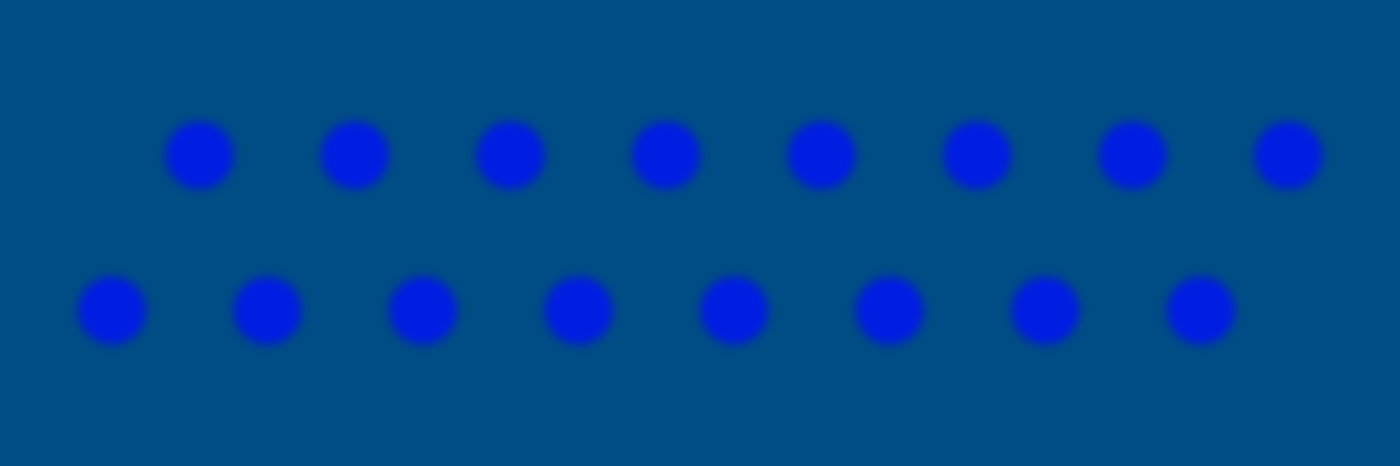

In [ ]:
lambda_ref_mean = 472.
lambda_ref_std = 80.
lambda_dev = -0.0
lambda_std = 2.
opts = {"N_height": N_height, "N_width": N_width, # image size
        "N_H": N_H, "N_W": N_W, # grid size
        "shape_mode": 'circle', "n_sides": 6, "angle0": 0., # shapes
        "size_mag": .17, # size of the shapes
        "relative_luminance": .55, 
        "lambda_ref_mean": lambda_ref_mean, "lambda_ref_std": lambda_ref_std,
        "lambda_dev": lambda_dev, "lambda_std": lambda_std, # deviation from reference and std of wavelengths
        }

@disp
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts)

### Baseline Stimulus as files

Saving as PDF and SVG allows for high-quality reproduction of the stimulus, which is essential for both publication and experimental presentation. The baseline stimulus serves as a control against which all variations will be measured.



Let's start with the pale variant

rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


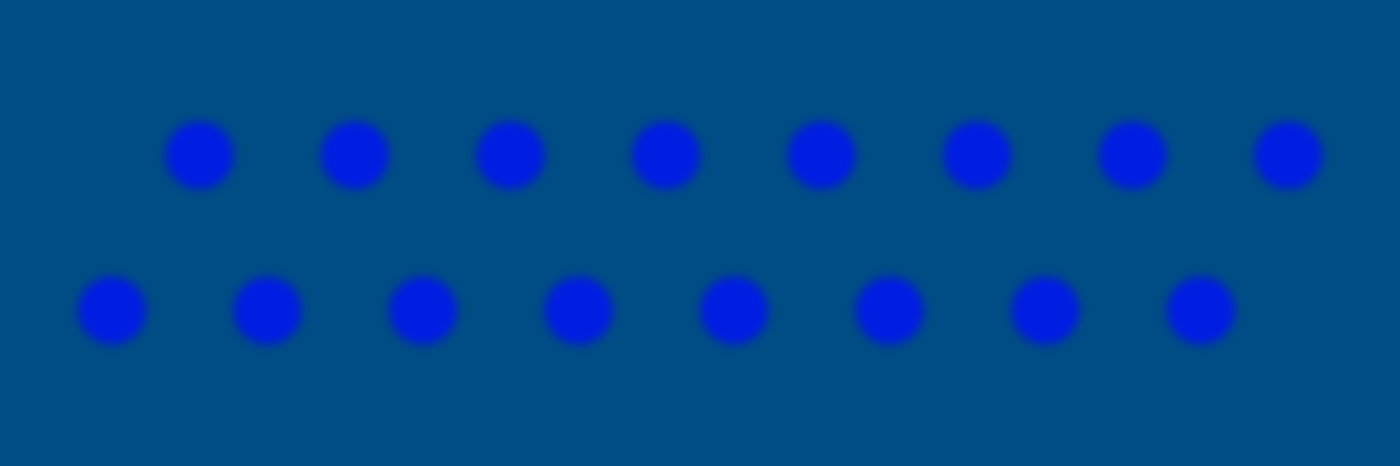

In [ ]:
opts_pale = {"N_height": N_height, "N_width": N_width, # image size
        "N_H": N_H, "N_W": N_W, # grid size
        "shape_mode": 'circle', "n_sides": 6, "angle0": 0., # shapes
        "size_mag": .17, # size of the shapes
        "relative_luminance": .55, 
        "lambda_ref_mean": 497.50, "lambda_ref_std": lambda_ref_std,
        "lambda_dev": lambda_dev, "lambda_std": lambda_std, # deviation from reference and std of wavelengths
        }

@disp
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts)


Let's start with the pale variant

In [29]:
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_pale)
render_svg(draw, savepath + '_pale')
render_pdf(draw, savepath + '_pale')

rgb_ref=array([0.  , 0.76, 0.71]), rgb=array([0.  , 0.78, 0.55]), lambda_ref_mean=497.50, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00
rgb_ref=array([0.  , 0.76, 0.71]), rgb=array([0.  , 0.78, 0.55]), lambda_ref_mean=497.50, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


And now the baseline variant:

In [30]:
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts)
render_pdf(draw, savepath)
render_svg(draw, savepath)

rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


## Parameter Sweeps

We now systematically vary one control variable while keeping all others fixed. This isolates the causal effect of each parameter on the ambiguity illusion and reveals the boundaries where the foveal/peripheral distinction is most pronounced.

In [31]:
N_scan = 9

### Scan Analysis: Dot Size (`size_mag`)

**Variable:** We vary the relative size of the dots on a geometric scale.
**Implementation:** The `size_mag` parameter is scaled across a range (e.g., $0.1$ to $0.4$), affecting the radius of every dot in the lattice.
**Perceptual Effect:** Very small dots may fall below the visibility threshold globally, while very large dots become robustly visible even in the periphery due to their high local contrast. 

**Verification:** The most effective "ambiguity" occurs at intermediate sizes where foveal sampling resolves the fine contours of a dot, but peripheral integration smooths them into a continuous texture. Look for the size where the center is clearly "dotted" but the edges feel "cloudy."

size_mag_=1.00e-01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


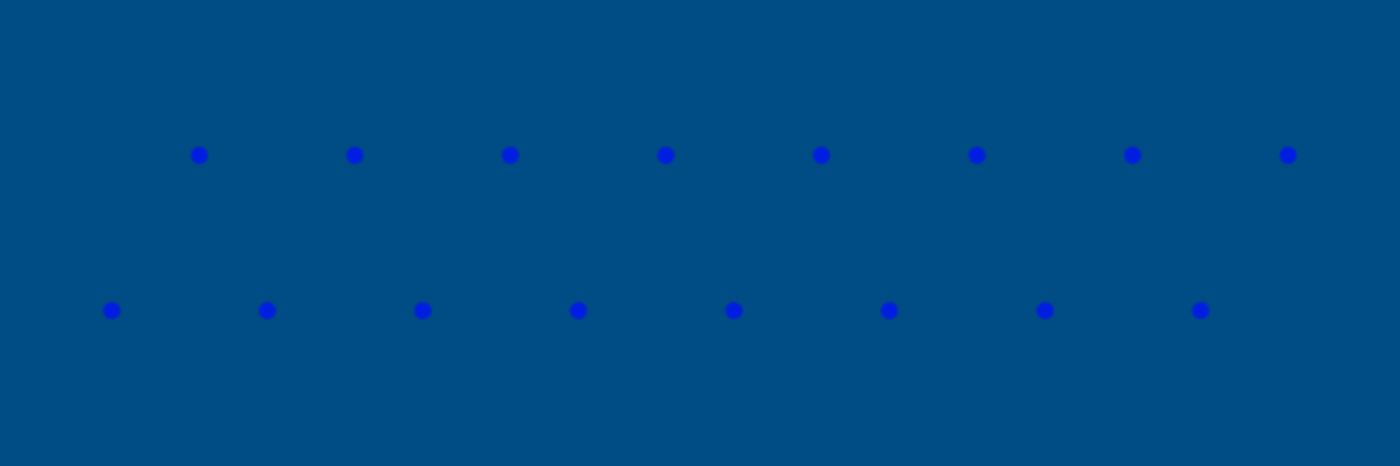

size_mag_=1.15e-01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


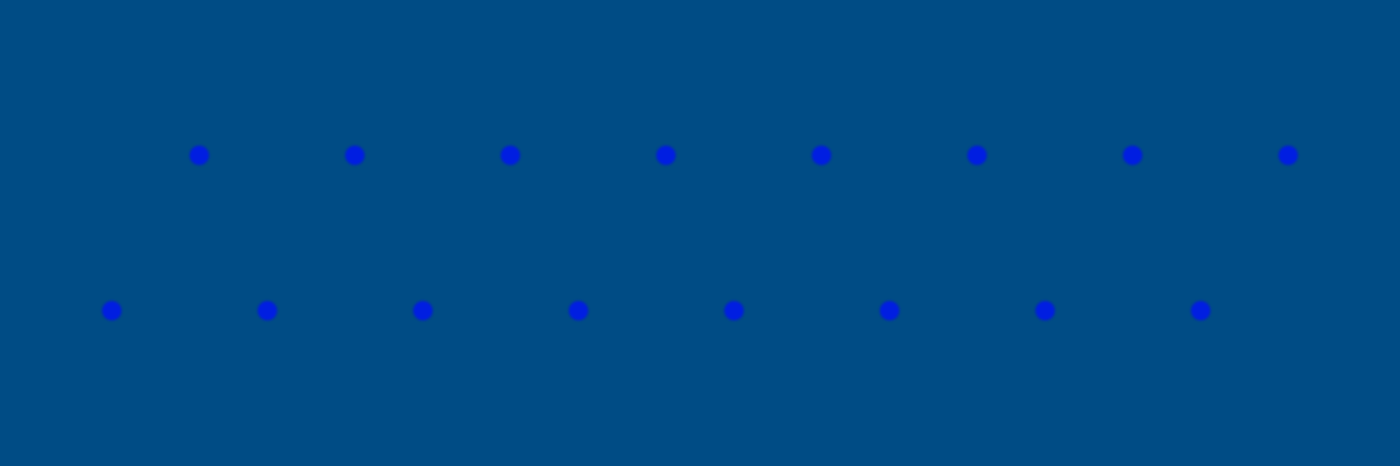

size_mag_=1.32e-01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


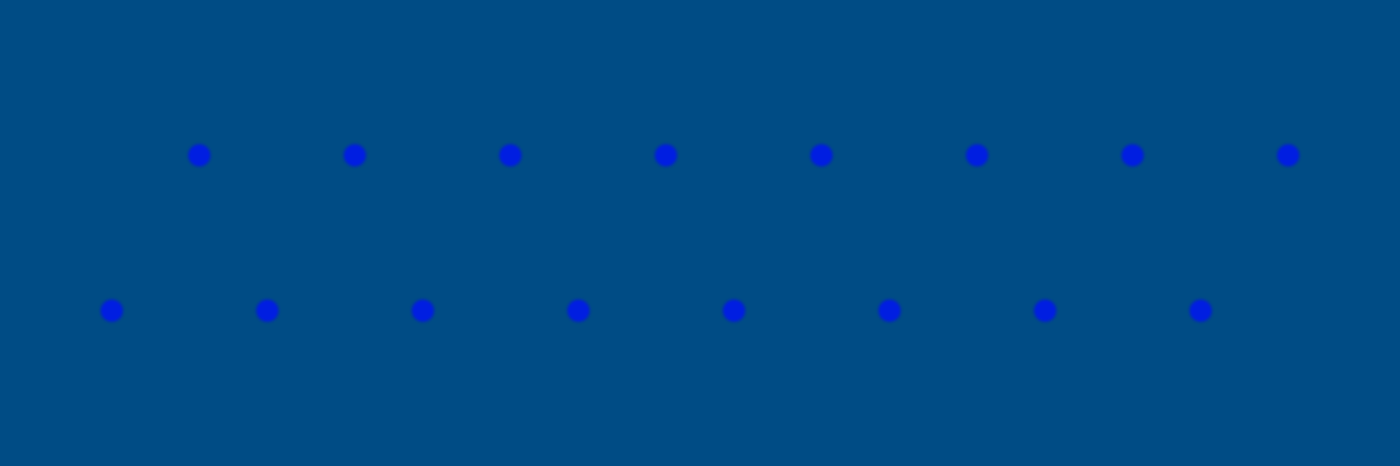

size_mag_=1.51e-01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


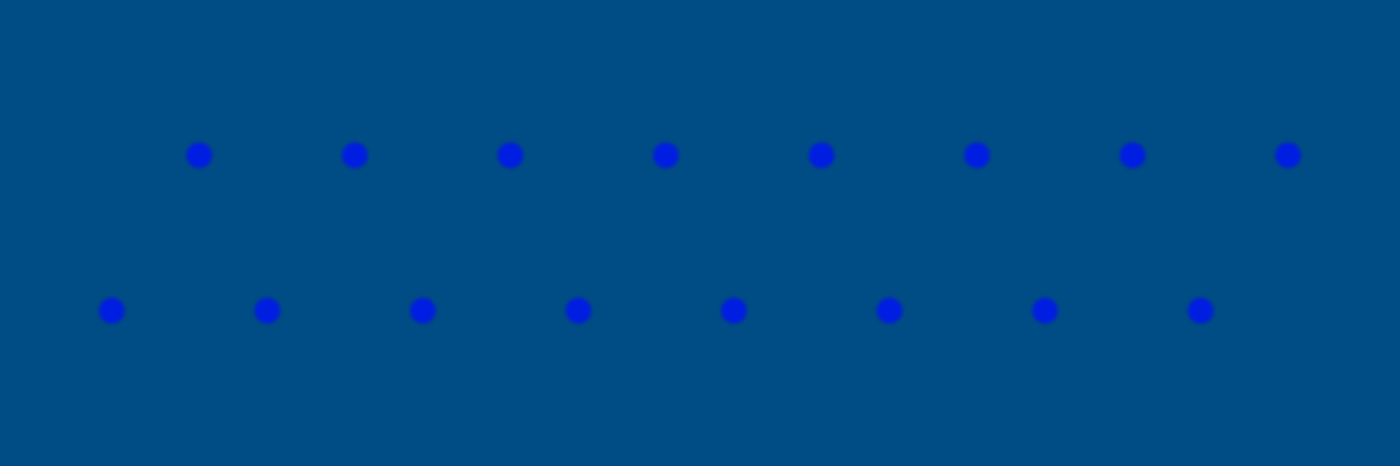

size_mag_=1.73e-01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


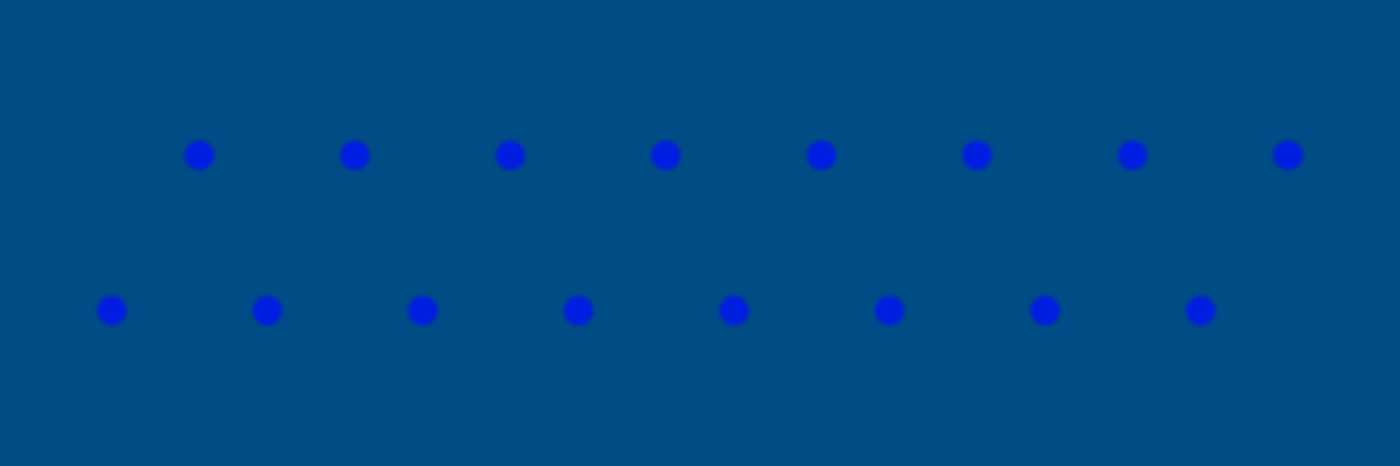

size_mag_=1.99e-01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


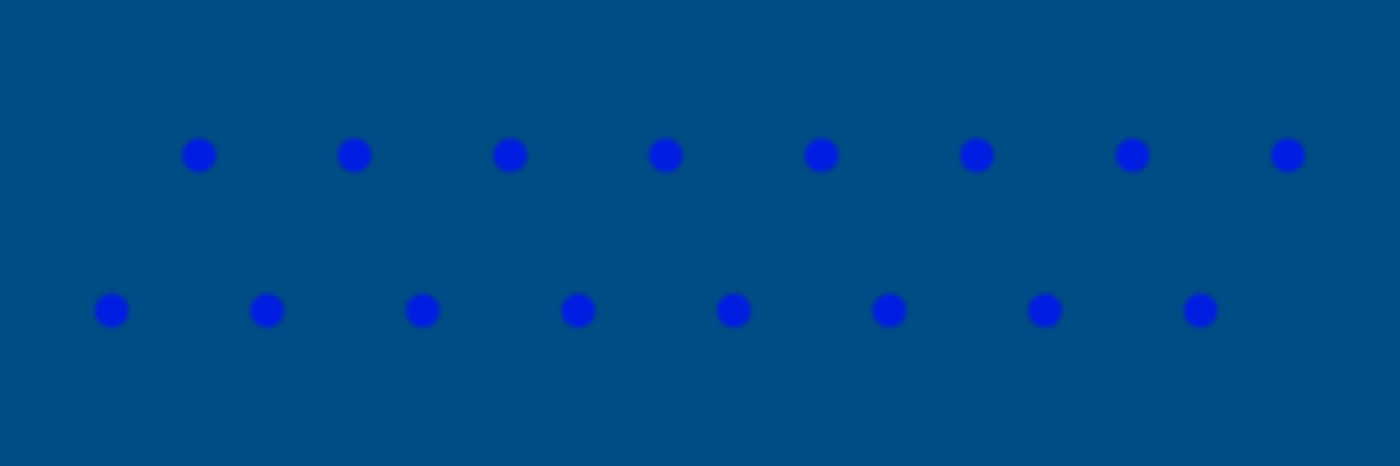

size_mag_=2.28e-01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


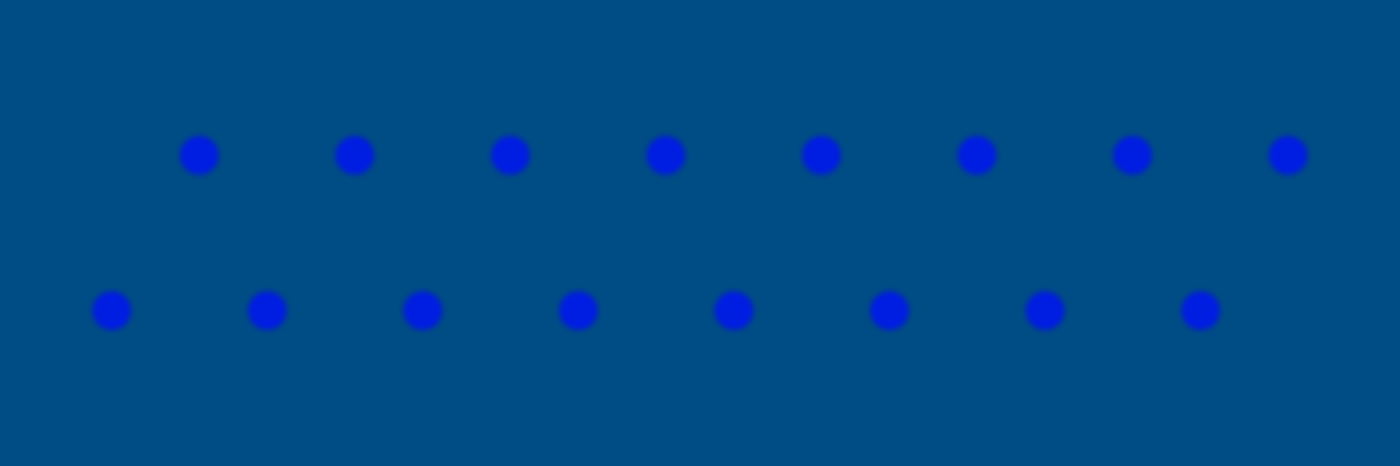

size_mag_=2.62e-01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


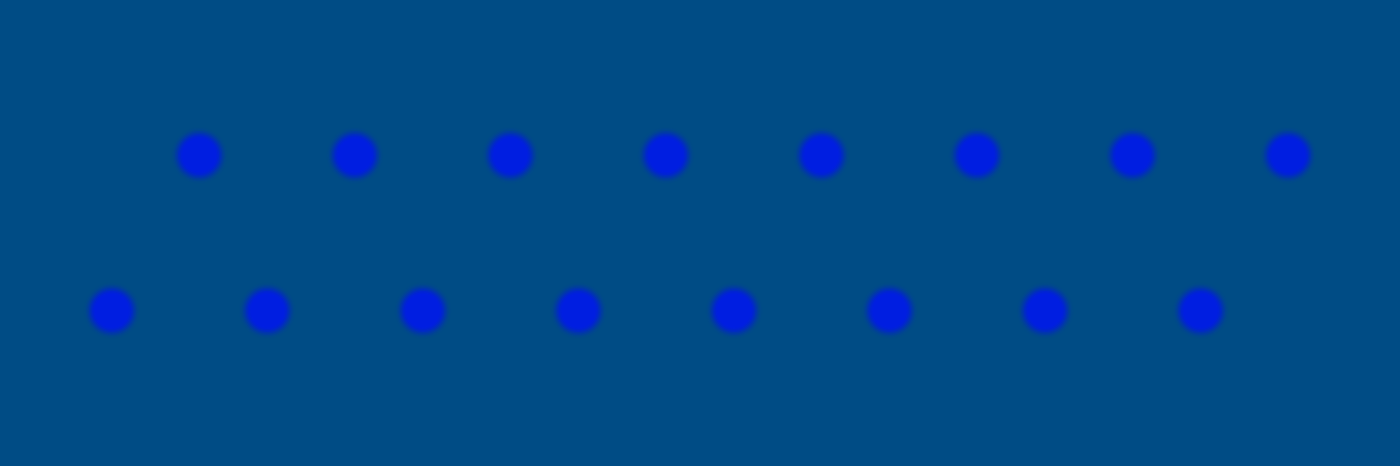

size_mag_=3.00e-01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


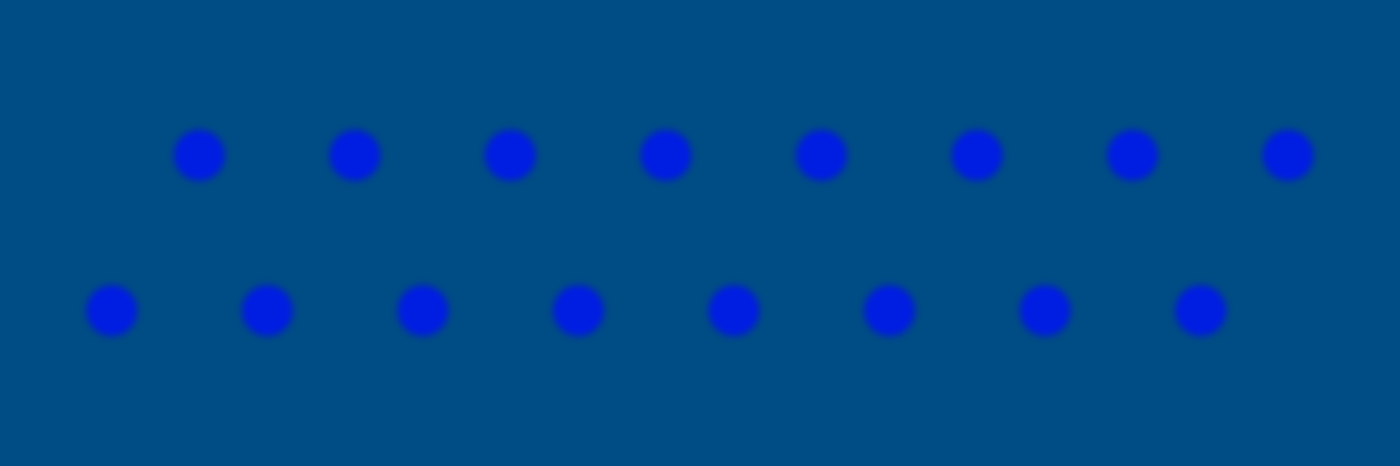

In [32]:
opts_ = opts.copy()
# for size_mag_ in np.geomspace(0.7, 1.4, N_scan): 
for size_mag_ in np.geomspace(0.10, .30, N_scan): 
    opts_.update(size_mag=size_mag_)
    print(f'{size_mag_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: Relative luminance

**Variable:** We scale the `relative_luminance` factor that controls the isoluminant brightness of both dots and background.
**Implementation:** `relative_luminance` is swept linearly from $0.1$ to $1.1$, multiplying the minimum luminance of the two colors. At low values, both dot and background are dark; at high values, they become brighter.
**Perceptual Effect:** The relative luminance determines how strongly the dot pattern stands out. Too dim, and the lattice is unresolved even at fixation. Too bright, and dots become visible everywhere, destroying the center-periphery dissociation. An intermediate range allows foveal vision to resolve individual elements while peripheral vision perceives a unified texture.

**Verification:** Look for the luminance level where the dot lattice is clearly segmented at fixation but collapses into a blurred background toward the edges.

relative_luminance_=0.15
rgb_ref=array([0.  , 0.16, 0.37]), rgb=array([0.  , 0.  , 0.71]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


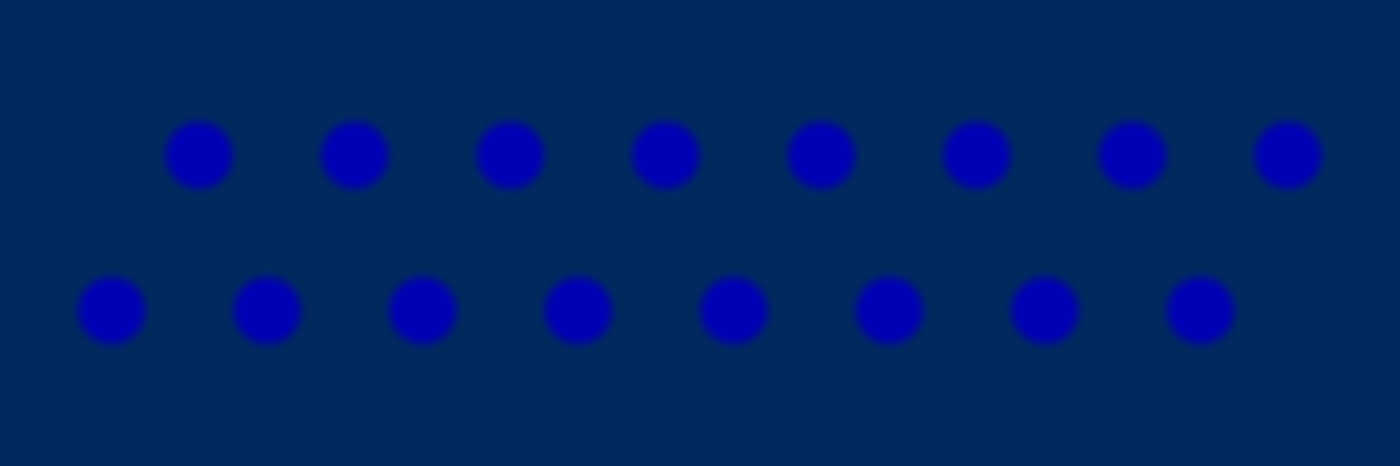

relative_luminance_=0.27
rgb_ref=array([0.  , 0.22, 0.43]), rgb=array([0.  , 0.02, 0.78]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


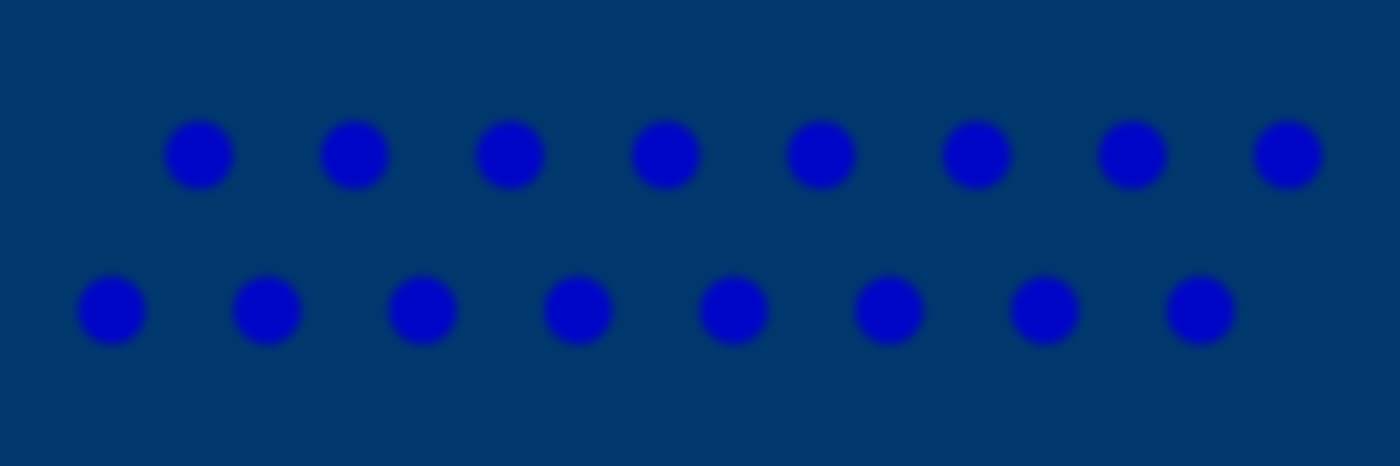

relative_luminance_=0.39
rgb_ref=array([0.  , 0.26, 0.47]), rgb=array([0.  , 0.07, 0.83]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


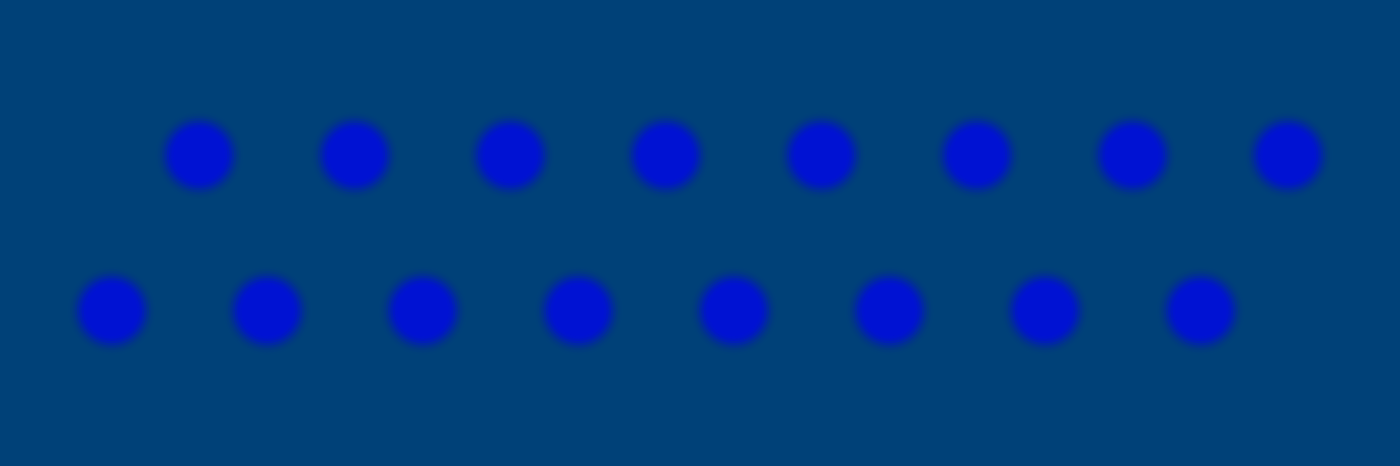

relative_luminance_=0.51
rgb_ref=array([0.  , 0.29, 0.51]), rgb=array([0.  , 0.11, 0.87]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


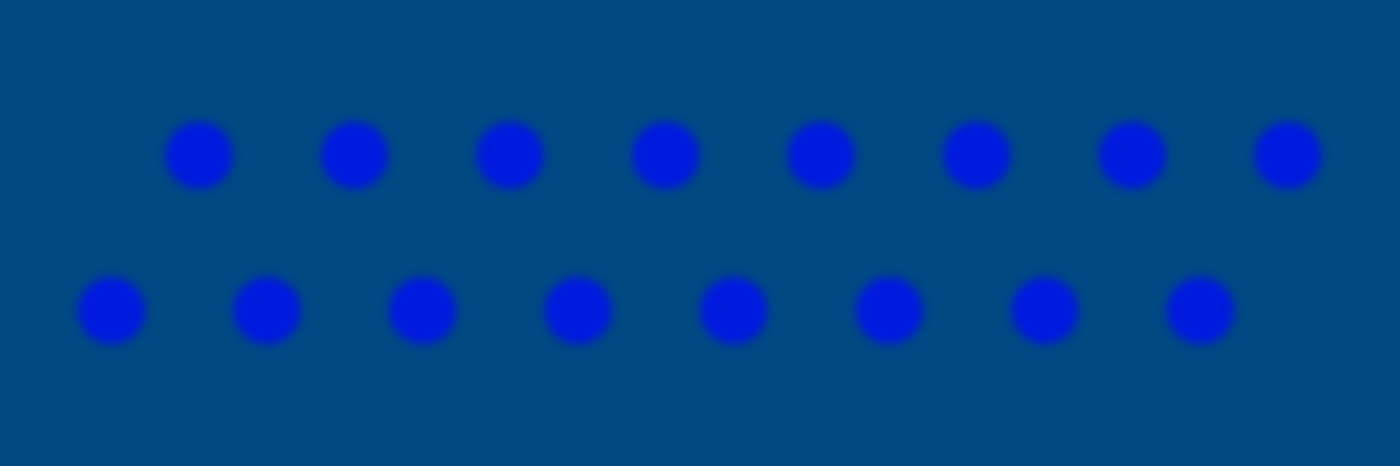

relative_luminance_=0.62
rgb_ref=array([0.  , 0.32, 0.54]), rgb=array([0.  , 0.14, 0.91]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


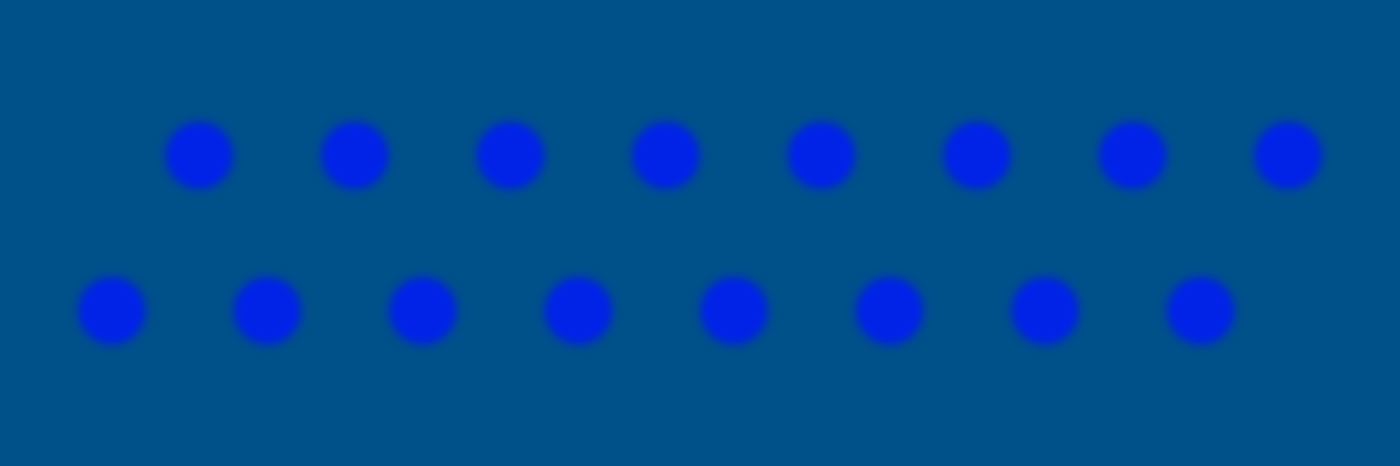

relative_luminance_=0.74
rgb_ref=array([0.  , 0.34, 0.57]), rgb=array([0.  , 0.16, 0.94]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


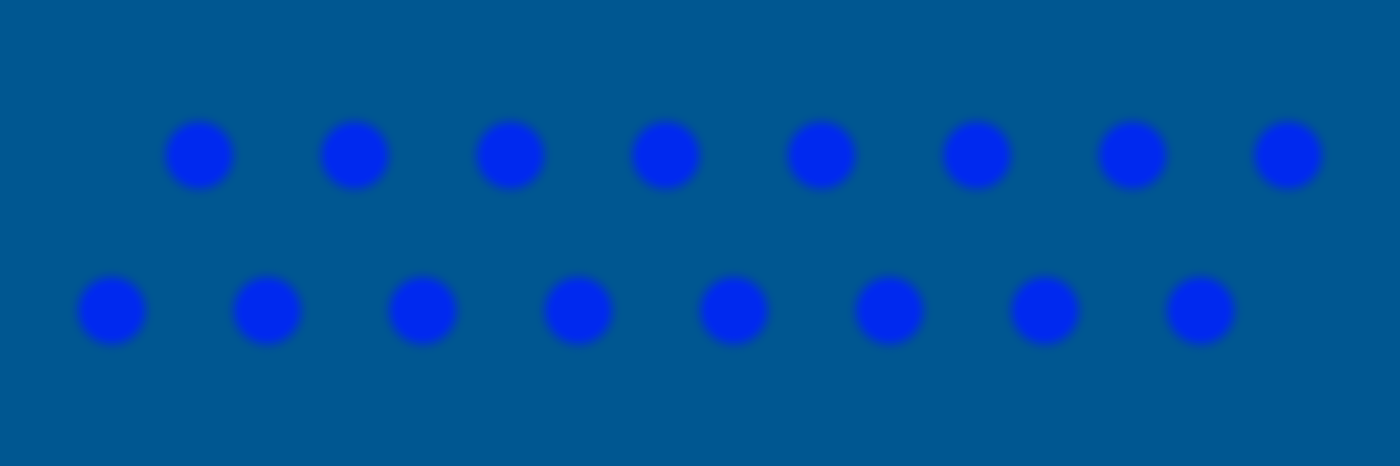

relative_luminance_=0.86
rgb_ref=array([0.  , 0.36, 0.59]), rgb=array([0.  , 0.19, 0.97]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


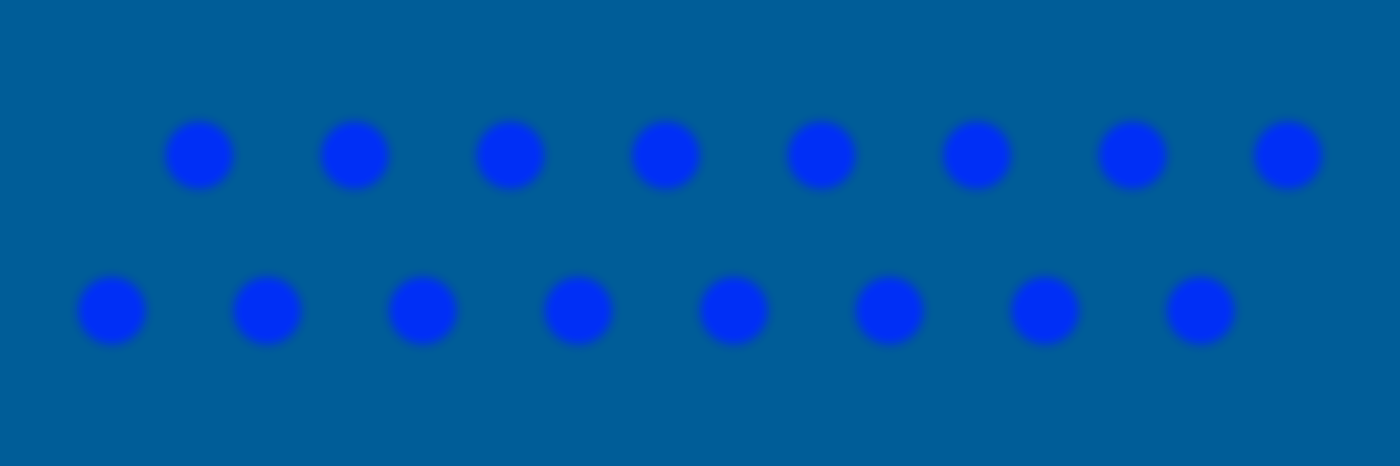

relative_luminance_=0.98
rgb_ref=array([0.  , 0.39, 0.62]), rgb=array([0.  , 0.21, 1.  ]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


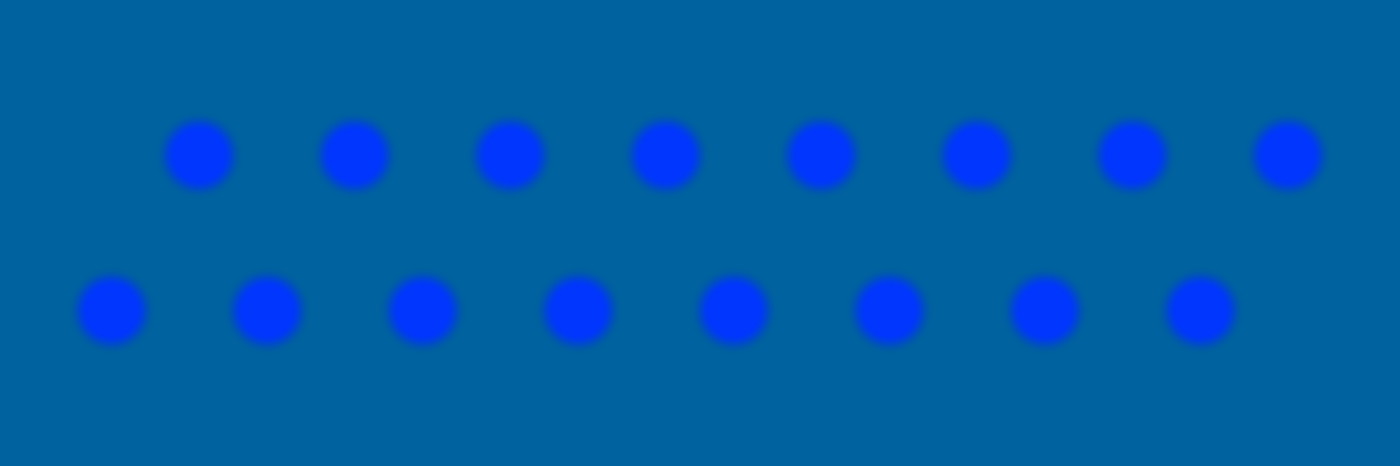

relative_luminance_=1.10
rgb_ref=array([0.  , 0.41, 0.64]), rgb=array([0.11, 0.23, 1.  ]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


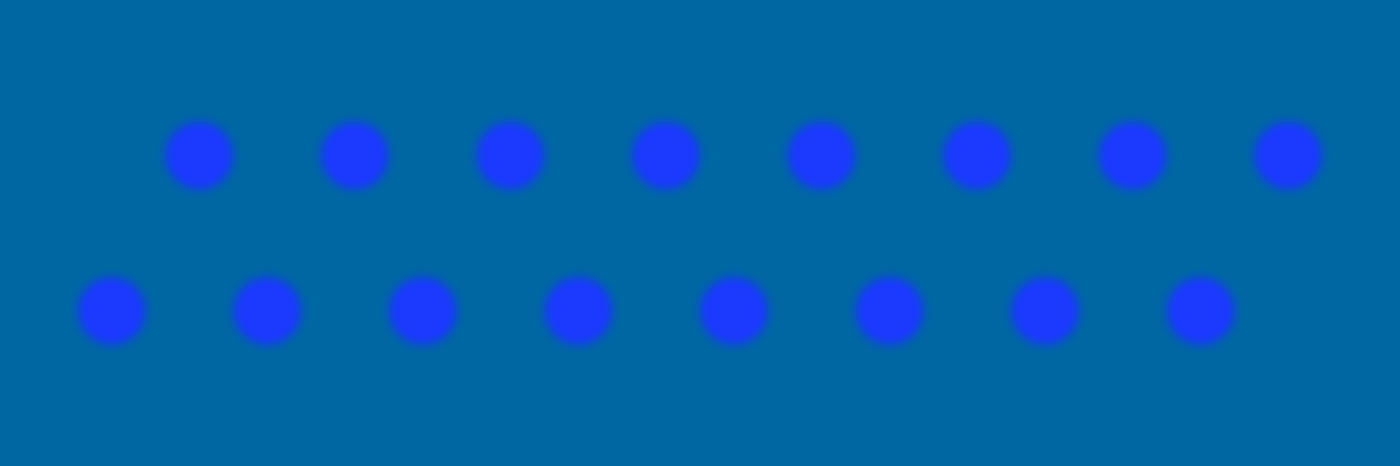

In [33]:
opts_ = opts.copy()
for relative_luminance_ in np.linspace(0.15, 1.1, N_scan): 
    opts_.update(relative_luminance=relative_luminance_)
    print(f'{relative_luminance_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

relative_luminance_=0.46
rgb_ref=array([0.  , 0.28, 0.49]), rgb=array([0.  , 0.09, 0.86]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


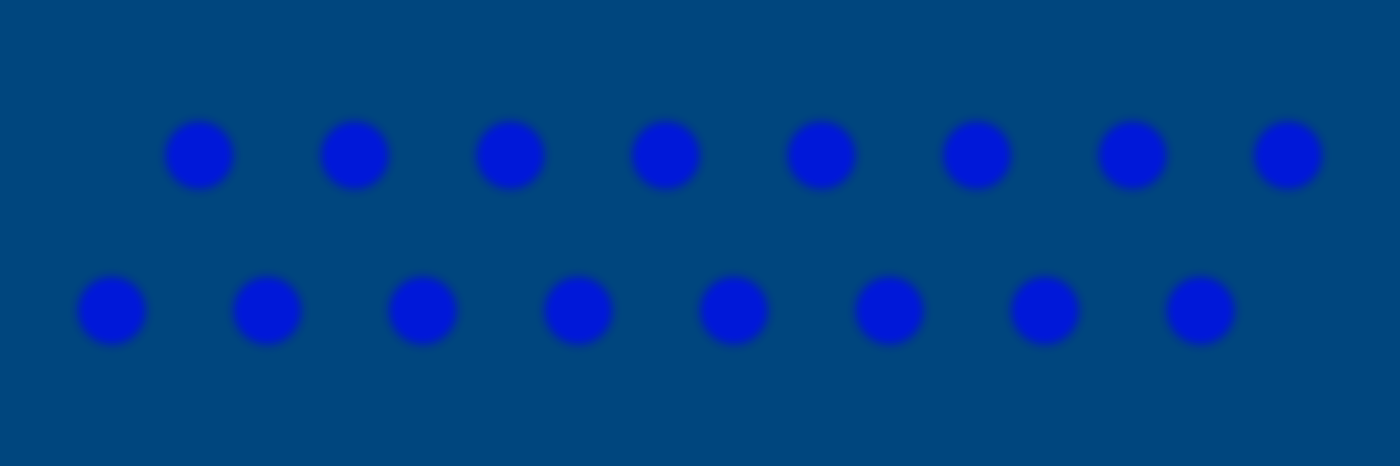

relative_luminance_=0.48
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.1 , 0.87]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


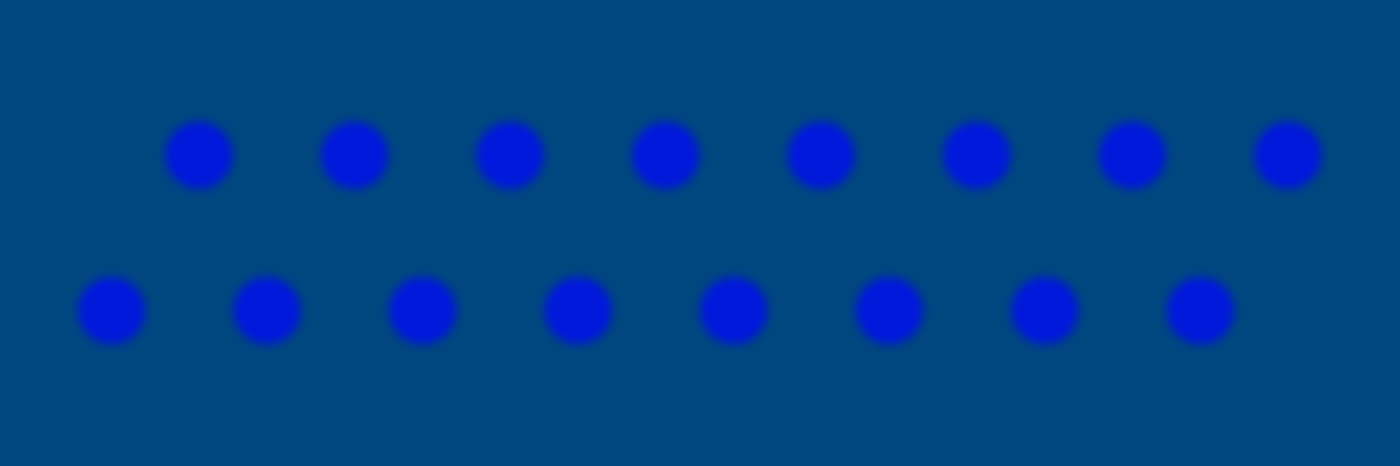

relative_luminance_=0.50
rgb_ref=array([0.  , 0.29, 0.51]), rgb=array([0.  , 0.11, 0.87]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


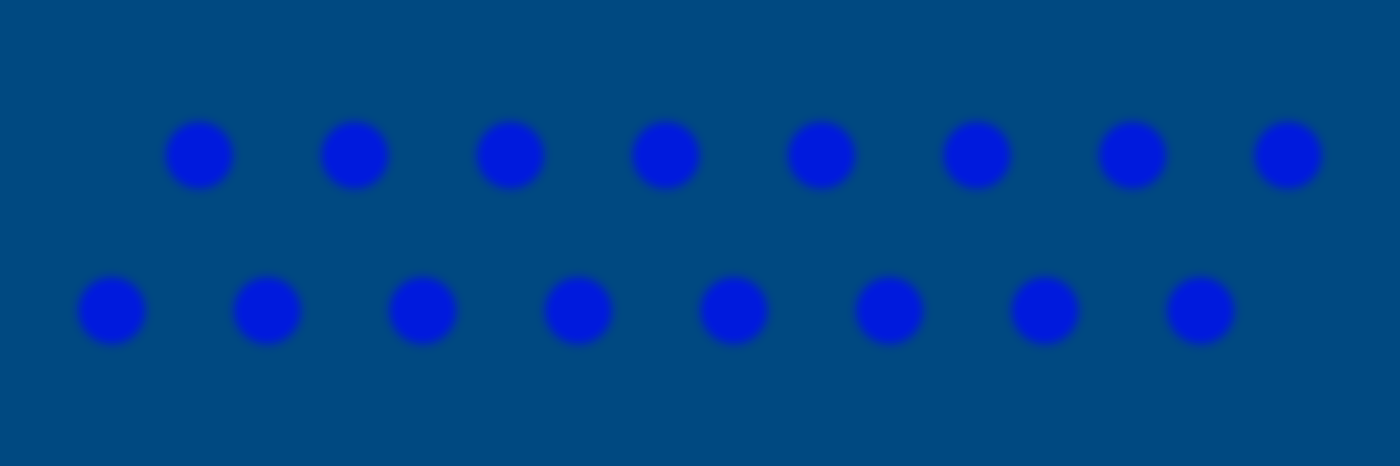

relative_luminance_=0.53
rgb_ref=array([0.  , 0.29, 0.51]), rgb=array([0.  , 0.11, 0.88]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


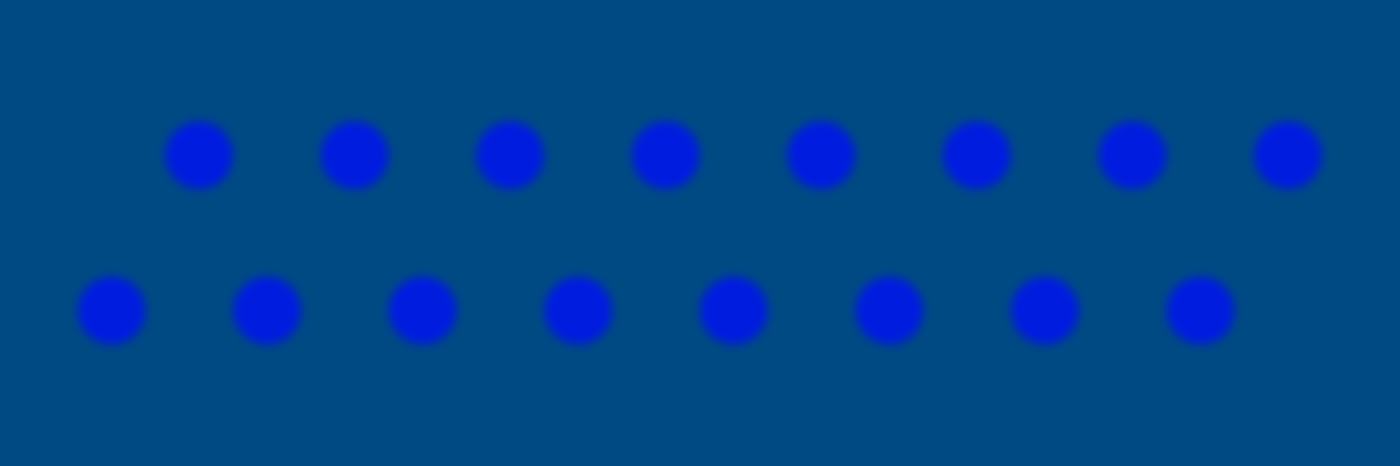

relative_luminance_=0.55
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


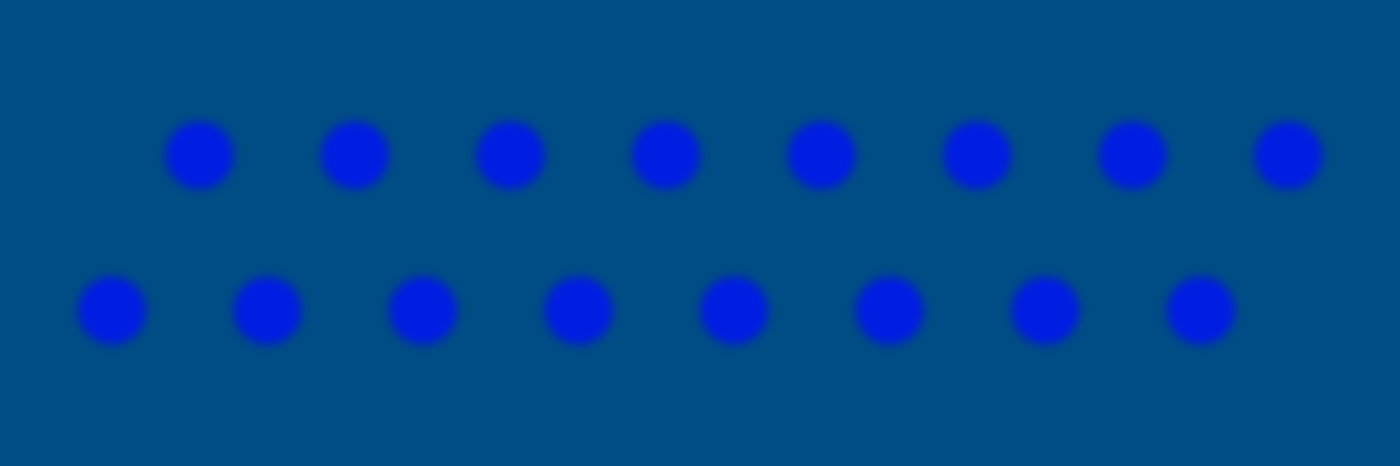

relative_luminance_=0.58
rgb_ref=array([0.  , 0.3 , 0.53]), rgb=array([0.  , 0.12, 0.9 ]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


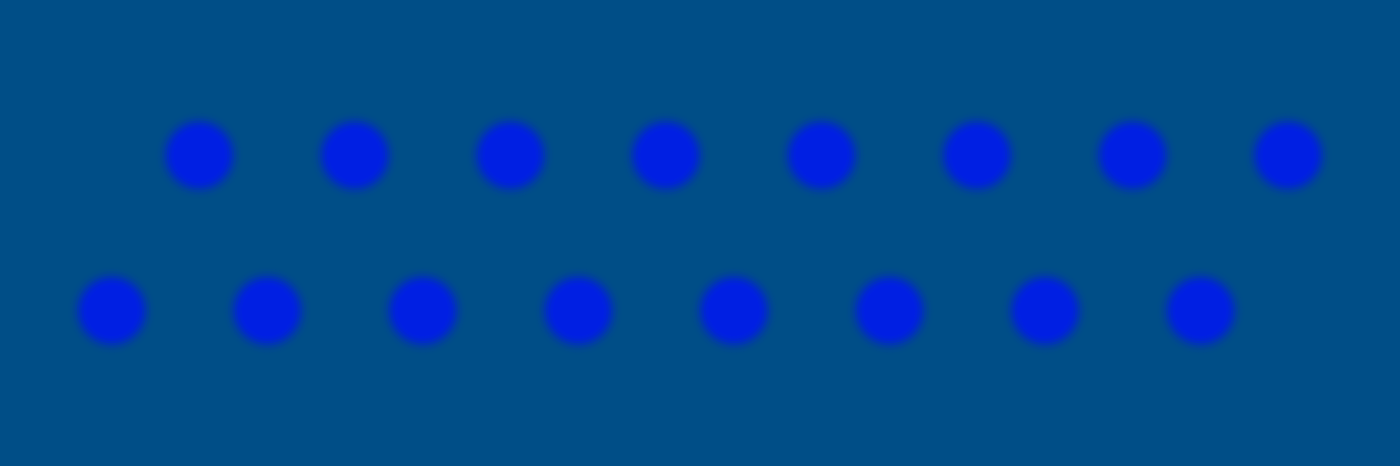

relative_luminance_=0.60
rgb_ref=array([0.  , 0.31, 0.53]), rgb=array([0.  , 0.13, 0.9 ]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


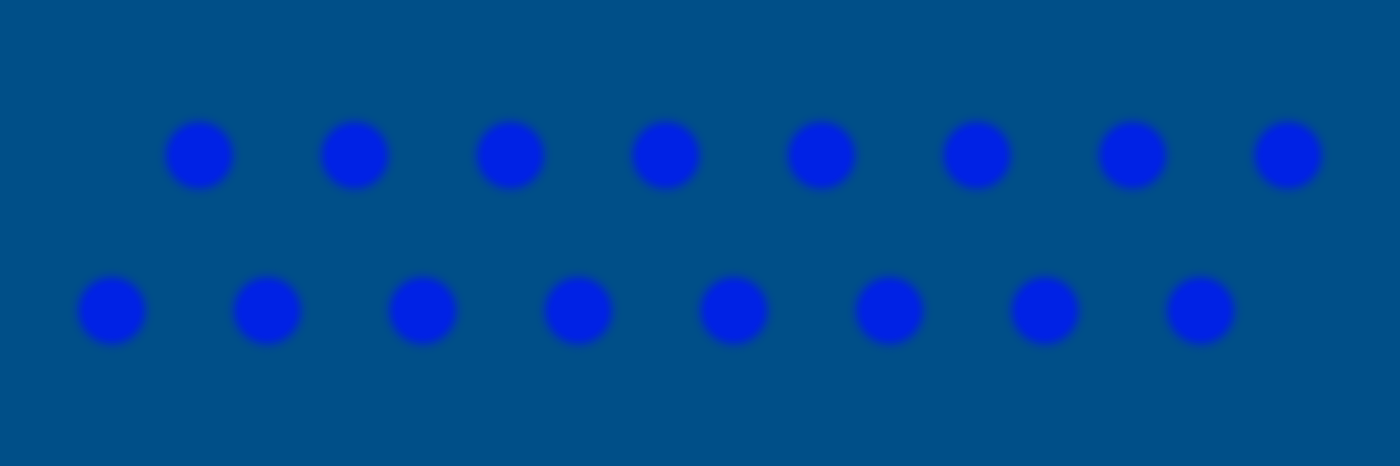

relative_luminance_=0.63
rgb_ref=array([0.  , 0.32, 0.54]), rgb=array([0.  , 0.14, 0.91]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


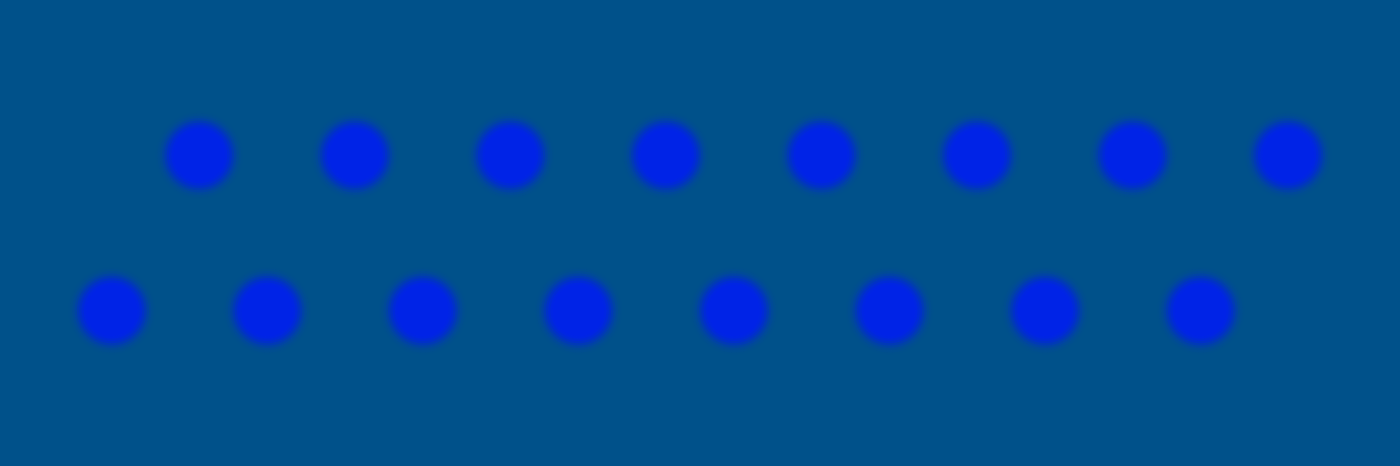

relative_luminance_=0.66
rgb_ref=array([0.  , 0.32, 0.55]), rgb=array([0.  , 0.14, 0.92]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


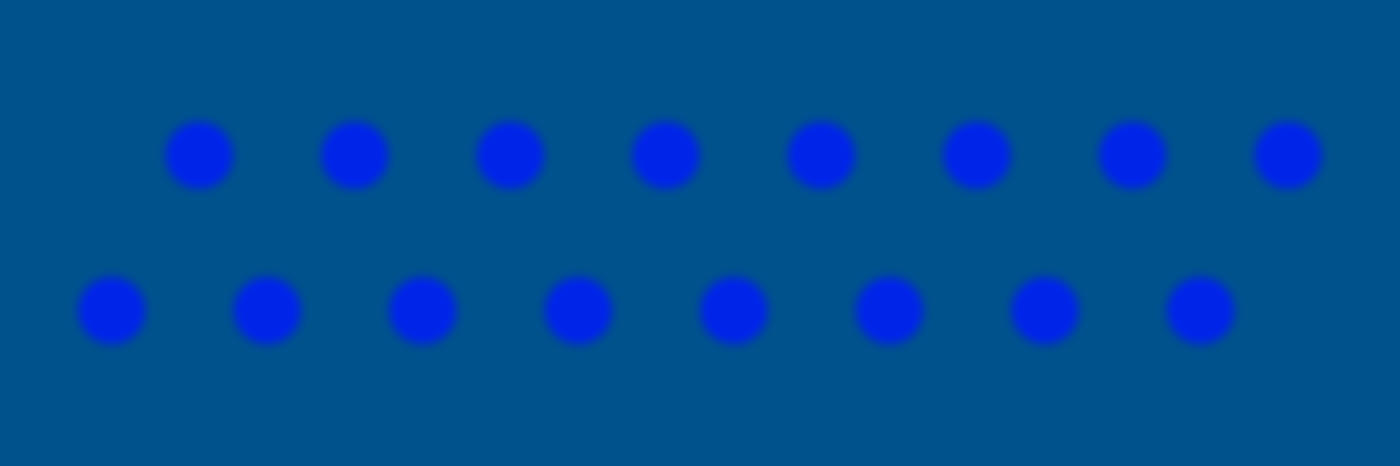

In [34]:
opts_ = opts.copy()
factor = 1.20
for relative_luminance_ in np.geomspace(opts['relative_luminance']/factor, opts['relative_luminance']*factor, N_scan): 
    opts_.update(relative_luminance=relative_luminance_)
    print(f'{relative_luminance_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

### Scan Analysis: Mean Background Hue ($\lambda_{ref\_mean}$)

**Variable:** We rotate the mean wavelength of the background across a range of the visible spectrum.
**Implementation:** $\lambda_{ref\_mean}$ is varied linearly (e.g., $470\text{nm}$ to $580\text{nm}$), shifting the baseline color from blue-green towards yellow.
**Perceptual Effect:** Certain hue sectors enhance the separation between dots and background, while others reduce it. This is due to the specific sensitivity of cone-opponent pathways, which dominate chromatic discrimination at fixation but are less effective in the periphery.

**Verification:** Note how some colors make the dot pattern "pop" more centrally, while other hues cause the entire image to feel flatter or more unified across the field.

lambda_ref_mean_=470.00
rgb_ref=array([0.  , 0.27, 0.52]), rgb=array([0.  , 0.  , 0.89]), lambda_ref_mean=470.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


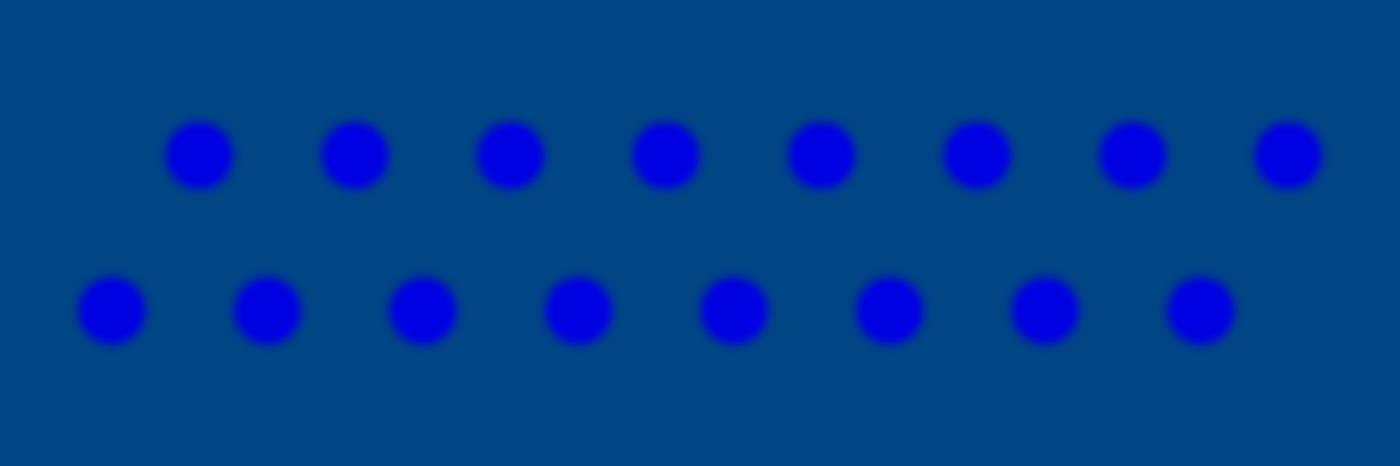

lambda_ref_mean_=483.75
rgb_ref=array([0.  , 0.52, 0.64]), rgb=array([0.  , 0.48, 0.84]), lambda_ref_mean=483.75, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


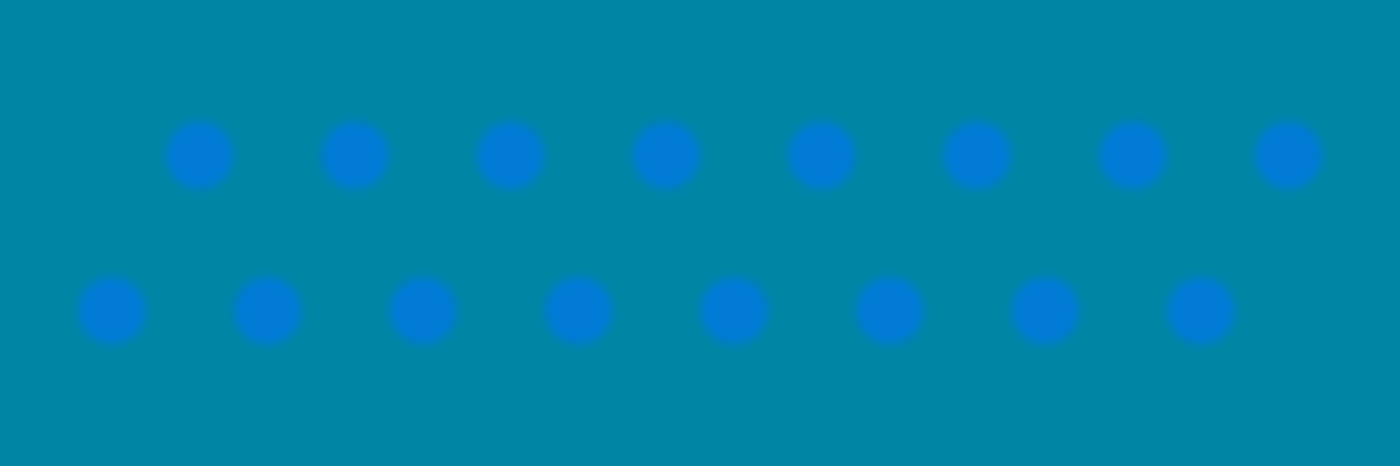

lambda_ref_mean_=497.50
rgb_ref=array([0.  , 0.76, 0.71]), rgb=array([0.  , 0.78, 0.55]), lambda_ref_mean=497.50, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


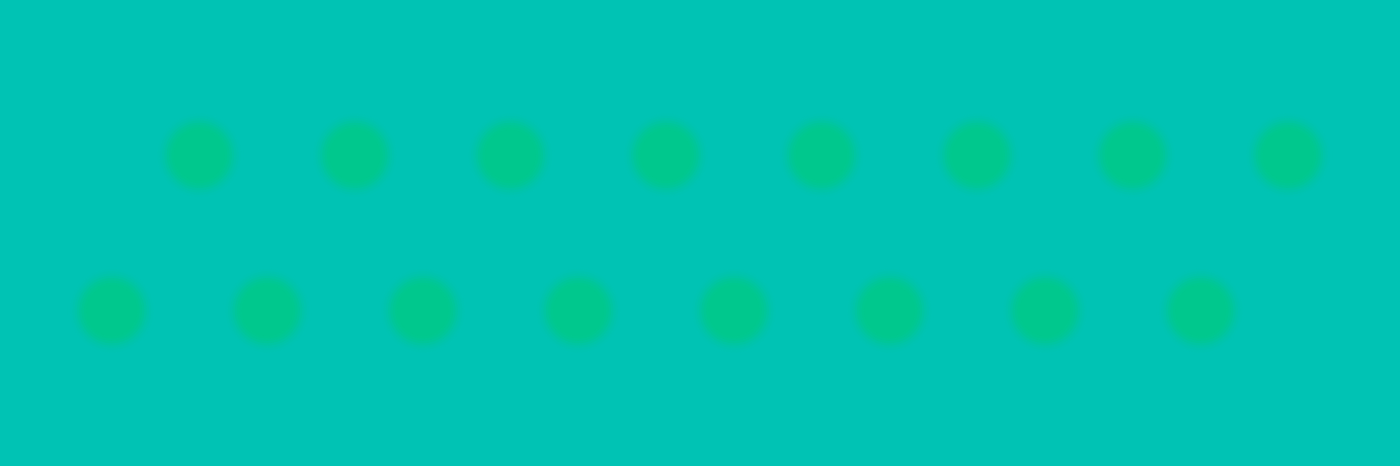

lambda_ref_mean_=511.25
rgb_ref=array([0.06, 0.76, 0.53]), rgb=array([0.  , 0.78, 0.3 ]), lambda_ref_mean=511.25, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


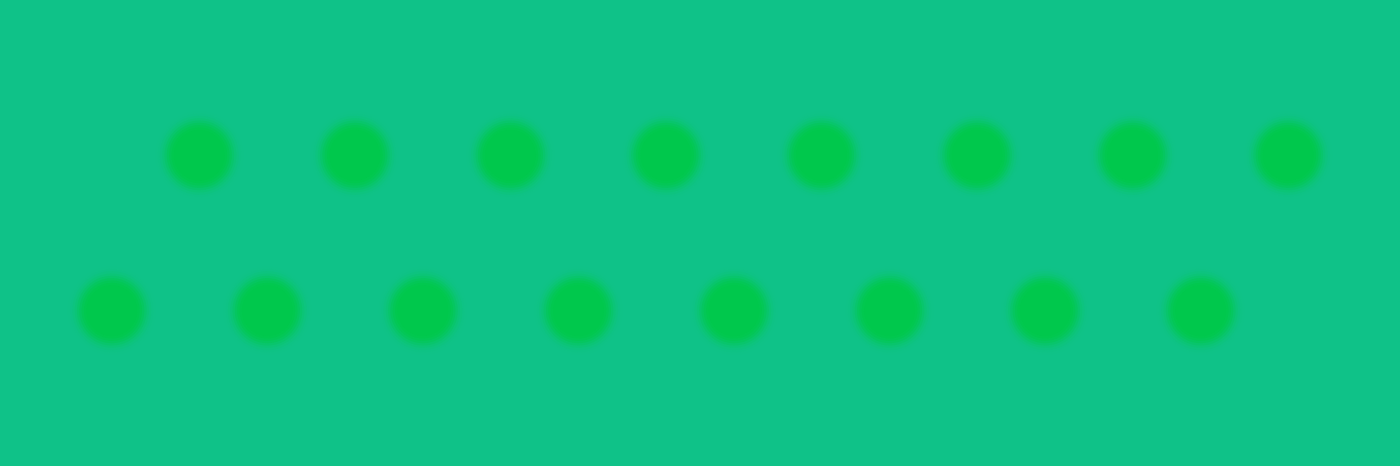

lambda_ref_mean_=525.00
rgb_ref=array([0.29, 0.75, 0.38]), rgb=array([0.  , 0.78, 0.12]), lambda_ref_mean=525.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


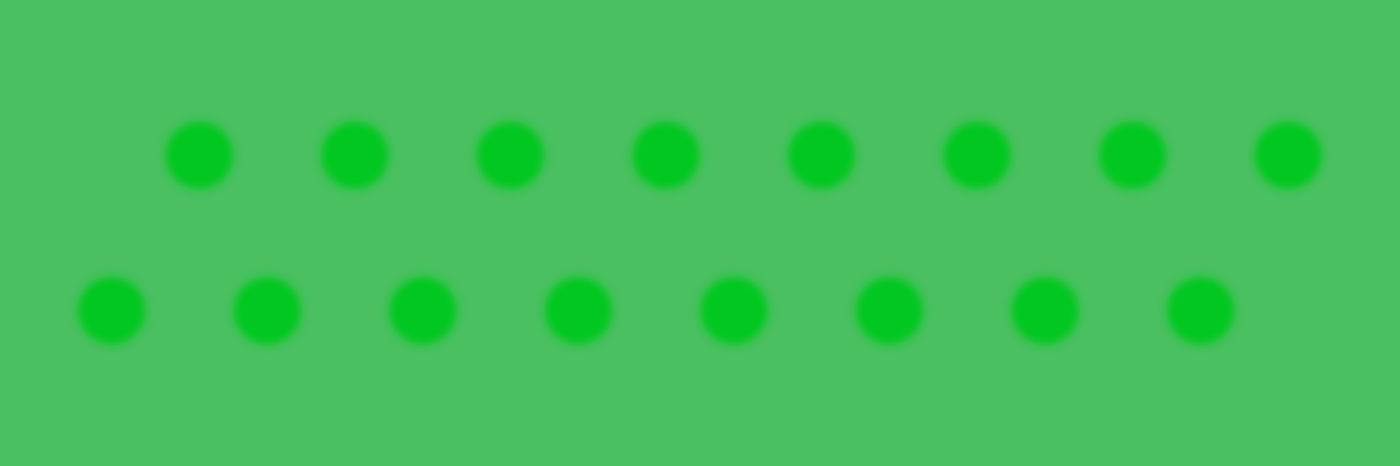

lambda_ref_mean_=538.75
rgb_ref=array([0.44, 0.73, 0.24]), rgb=array([0.  , 0.78, 0.  ]), lambda_ref_mean=538.75, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


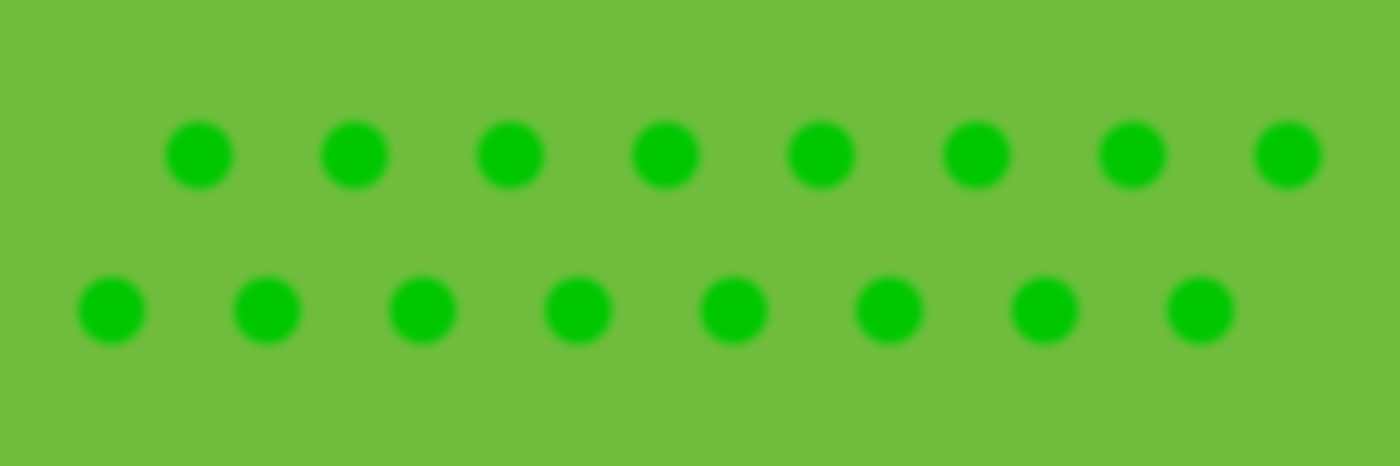

lambda_ref_mean_=552.50
rgb_ref=array([0.58, 0.71, 0.03]), rgb=array([0.  , 0.78, 0.  ]), lambda_ref_mean=552.50, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


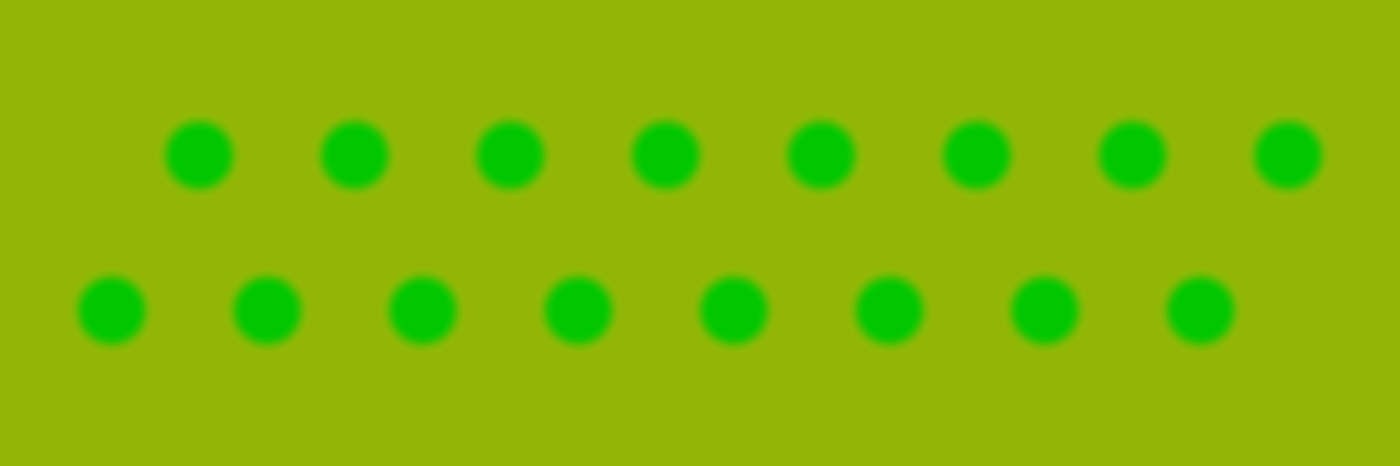

lambda_ref_mean_=566.25
rgb_ref=array([0.76, 0.71, 0.  ]), rgb=array([0.46, 0.78, 0.  ]), lambda_ref_mean=566.25, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


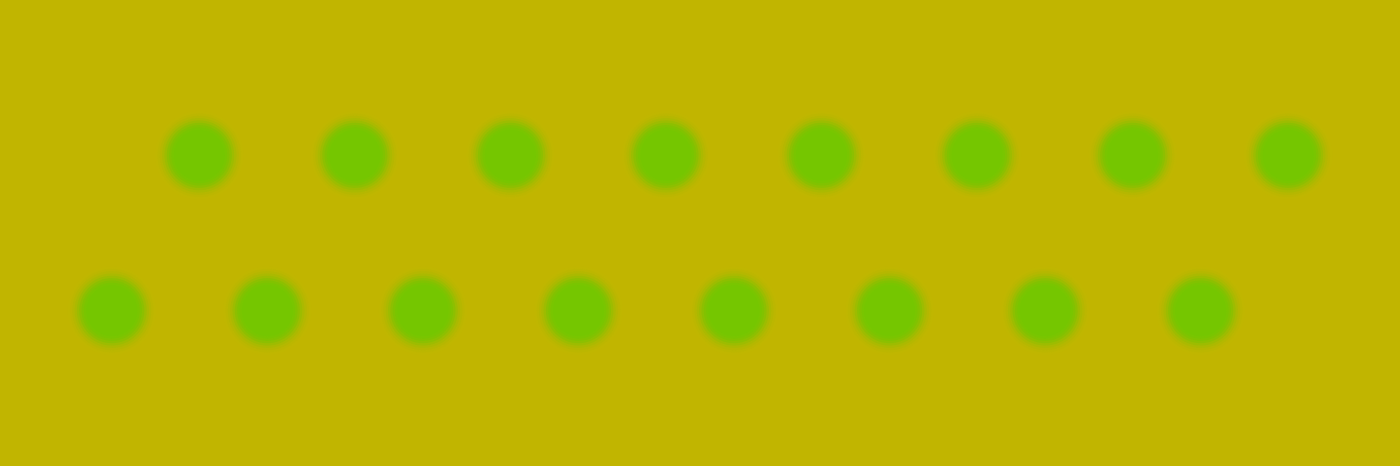

lambda_ref_mean_=580.00
rgb_ref=array([0.63, 0.46, 0.  ]), rgb=array([0.81, 0.34, 0.  ]), lambda_ref_mean=580.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


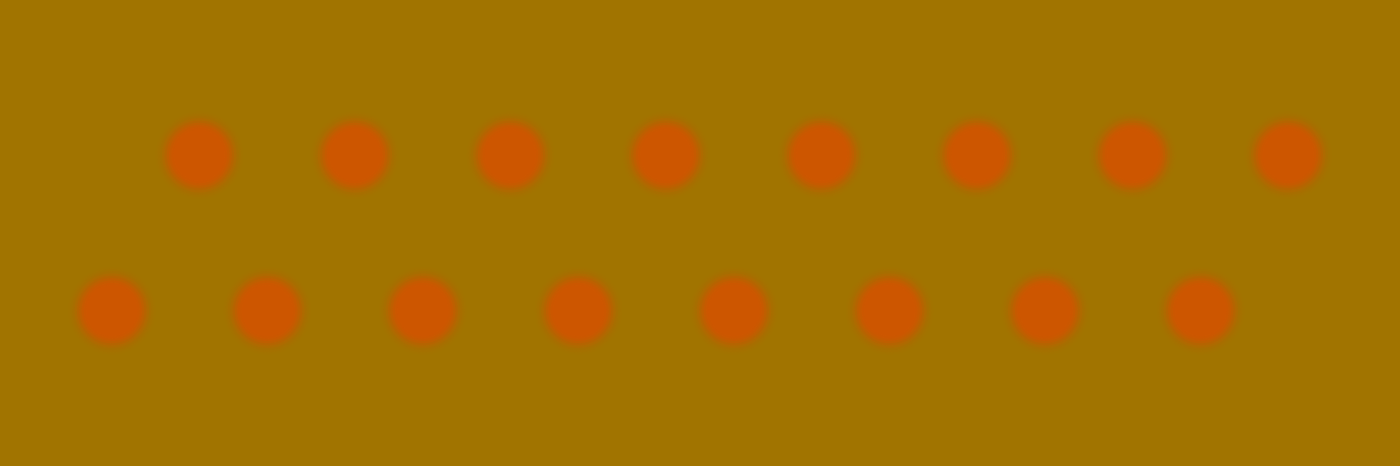

In [35]:
opts_ = opts.copy()
# for lambda_ref_mean_ in np.linspace(450., 650., N_scan, endpoint=False): 
for lambda_ref_mean_ in np.linspace(470., 580., N_scan): 
    opts_.update(lambda_ref_mean=lambda_ref_mean_)
    print(f'{lambda_ref_mean_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

lambda_ref_mean_=468.32
rgb_ref=array([0.  , 0.26, 0.53]), rgb=array([0. , 0. , 0.9]), lambda_ref_mean=468.32, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


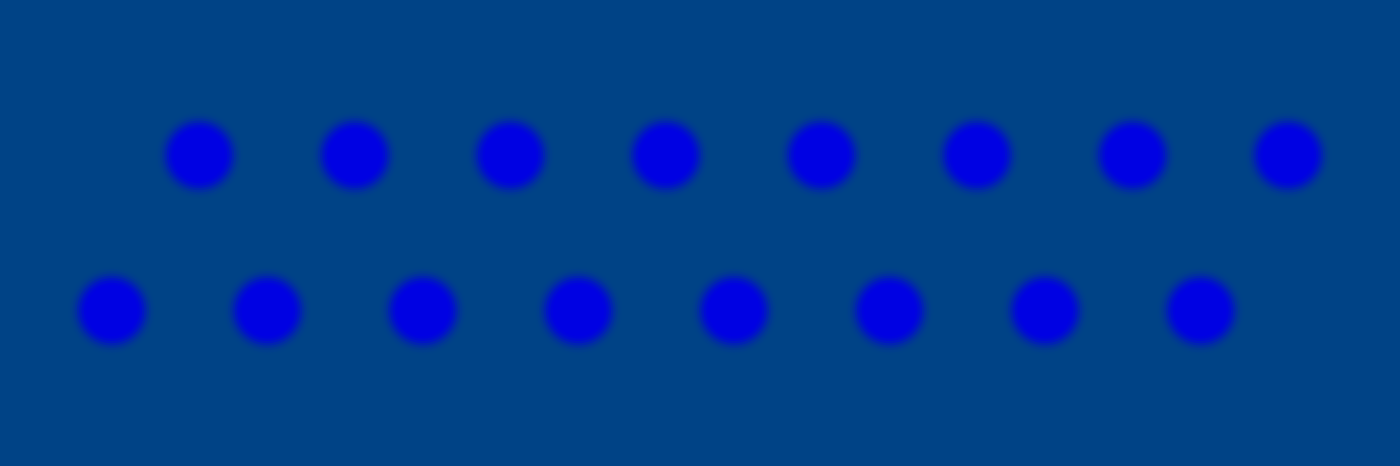

lambda_ref_mean_=469.48
rgb_ref=array([0.  , 0.27, 0.52]), rgb=array([0.  , 0.  , 0.89]), lambda_ref_mean=469.48, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


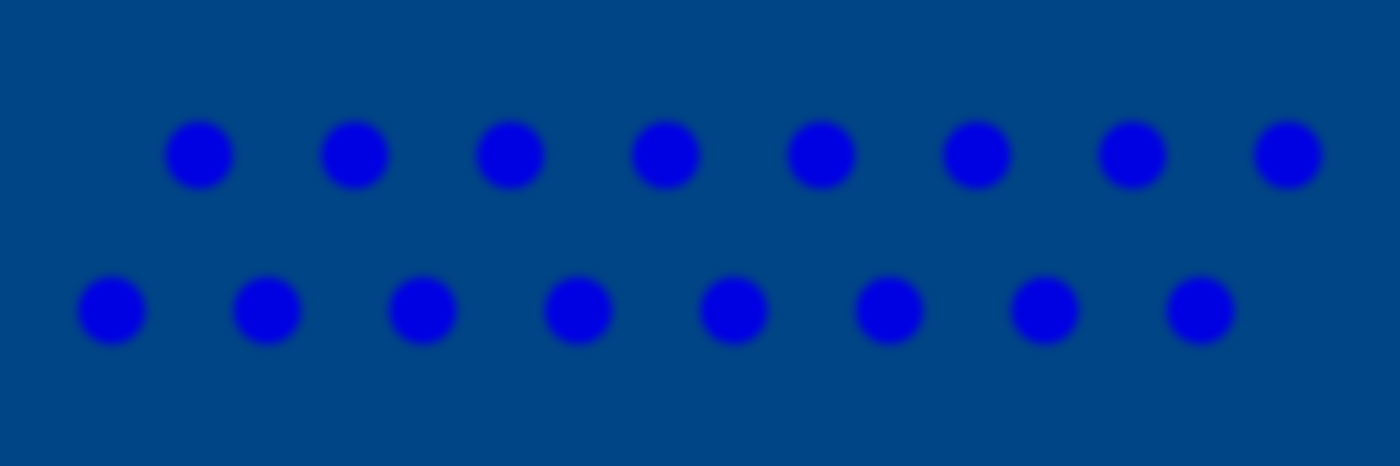

lambda_ref_mean_=470.65
rgb_ref=array([0.  , 0.27, 0.52]), rgb=array([0.  , 0.  , 0.89]), lambda_ref_mean=470.65, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


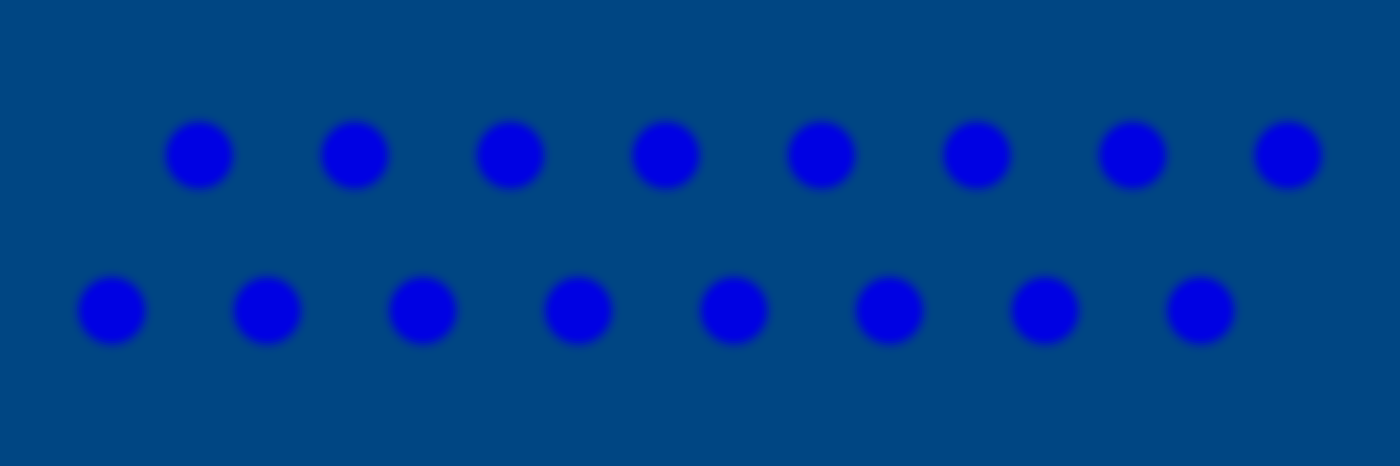

lambda_ref_mean_=471.82
rgb_ref=array([0.  , 0.28, 0.51]), rgb=array([0.  , 0.05, 0.89]), lambda_ref_mean=471.82, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


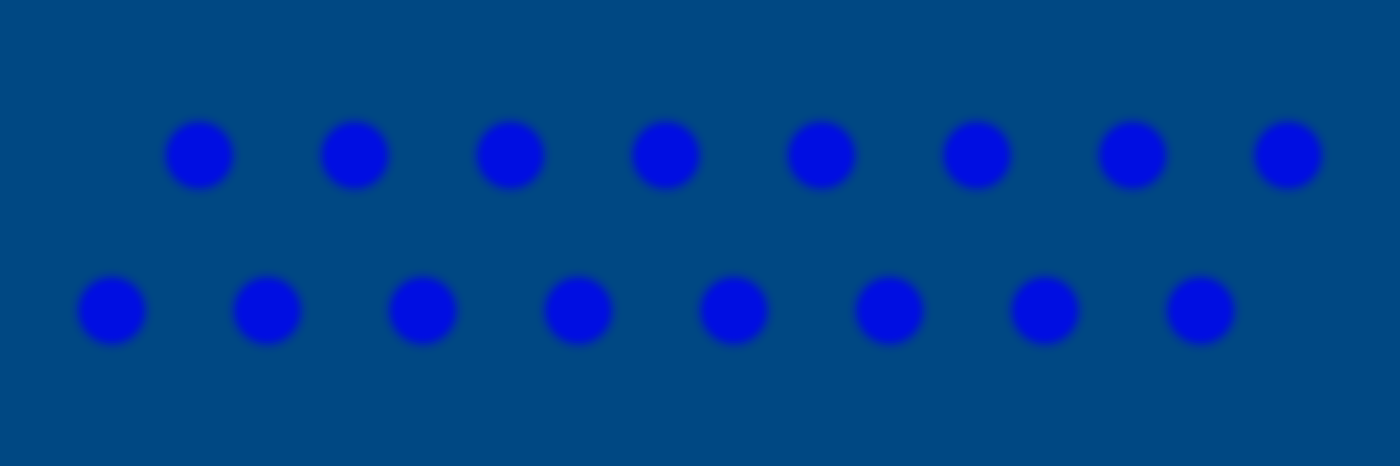

lambda_ref_mean_=473.00
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


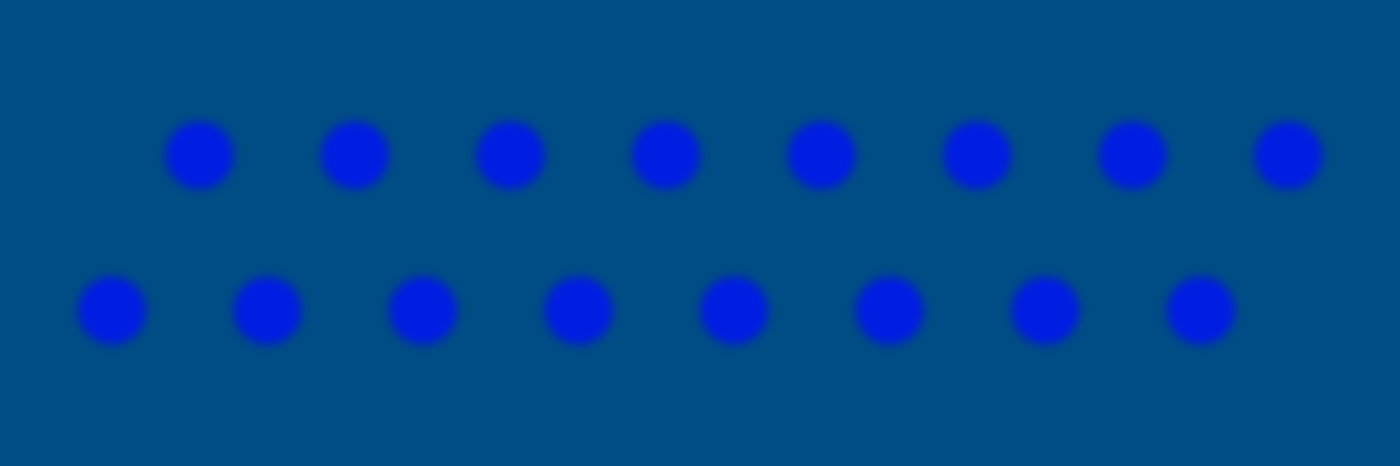

lambda_ref_mean_=474.18
rgb_ref=array([0.  , 0.31, 0.53]), rgb=array([0.  , 0.16, 0.88]), lambda_ref_mean=474.18, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


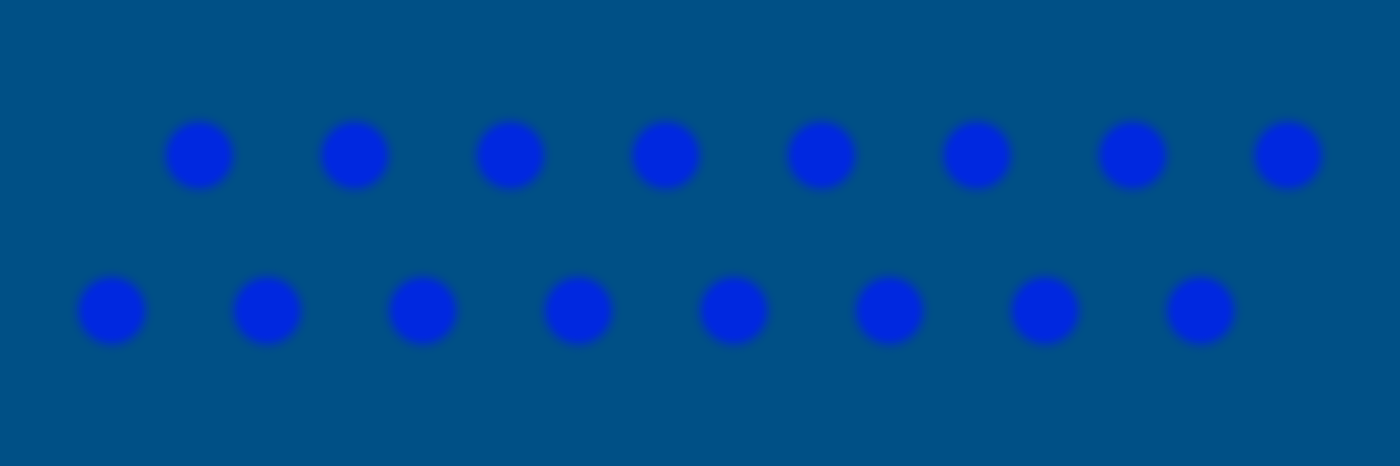

lambda_ref_mean_=475.36
rgb_ref=array([0.  , 0.32, 0.52]), rgb=array([0.  , 0.18, 0.88]), lambda_ref_mean=475.36, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


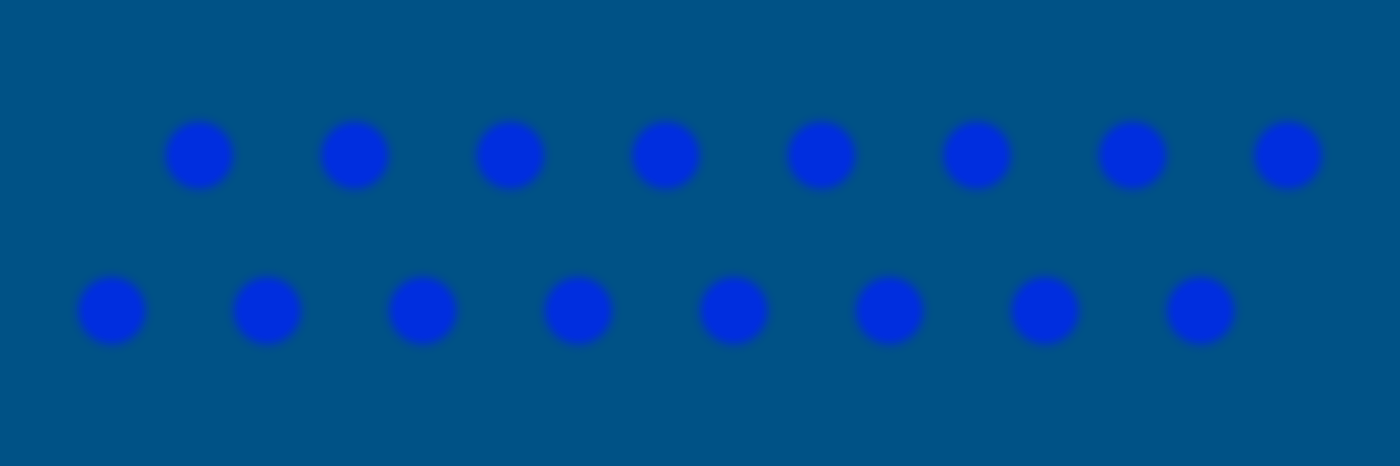

lambda_ref_mean_=476.54
rgb_ref=array([0.  , 0.34, 0.53]), rgb=array([0.  , 0.21, 0.88]), lambda_ref_mean=476.54, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


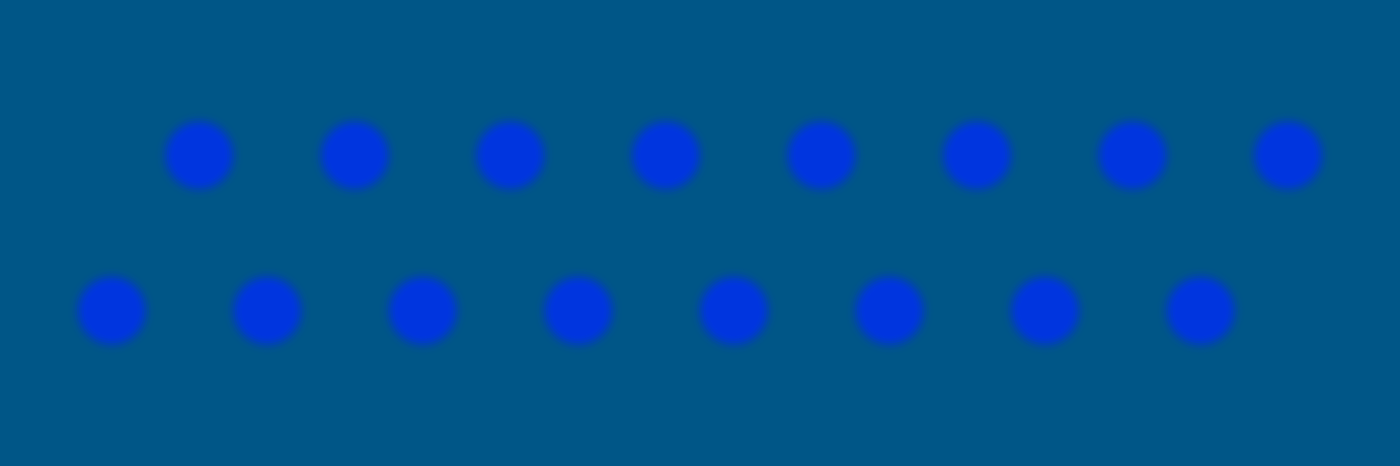

lambda_ref_mean_=477.73
rgb_ref=array([0.  , 0.37, 0.55]), rgb=array([0.  , 0.26, 0.87]), lambda_ref_mean=477.73, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


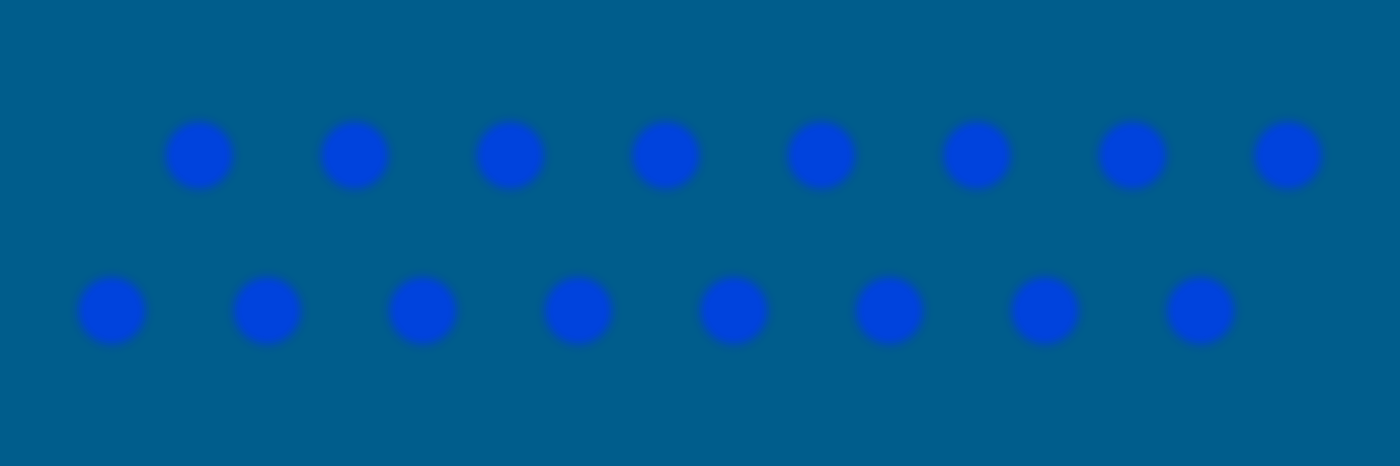

In [36]:
opts_ = opts.copy()
factor = 1.01
for lambda_ref_mean_ in np.geomspace(opts['lambda_ref_mean']/factor, opts['lambda_ref_mean']*factor, N_scan): 
    
    opts_.update(lambda_ref_mean=lambda_ref_mean_)
    print(f'{lambda_ref_mean_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

### Scan Analysis: Background Wavelength Spread ($\lambda_{ref\_std}$)

**Variable:** We vary the standard deviation of wavelengths used to generate the background color.
**Implementation:** $\lambda_{ref\_std}$ is adjusted to control how "pure" or "broadband" the background spectrum is.
**Perceptual Effect:** Low spread results in a highly saturated, pure hue that can create strong global contrast. High spread creates a more neutral, desaturated background. Moderate spread often preserves the central parsing advantage by preventing any single chromatic channel from dominating the peripheral pooling.

**Verification:** Observe if increasing the spread makes the periphery feel "smoother" or "noisier." The ideal setting prevents the background from appearing as a flat wall of color.

lambda_ref_std_=4.00e+01
rgb_ref=array([0.  , 0.25, 0.71]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=40.00, lambda_dev=-0.00, lambda_std=2.00


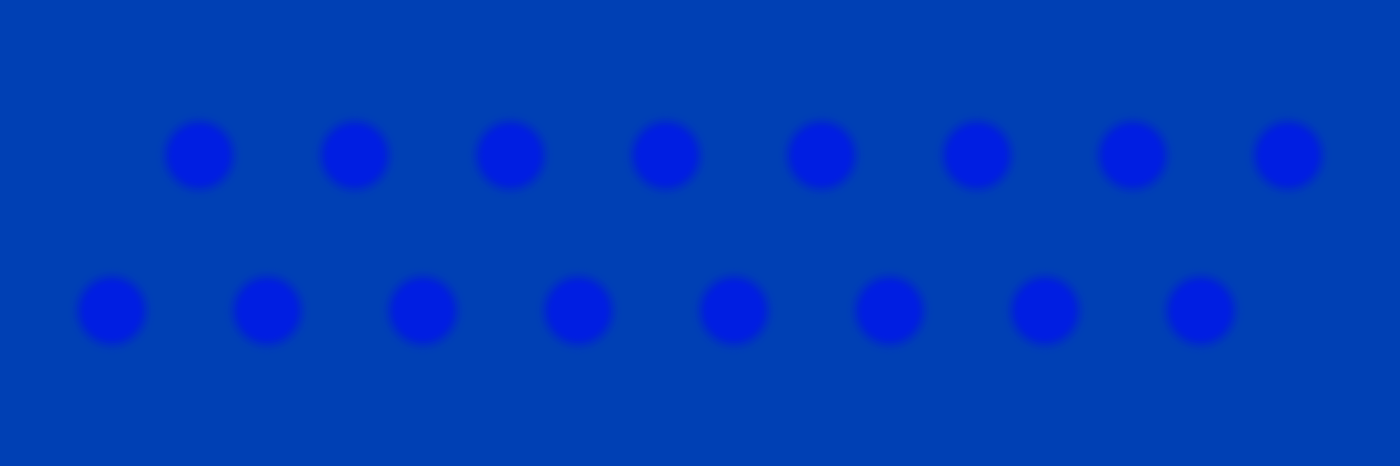

lambda_ref_std_=4.76e+01
rgb_ref=array([0.  , 0.27, 0.65]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=47.57, lambda_dev=-0.00, lambda_std=2.00


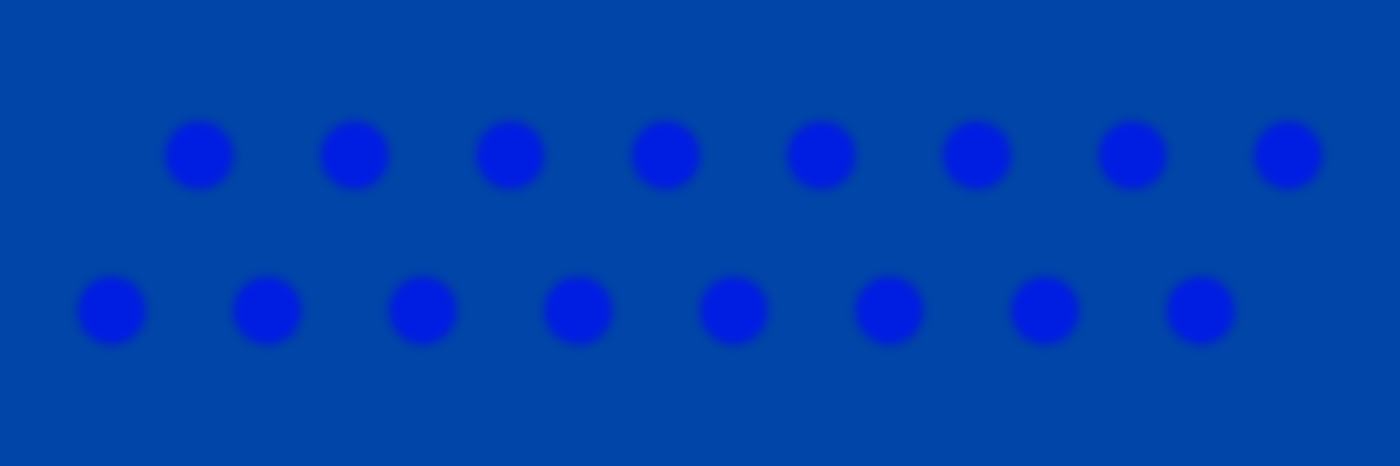

lambda_ref_std_=5.66e+01
rgb_ref=array([0.  , 0.28, 0.61]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=56.57, lambda_dev=-0.00, lambda_std=2.00


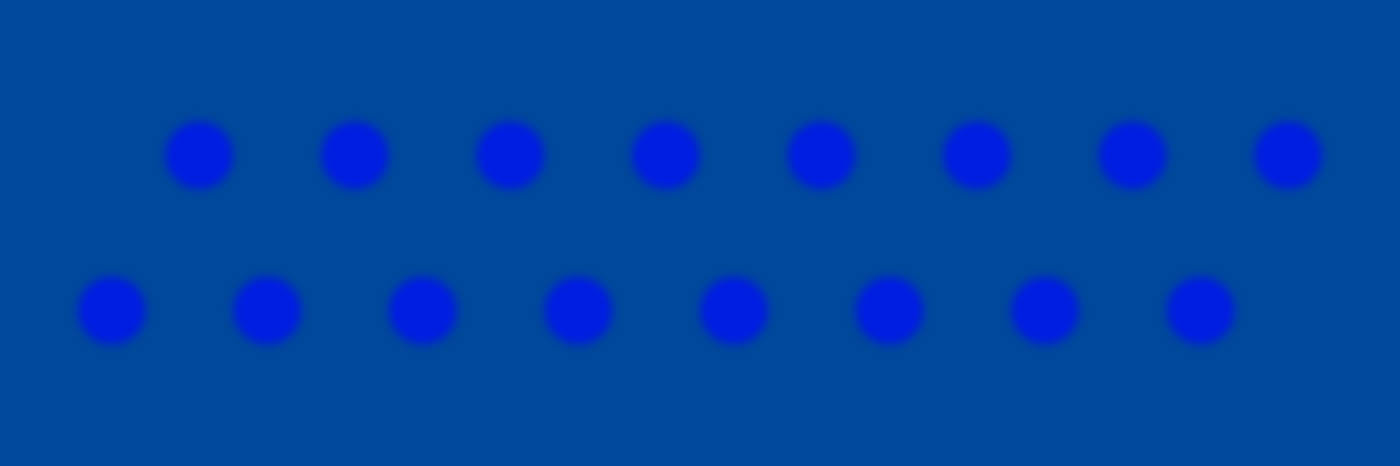

lambda_ref_std_=6.73e+01
rgb_ref=array([0.  , 0.29, 0.57]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=67.27, lambda_dev=-0.00, lambda_std=2.00


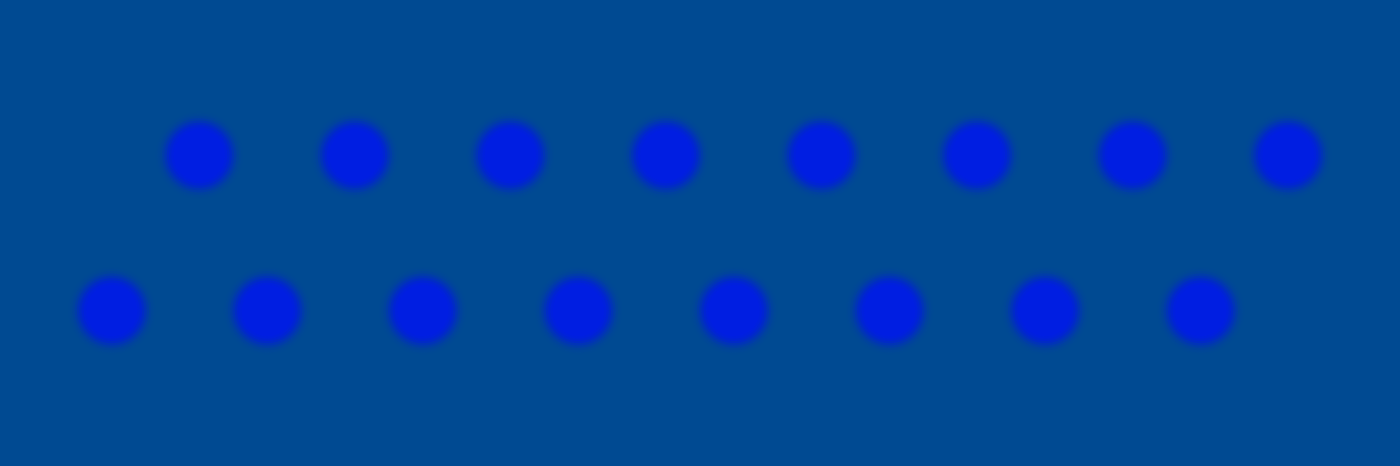

lambda_ref_std_=8.00e+01
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


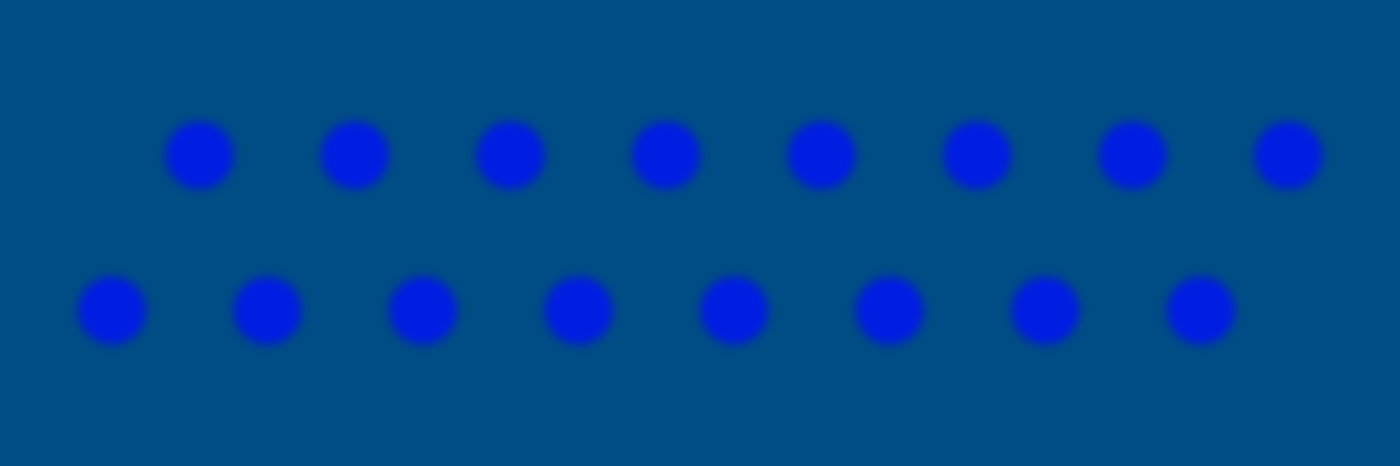

lambda_ref_std_=9.51e+01
rgb_ref=array([0.  , 0.3 , 0.46]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=95.14, lambda_dev=-0.00, lambda_std=2.00


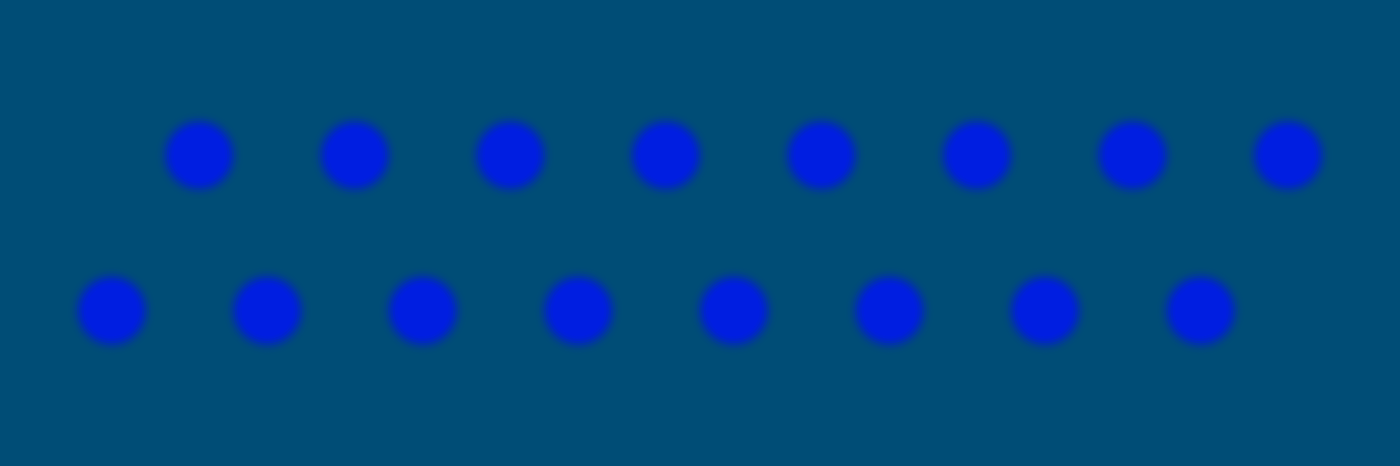

lambda_ref_std_=1.13e+02
rgb_ref=array([0.  , 0.3 , 0.41]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=113.14, lambda_dev=-0.00, lambda_std=2.00


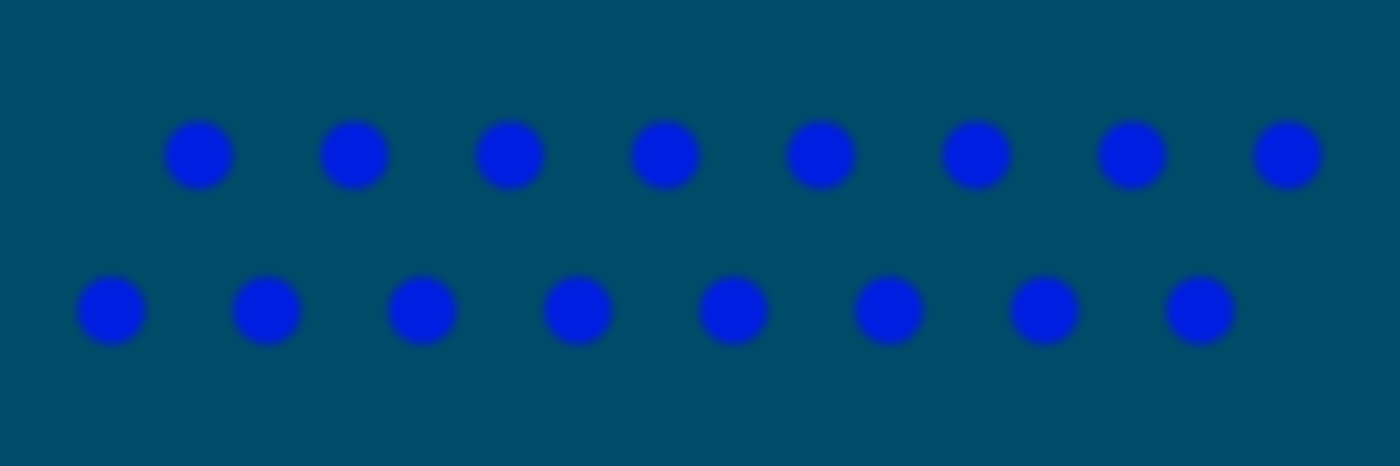

lambda_ref_std_=1.35e+02
rgb_ref=array([0.  , 0.29, 0.36]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=134.54, lambda_dev=-0.00, lambda_std=2.00


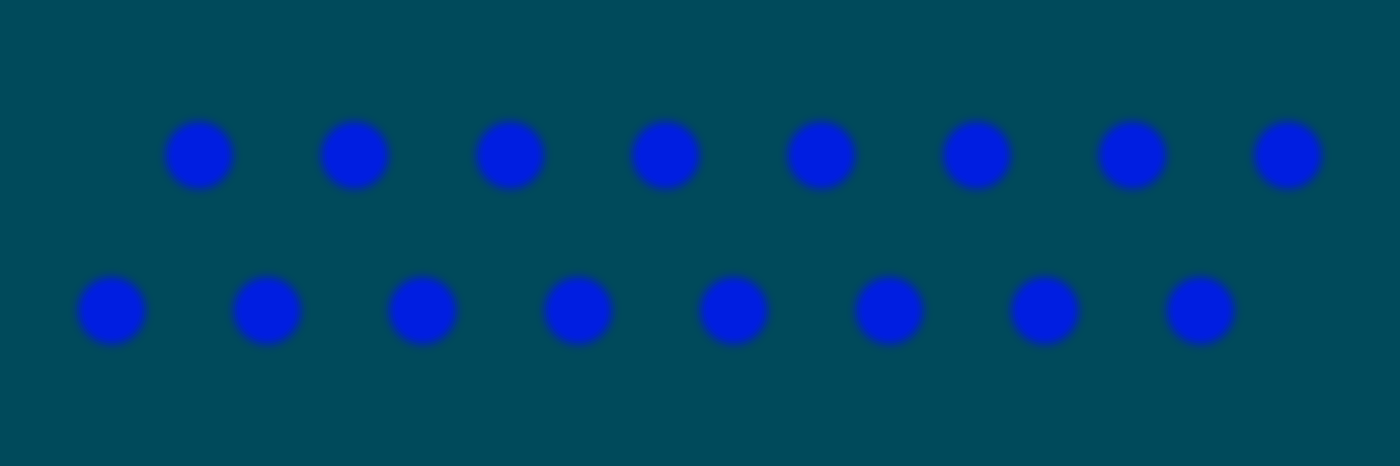

lambda_ref_std_=1.60e+02
rgb_ref=array([0.14, 0.28, 0.32]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=160.00, lambda_dev=-0.00, lambda_std=2.00


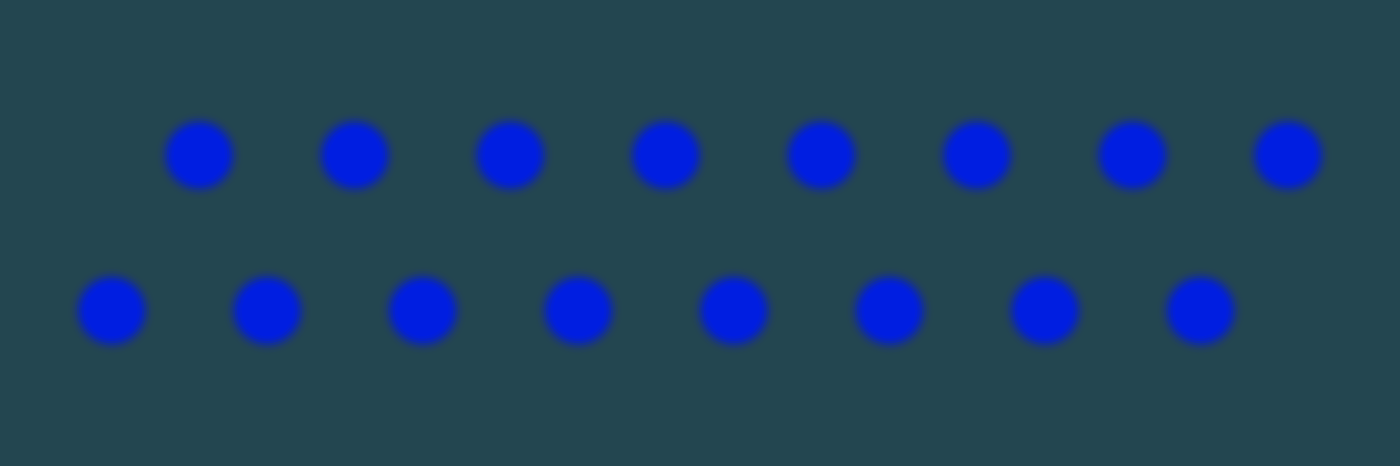

In [37]:
opts_ = opts.copy()
# for lambda_ref_std_ in np.linspace(120., 80, N_scan, endpoint=False): 
factor = 1.05
factor = 2
for lambda_ref_std_ in np.geomspace(opts['lambda_ref_std']/factor, opts['lambda_ref_std']*factor, N_scan): 
    opts_.update(lambda_ref_std=lambda_ref_std_)
    print(f'{lambda_ref_std_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

### Scan Analysis: Mean Chromatic Deviation ($\lambda_{dev}$)

**Variable:** We adjust the average shift in wavelength between the dots and the background.
**Implementation:** $\lambda_{dev}$ is varied to change how far the dot color "moves" away from the reference background hue on the spectrum.
**Perceptual Effect:** This directly controls the chromatic contrast. A small deviation makes the dots blend into the background, while a large deviation creates high salience everywhere. The ambiguity effect is strongest when $\lambda_{dev}$ is just enough to be resolved by cones at fixation but falls within the pooling threshold of peripheral rods.

**Verification:** Look for the value where dots are clearly visible when looked at directly, but seem to "vanish" or merge into the background in the periphery.

lambda_dev_=-5.00
rgb_ref=array([0.  , 0.27, 0.49]), rgb=array([0. , 0. , 0.9]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-5.00, lambda_std=2.00


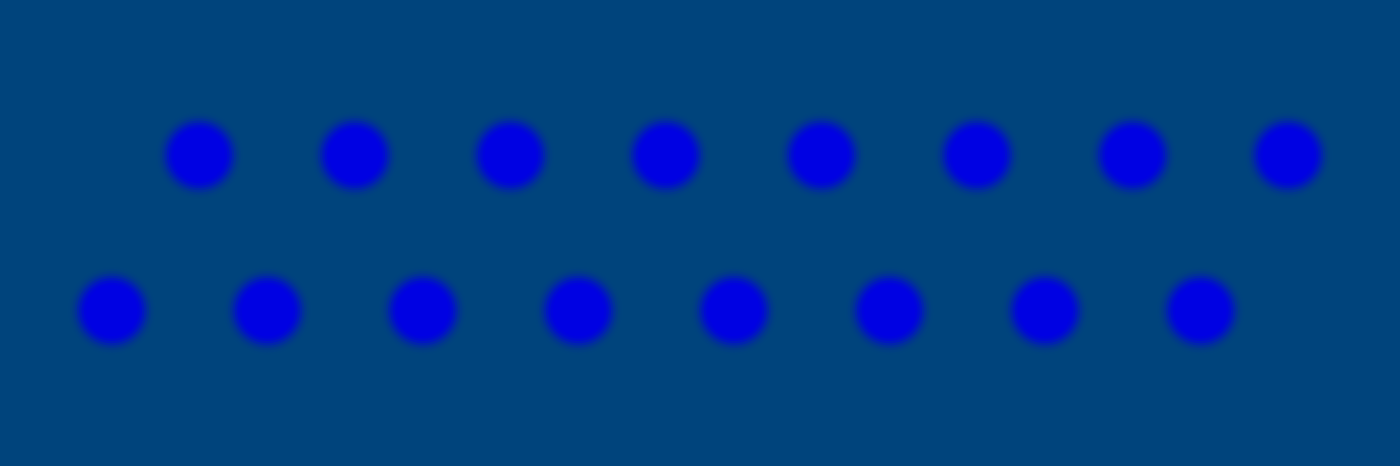

lambda_dev_=-3.75
rgb_ref=array([0.  , 0.27, 0.49]), rgb=array([0.  , 0.  , 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-3.75, lambda_std=2.00


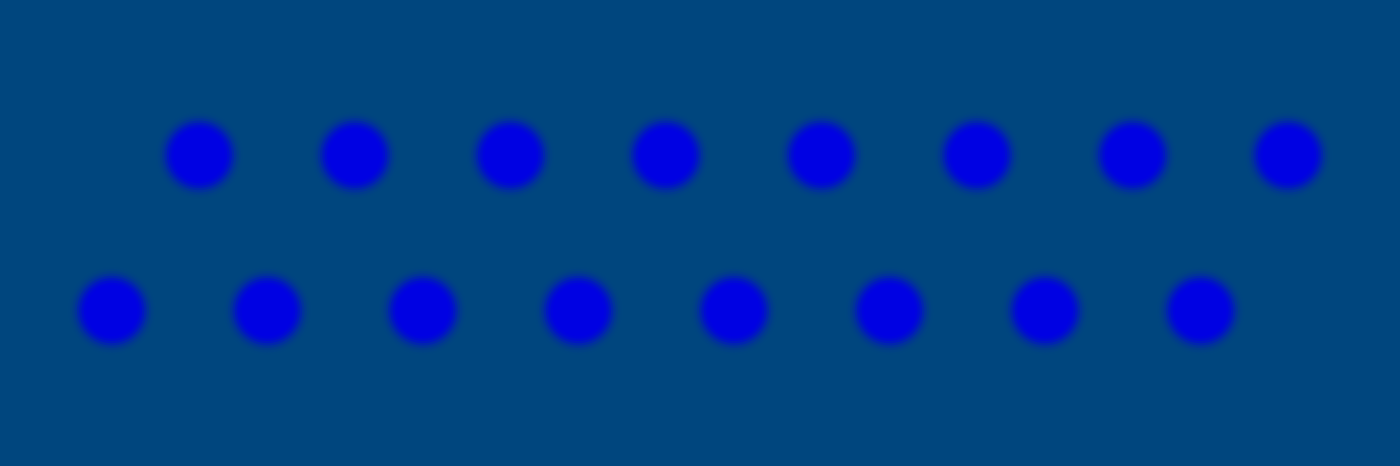

lambda_dev_=-2.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.  , 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-2.50, lambda_std=2.00


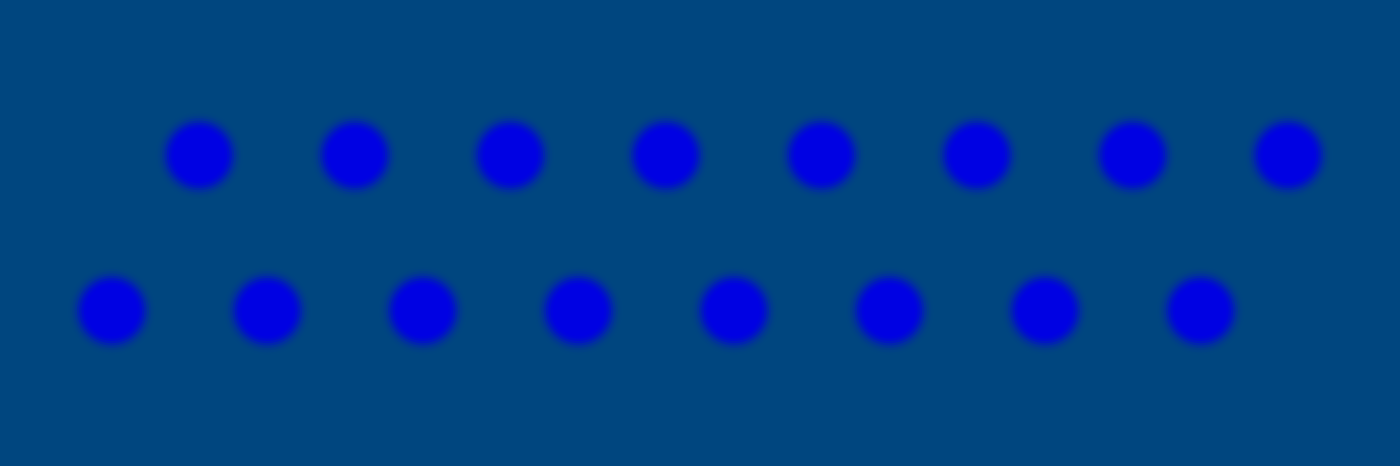

lambda_dev_=-1.25
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.05, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.25, lambda_std=2.00


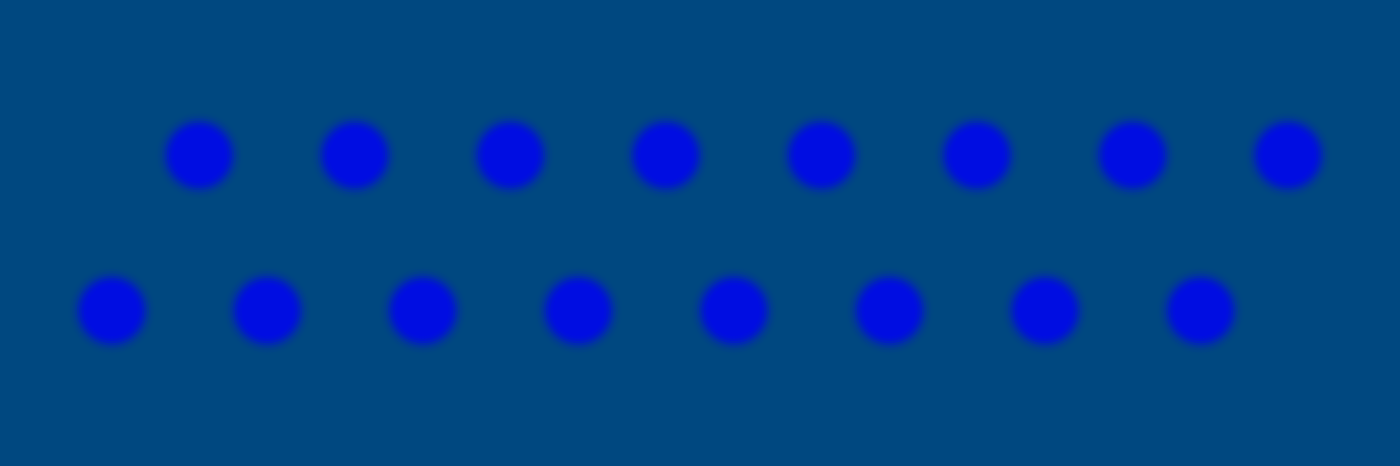

lambda_dev_=0.00
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=0.00, lambda_std=2.00


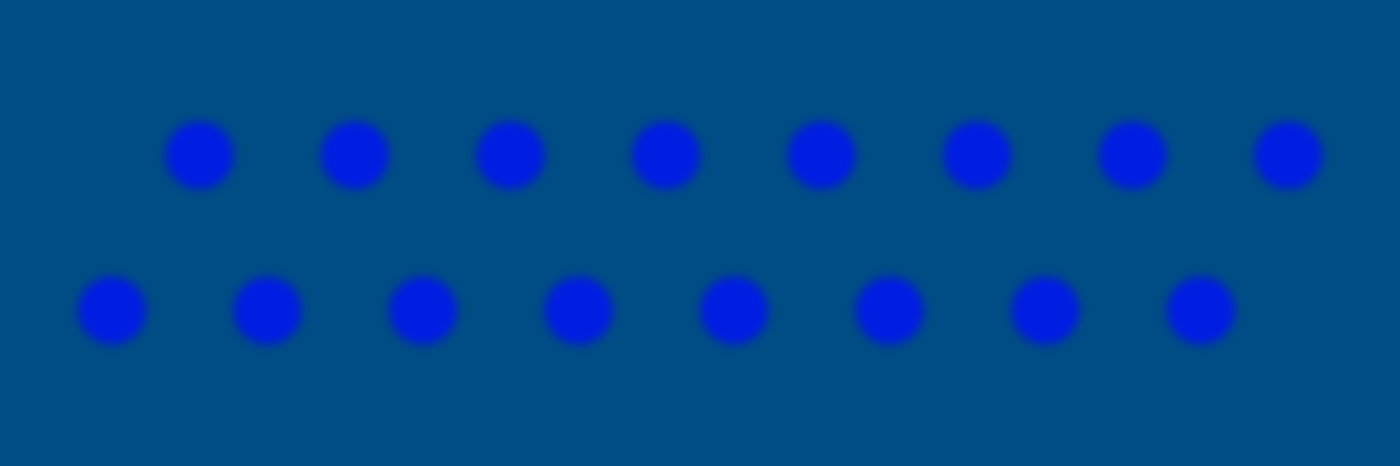

lambda_dev_=1.25
rgb_ref=array([0.  , 0.31, 0.54]), rgb=array([0.  , 0.16, 0.88]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=1.25, lambda_std=2.00


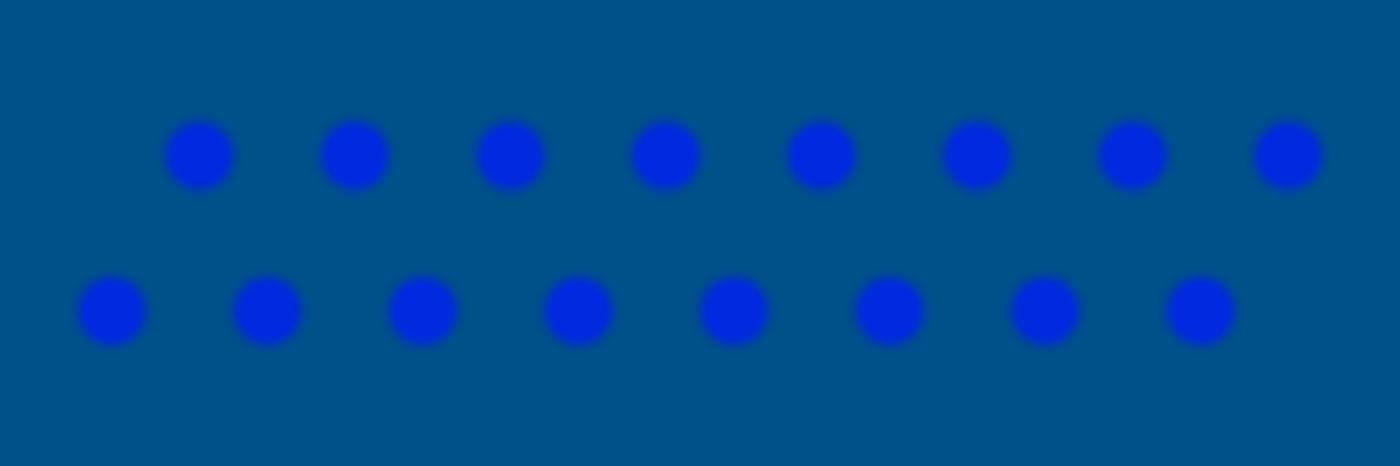

lambda_dev_=2.50
rgb_ref=array([0.  , 0.32, 0.55]), rgb=array([0.  , 0.18, 0.88]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=2.50, lambda_std=2.00


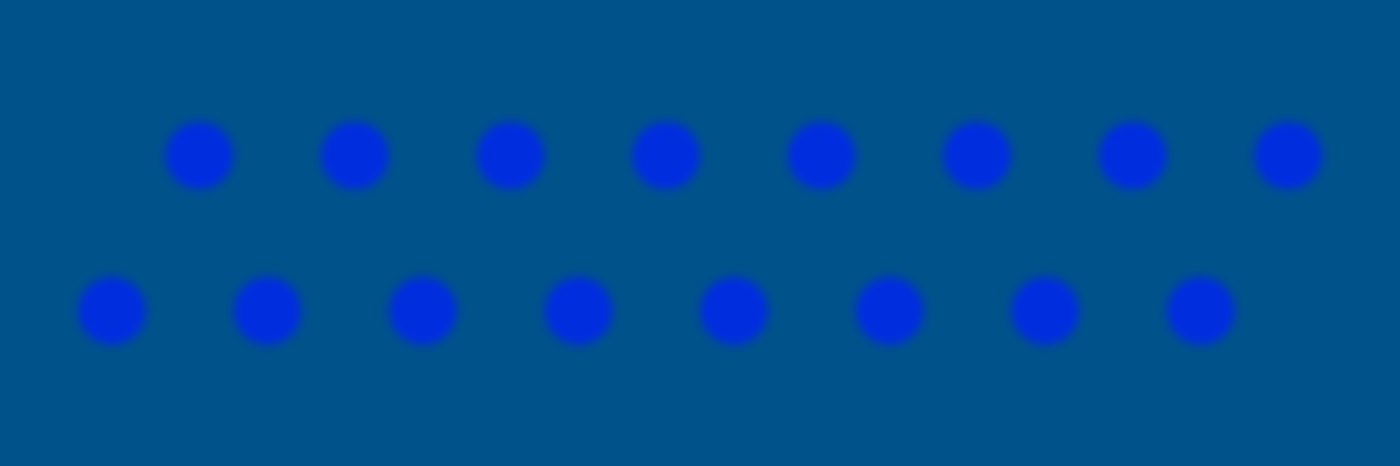

lambda_dev_=3.75
rgb_ref=array([0.  , 0.34, 0.56]), rgb=array([0.  , 0.22, 0.88]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=3.75, lambda_std=2.00


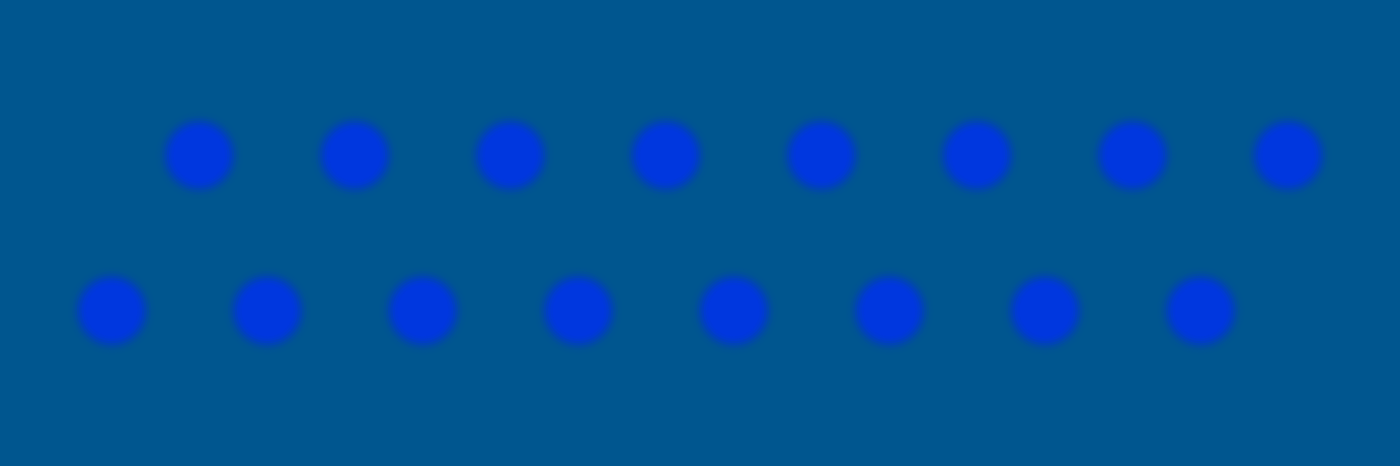

lambda_dev_=5.00
rgb_ref=array([0.  , 0.37, 0.6 ]), rgb=array([0.  , 0.28, 0.87]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=5.00, lambda_std=2.00


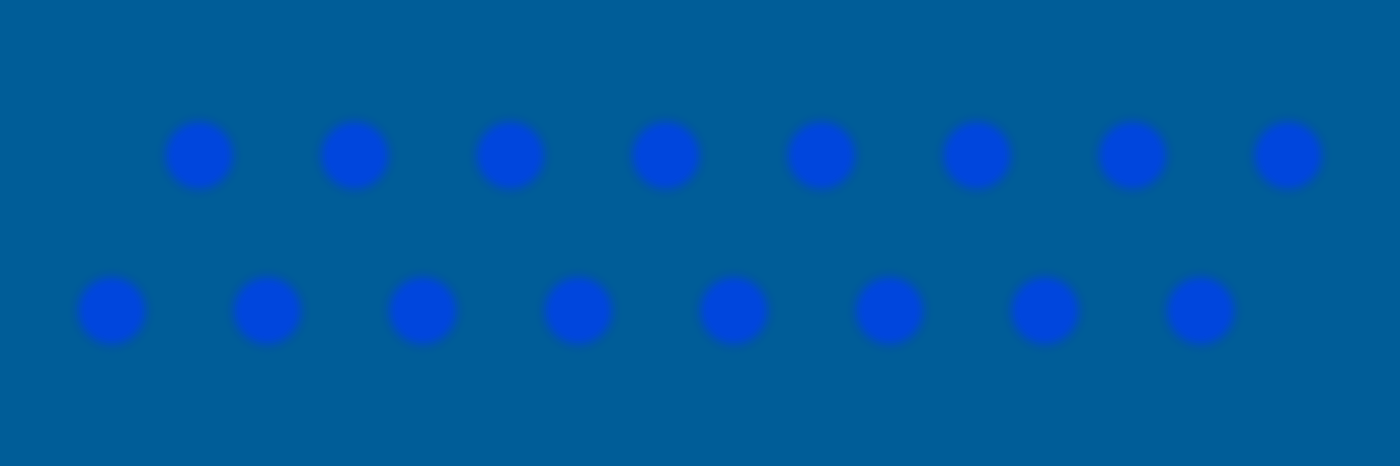

In [38]:
opts_ = opts.copy()
for lambda_dev_ in np.linspace(-5, 5., N_scan): 
    opts_.update(lambda_dev=lambda_dev_)
    print(f'{lambda_dev_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

lambda_dev_=-1.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.03, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.50, lambda_std=2.00


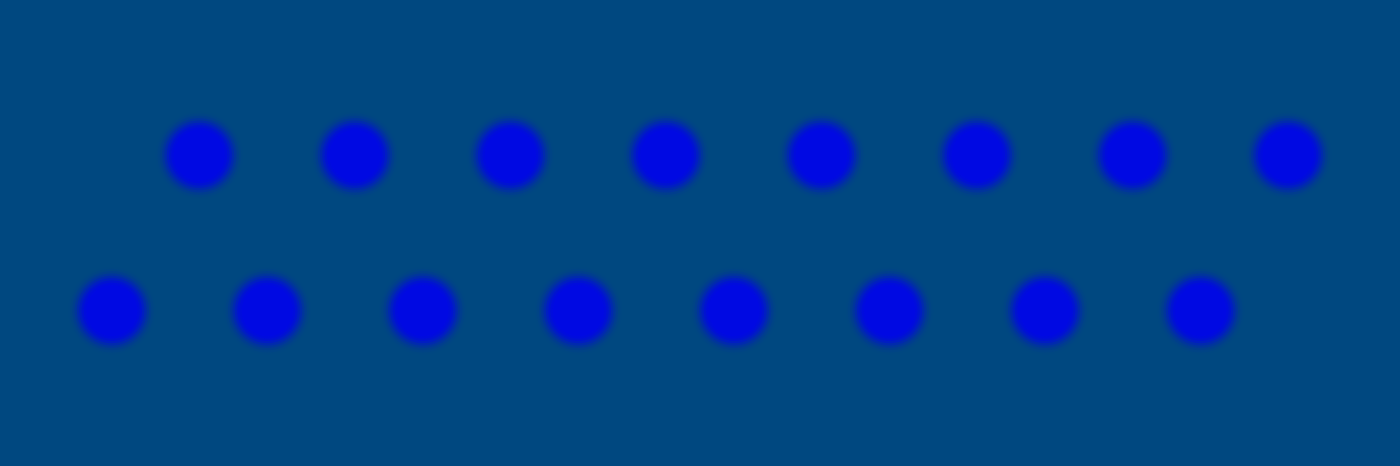

lambda_dev_=-1.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.03, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.50, lambda_std=2.00


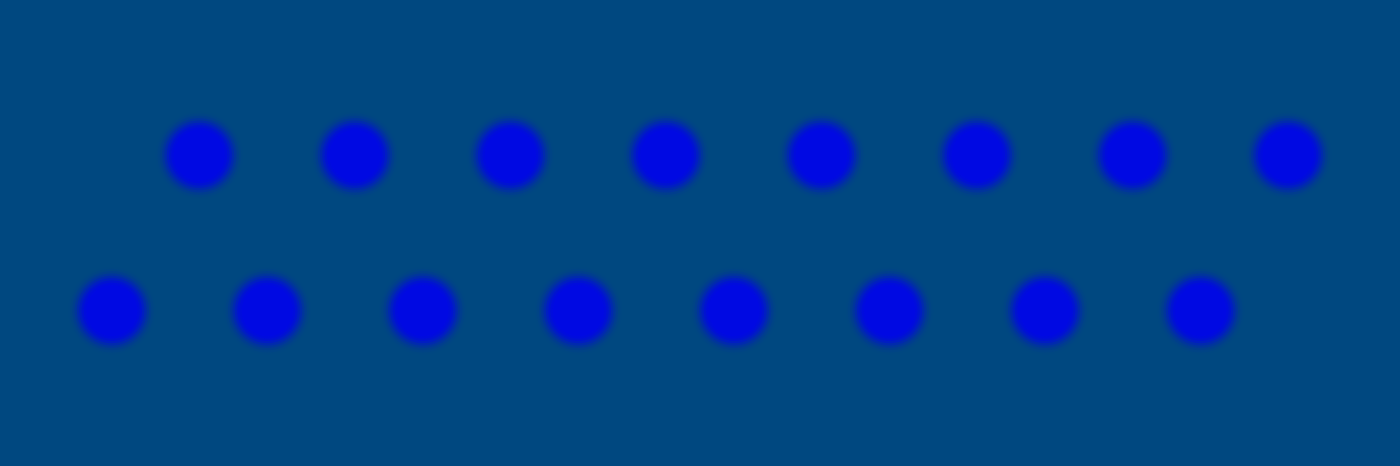

lambda_dev_=-1.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.03, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.50, lambda_std=2.00


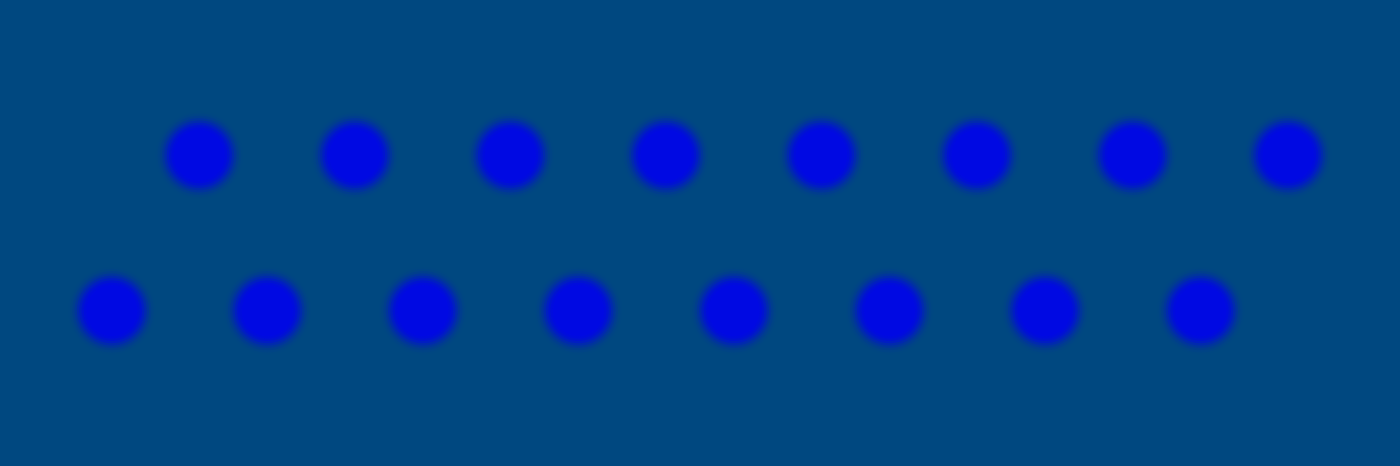

lambda_dev_=-1.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.03, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.50, lambda_std=2.00


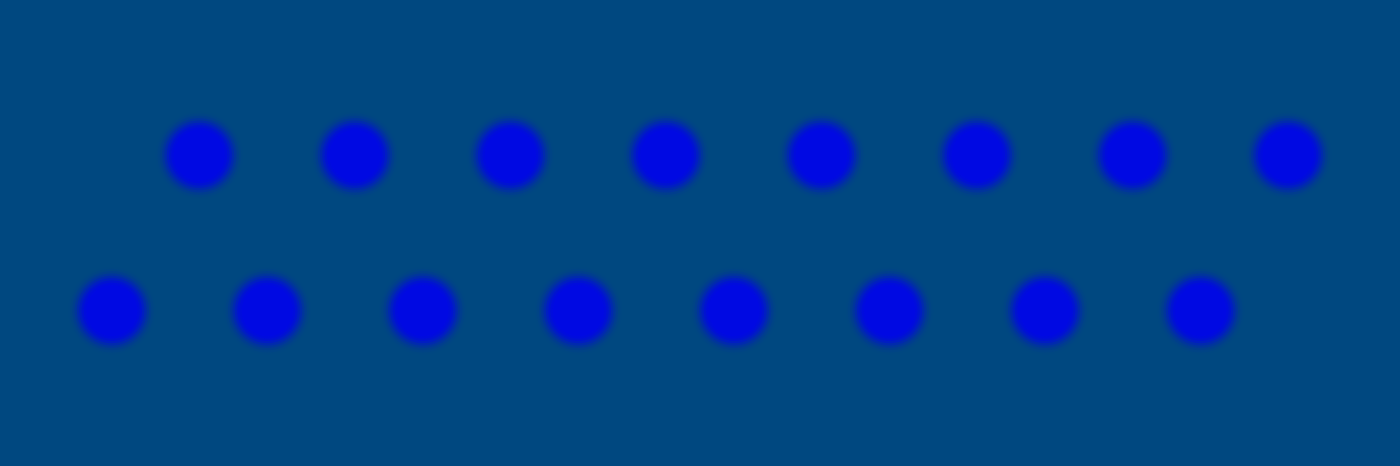

lambda_dev_=-1.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.03, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.50, lambda_std=2.00


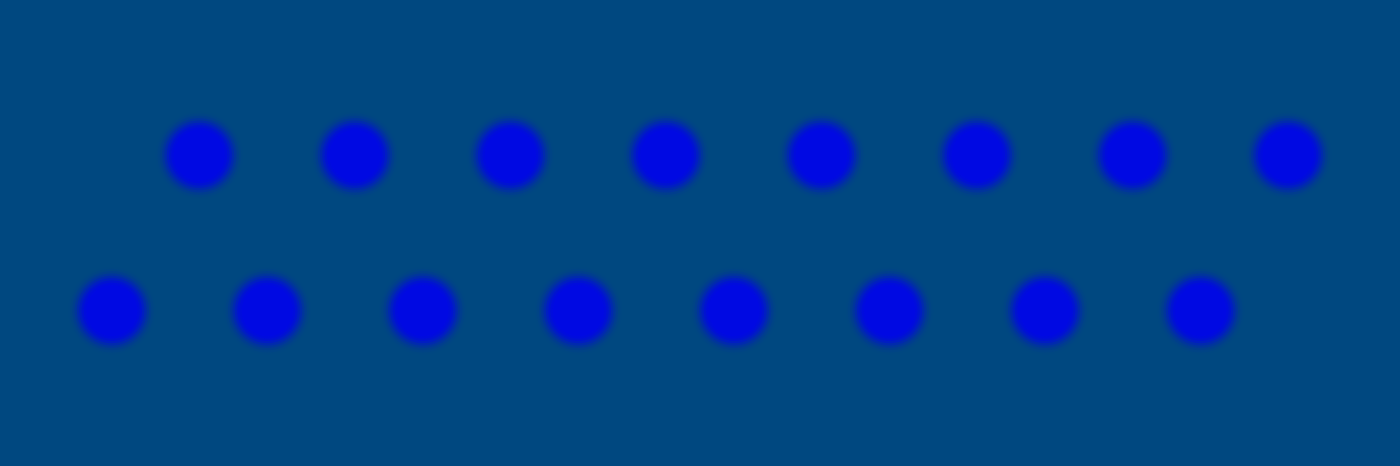

lambda_dev_=-1.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.03, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.50, lambda_std=2.00


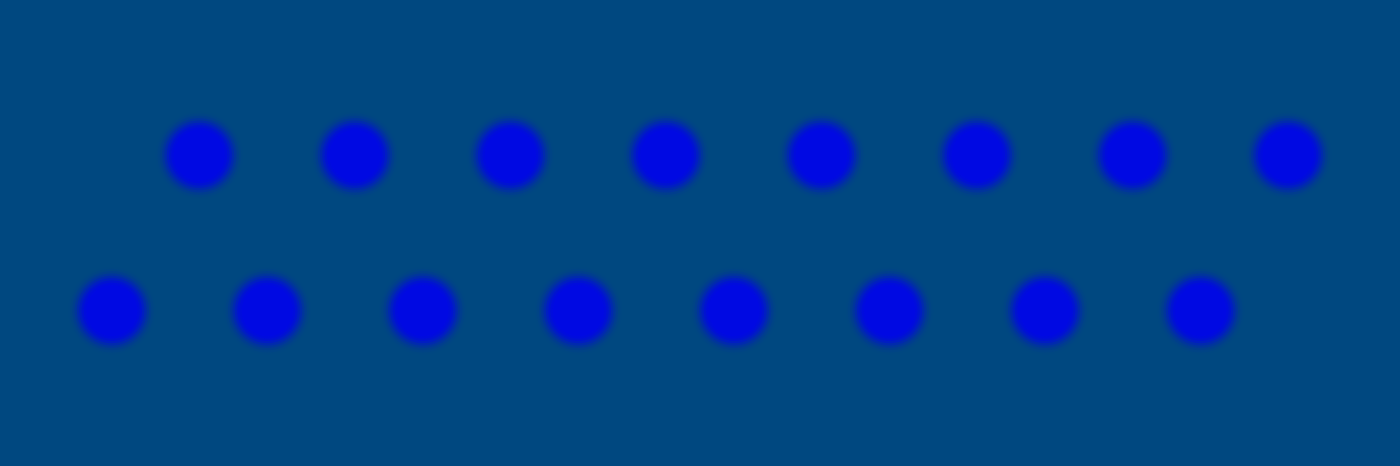

lambda_dev_=-1.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.03, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.50, lambda_std=2.00


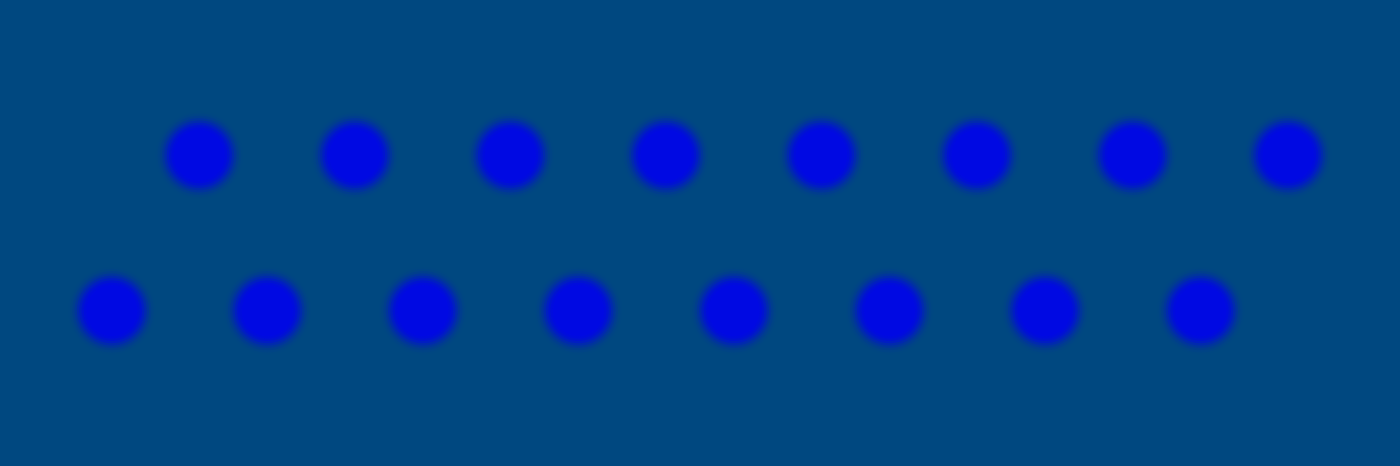

lambda_dev_=-1.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.03, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.50, lambda_std=2.00


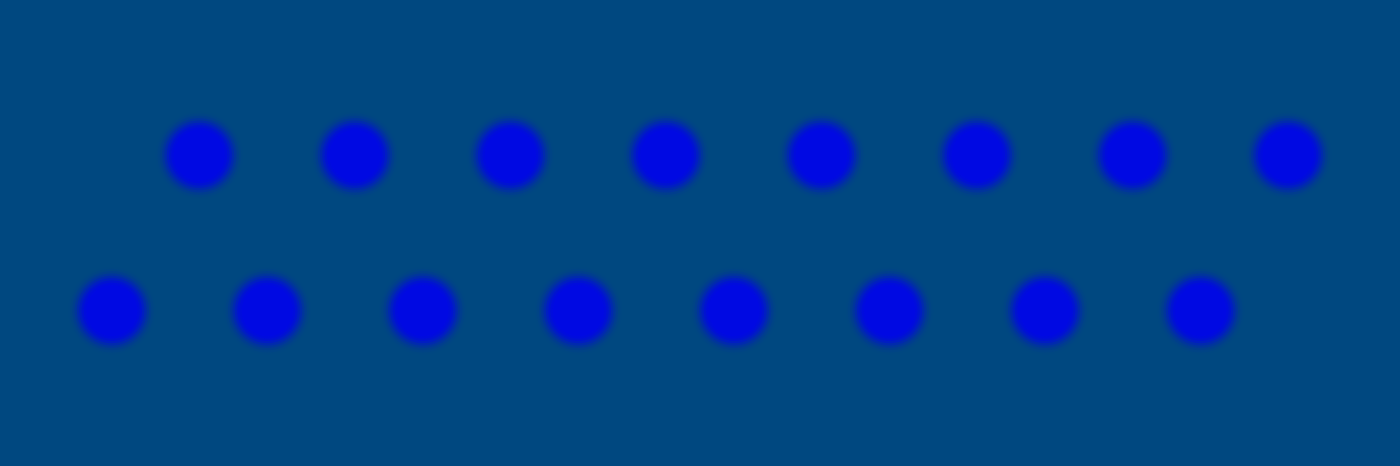

lambda_dev_=-1.50
rgb_ref=array([0.  , 0.28, 0.5 ]), rgb=array([0.  , 0.03, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-1.50, lambda_std=2.00


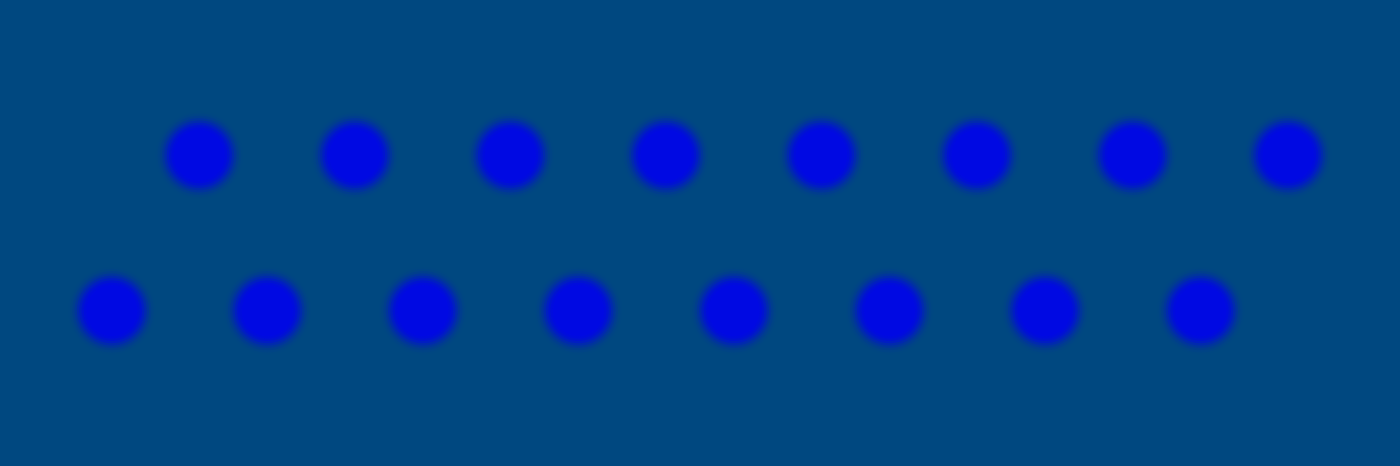

In [39]:
opts_ = opts.copy()
for lambda_dev_ in np.linspace(-1.5, -1.5, N_scan): 
    opts_.update(lambda_dev=lambda_dev_)
    print(f'{lambda_dev_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

### Scan Analysis: Dot Wavelength Spread ($\lambda_{std}$)

**Variable:** We vary the standard deviation of wavelengths for the dots themselves.
**Implementation:** $\lambda_{std}$ is adjusted to control the chromatic heterogeneity across the dot array.
**Perceptual Effect:** Low spread creates a uniform set of dots, while high spread introduces local color variations. High variability can raise global salience (making the pattern more "obvious" everywhere), whereas moderate spread can mimic natural textures and better preserve the central parsing advantage over peripheral fusion.

**Verification:** Note if increasing $\lambda_{std}$ makes the periphery feel "busier" or if it helps the dots blend more effectively into a coarse texture.

lambda_std_=1.00e+00
rgb_ref=array([0.  , 0.31, 0.54]), rgb=array([0.  , 0.16, 0.88]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=1.00


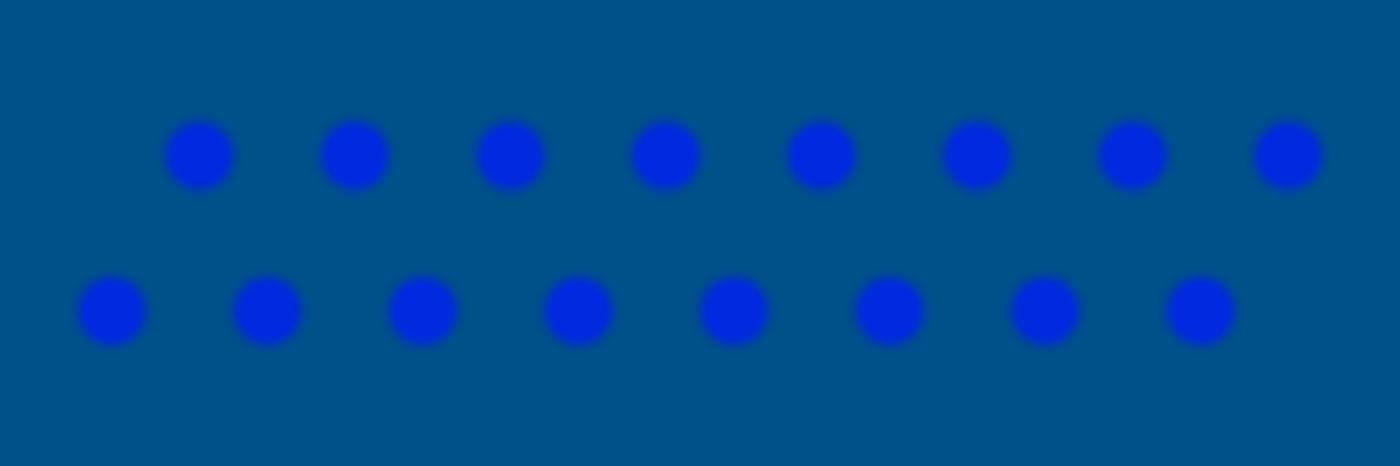

lambda_std_=1.19e+00
rgb_ref=array([0.  , 0.31, 0.53]), rgb=array([0.  , 0.15, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=1.19


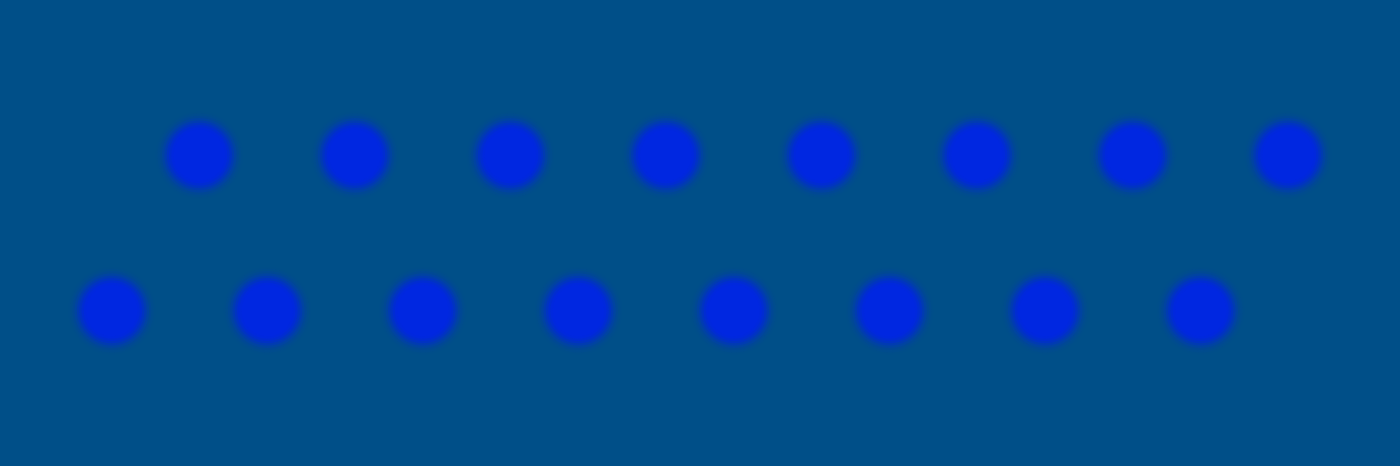

lambda_std_=1.41e+00
rgb_ref=array([0.  , 0.31, 0.53]), rgb=array([0.  , 0.14, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=1.41


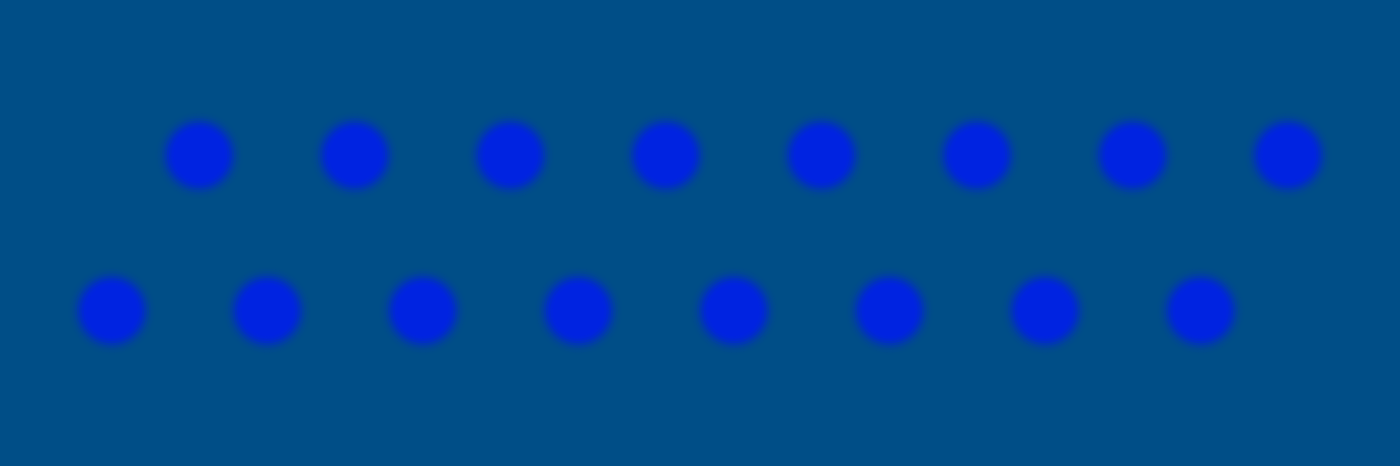

lambda_std_=1.68e+00
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.13, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=1.68


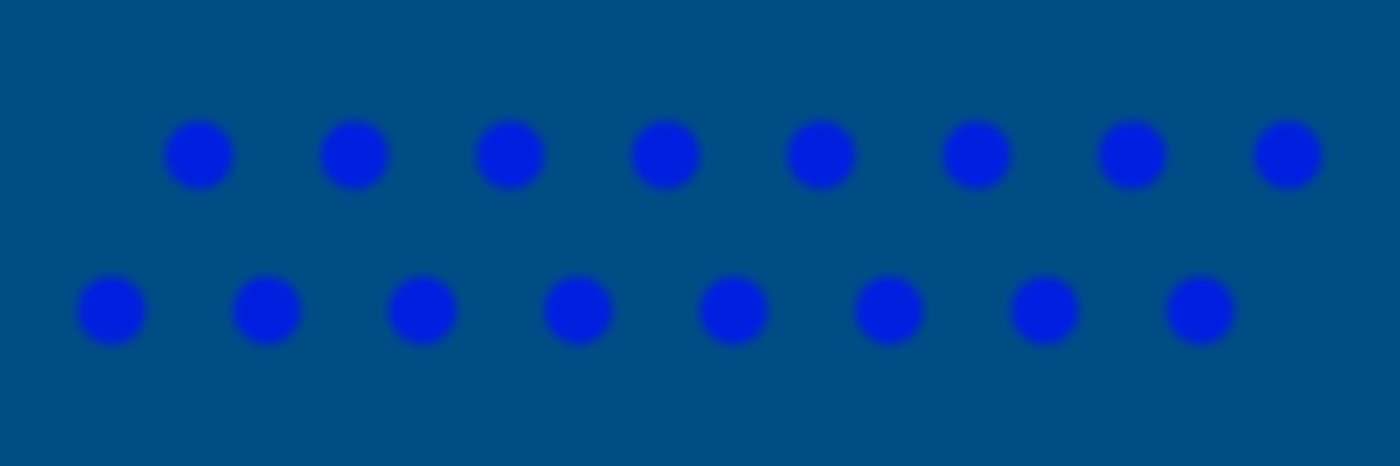

lambda_std_=2.00e+00
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


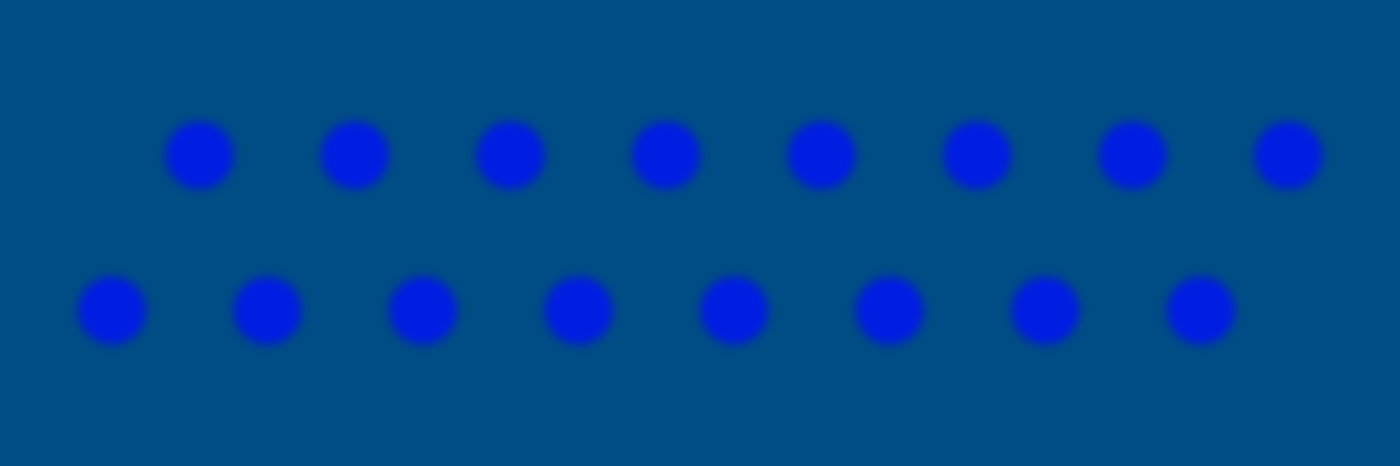

lambda_std_=2.38e+00
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.11, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.38


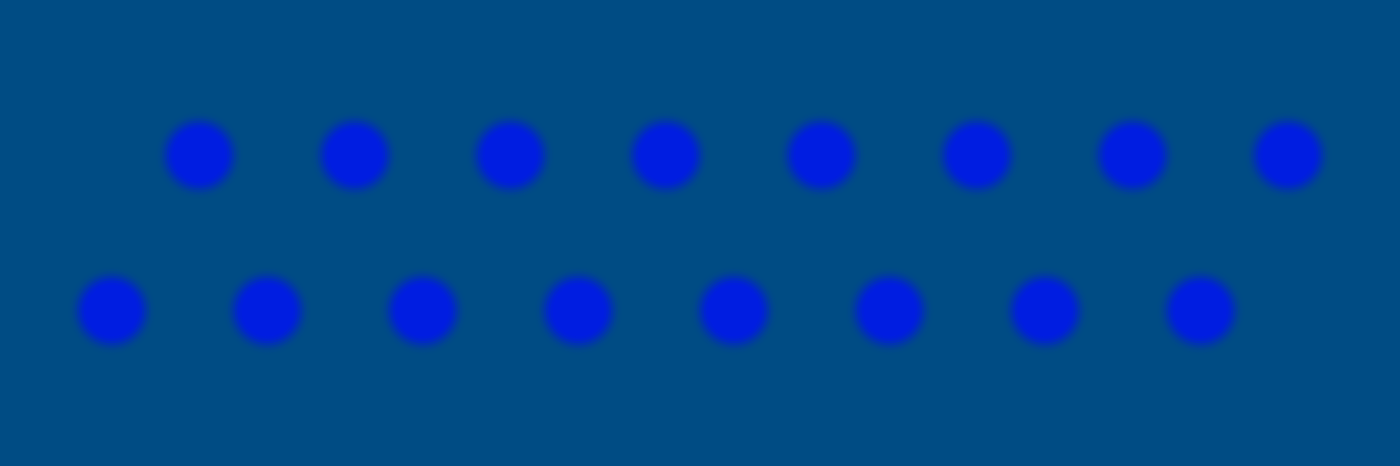

lambda_std_=2.83e+00
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.11, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.83


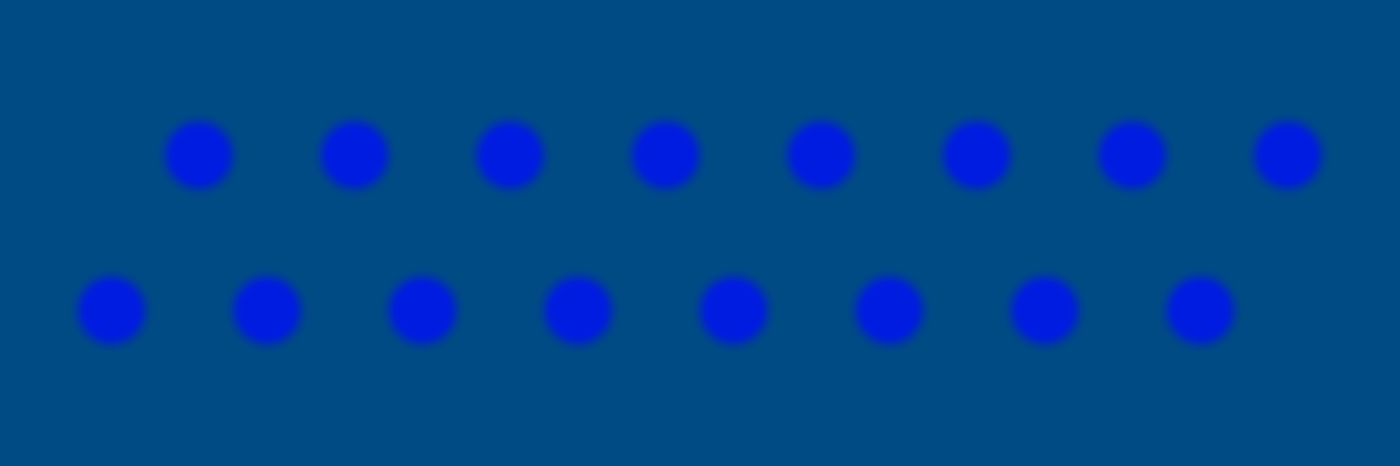

lambda_std_=3.36e+00
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.11, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=3.36


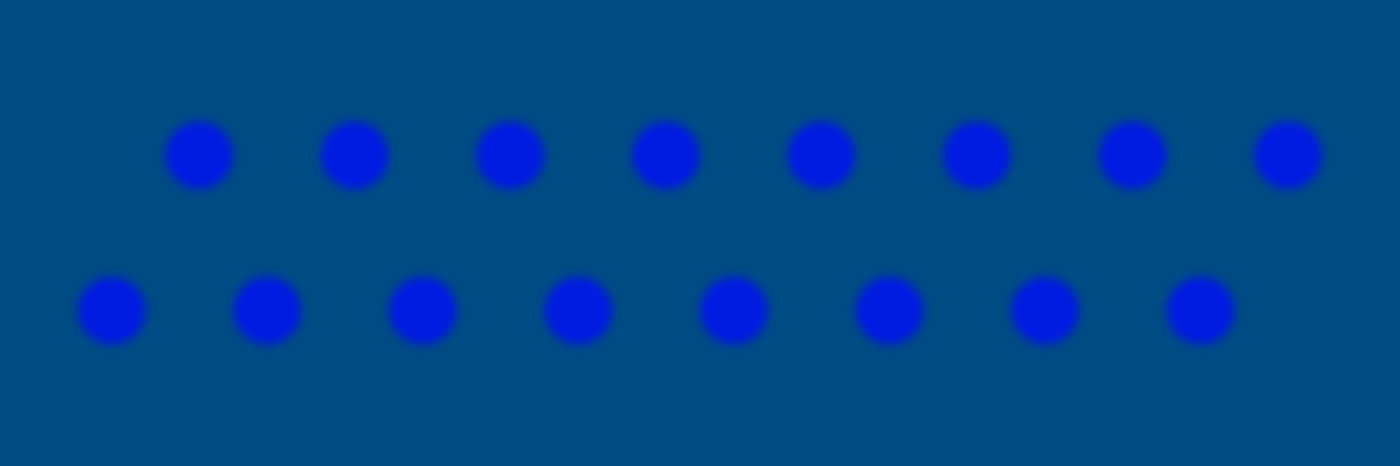

lambda_std_=4.00e+00
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.11, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=4.00


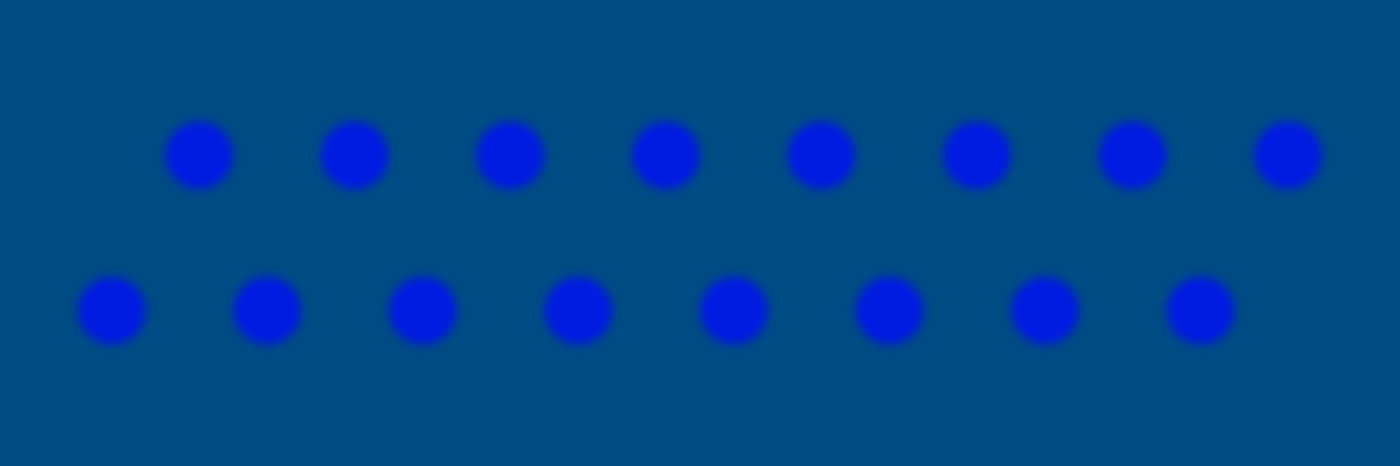

In [40]:
opts_ = opts.copy()
for lambda_std_ in np.geomspace(opts['lambda_std']/factor, opts['lambda_std']*factor, N_scan): 
    opts_.update(lambda_std=lambda_std_)
    print(f'{lambda_std_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

### Scan Analysis: Lattice Density ($N_W$)

**Variable:** We vary the spatial frequency of the dot pattern.
**Implementation:** The number of columns $N_W$ is changed across a logarithmic scale, effectively altering the spacing between dots relative to the image size.
**Perceptual Effect:** 
- **Sparse Spacing:** Dots are far apart and typically resolve as distinct elements everywhere in the field.
- **Dense Spacing:** The pattern may fuse into a single mass even at fixation.
The most informative regime is near the boundary where central segmentation remains available but peripheral parsing degrades due to larger receptive-field pooling.

**Verification:** Identify the density where you can still see individual dots in the center, but the periphery looks like a continuous shaded region rather than a collection of points.

N_=np.int64(4)
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


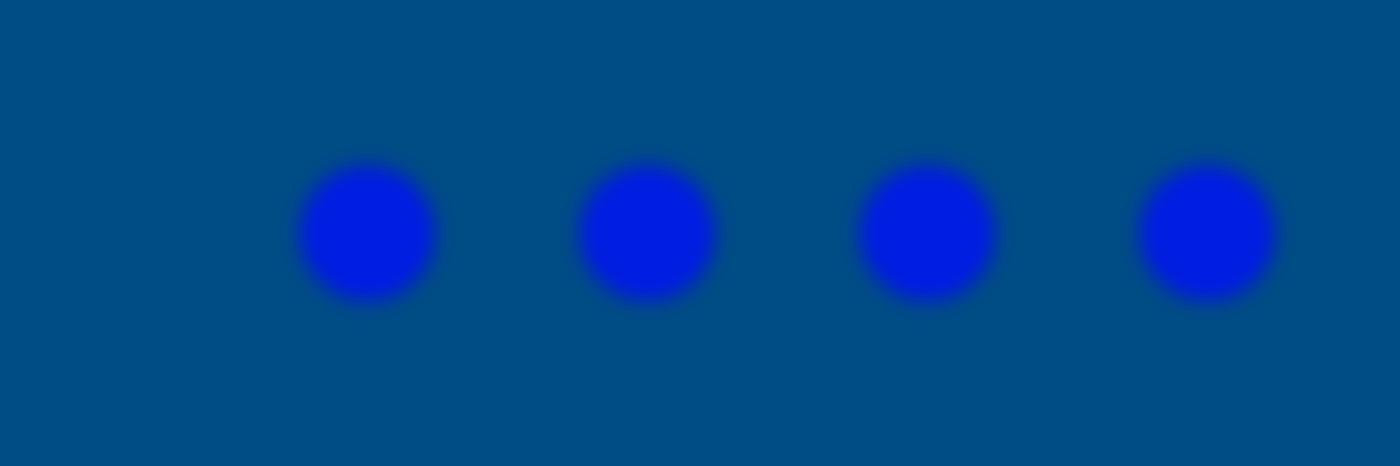

N_=np.int64(5)
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


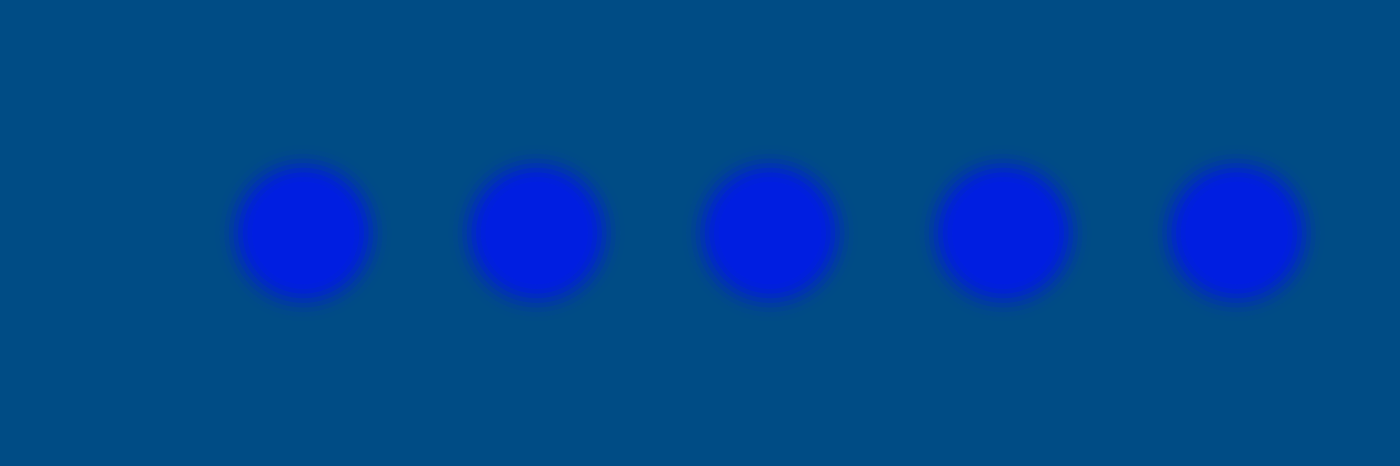

N_=np.int64(6)
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


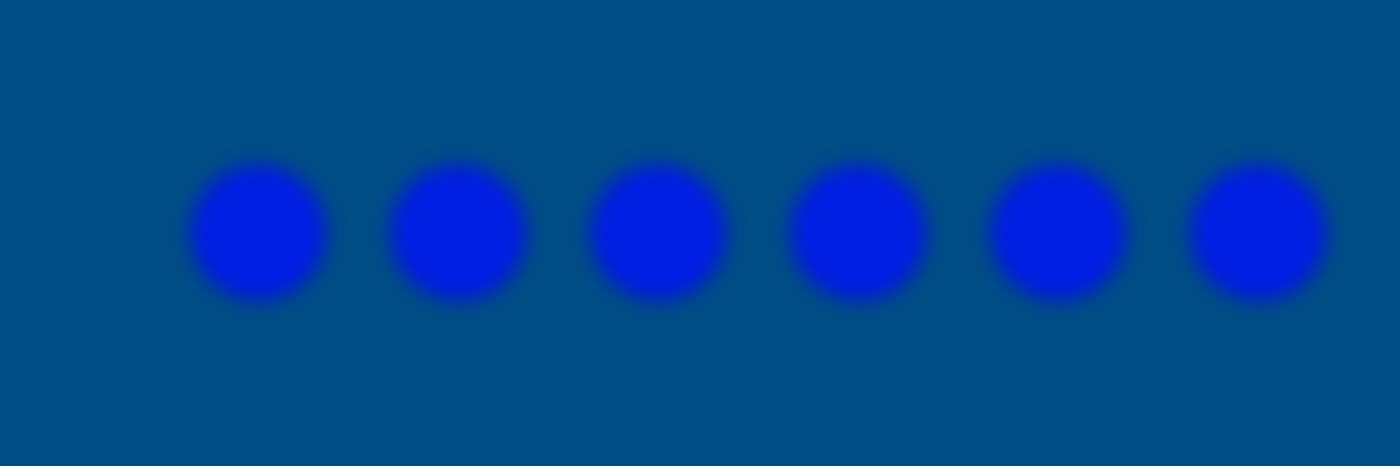

N_=np.int64(8)
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


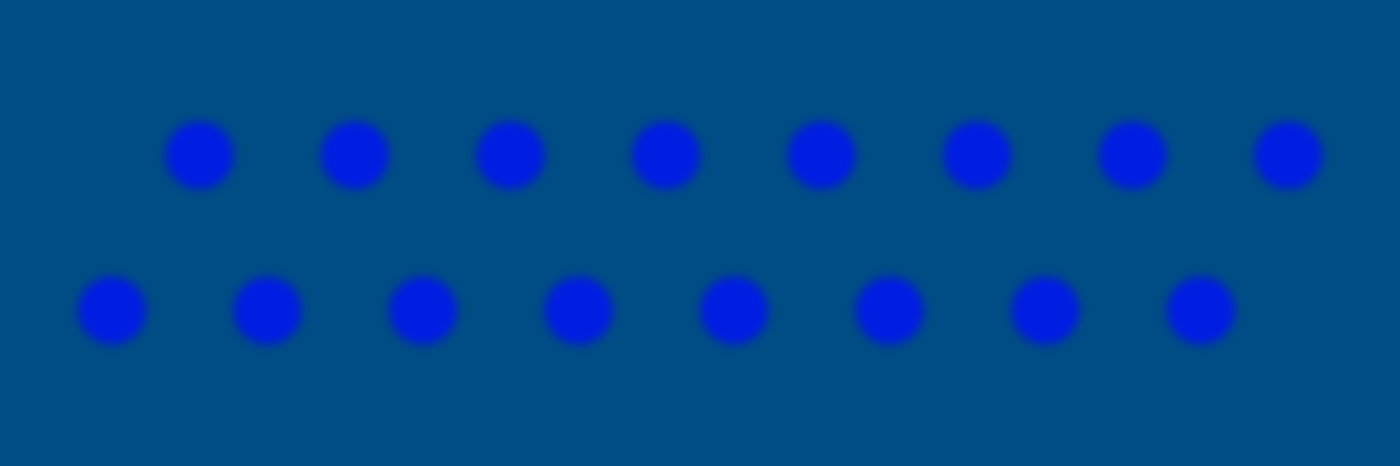

N_=np.int64(9)
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


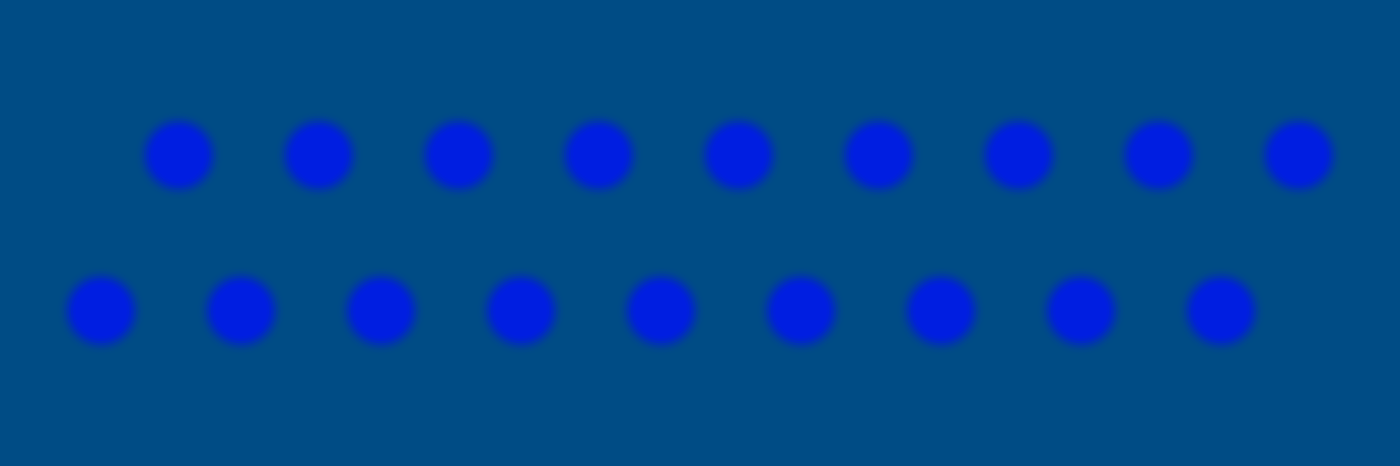

N_=np.int64(11)
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


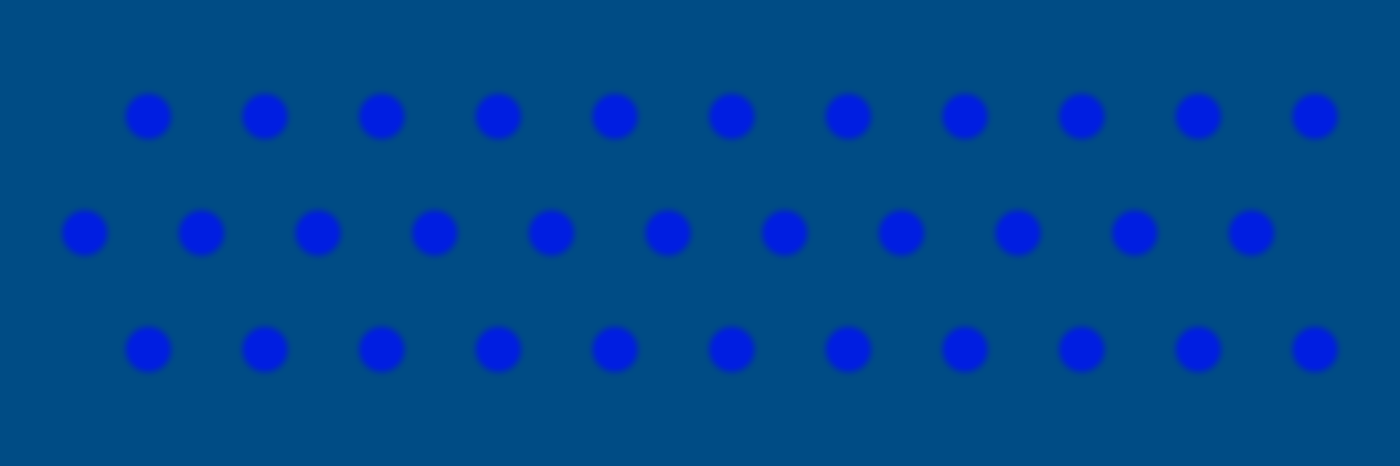

N_=np.int64(13)
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


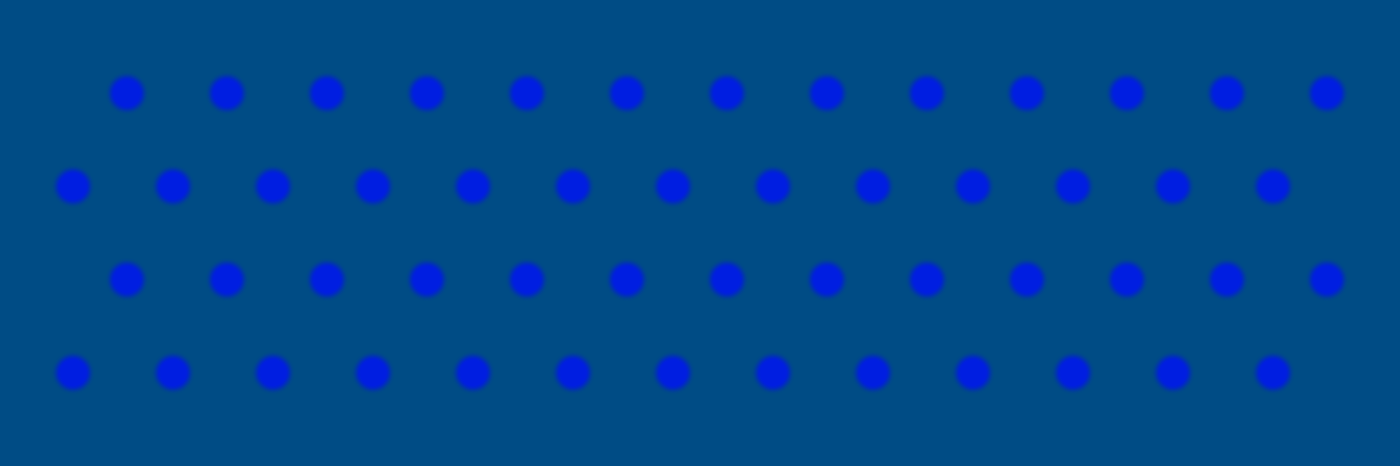

N_=np.int64(16)
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


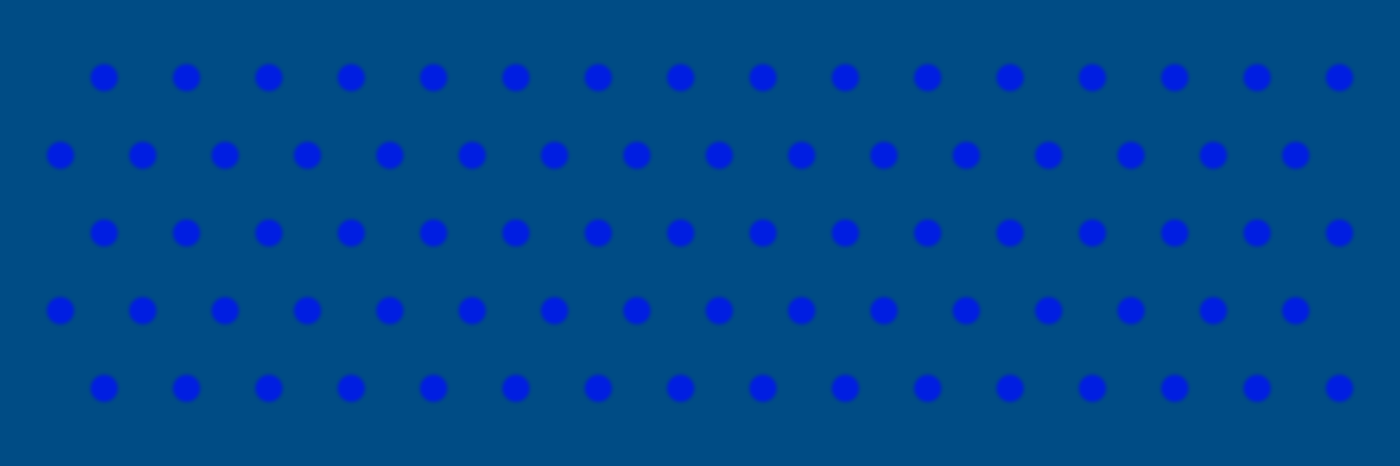

In [41]:
opts_ = opts.copy()
Ns = np.unique([int(k) for k in N_W * np.logspace(-1, 1, N_scan, base=2)]).astype(int)
for N_ in Ns: 
    opts_.update(N_H=int(N_*N_height/N_width), N_W=N_)
    print(f'{N_=}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

### Scan Analysis: Local Shape Primitives

**Variable:** We change the geometric class of the dots (Circles $\rightarrow$ Polygons $\rightarrow$ Diagonals).
**Implementation:** The `shape_mode` and `n_sides` parameters are varied to introduce different contour types and corner energy.
**Perceptual Effect:** 
- **Circular Shapes:** Provide smooth contours, which reduce explicit local anchors and often maximize the "texture" feel in the periphery.
- **Angular/Polygonal Shapes:** Increase corner energy and provide orientation cues. This can improve fixation-locked parsing but may also make the patterns more robust (less ambiguous) in the periphery if the angular features are too strong.

**Verification:** Compare how circles versus hexagons or triangles affect your ability to "lose" the pattern in the periphery. Do sharper corners make it easier or harder for the image to collapse into a texture?

shape_mode=random, n_sides=6
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


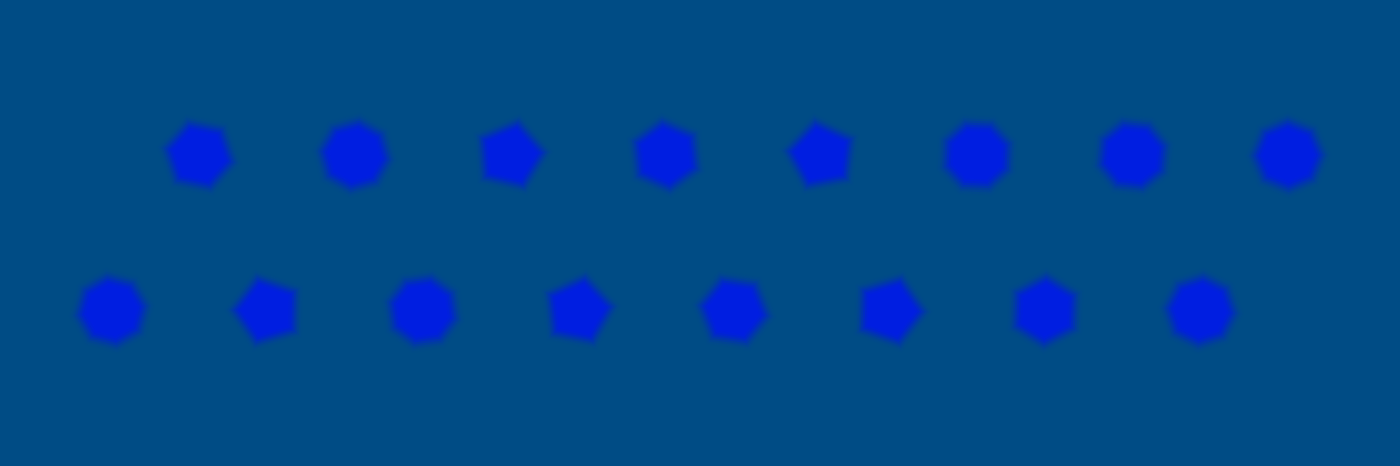

shape_mode=circle, n_sides=6
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


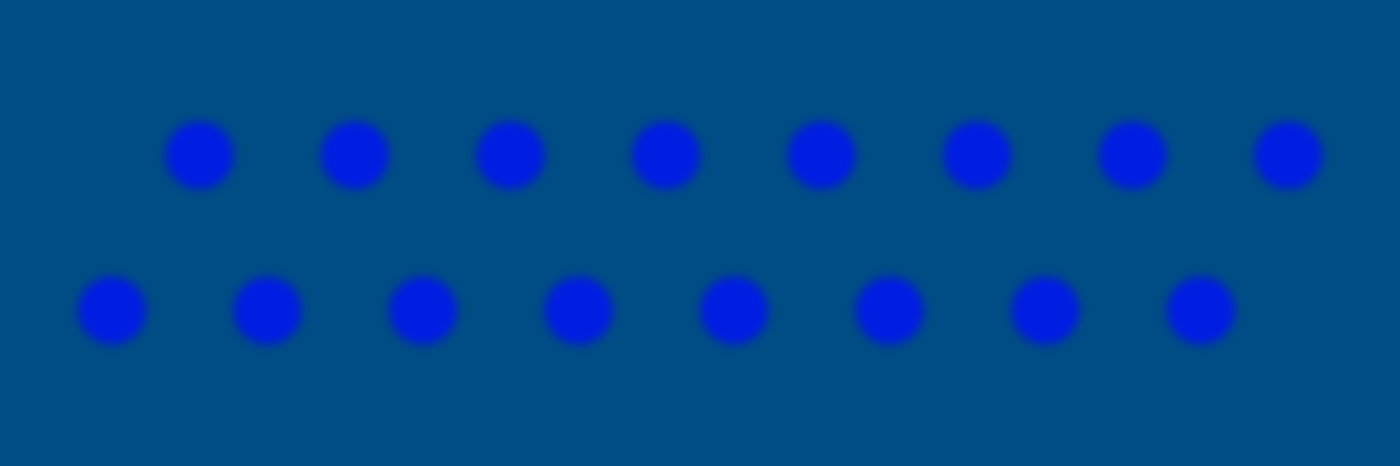

shape_mode=diagonal, n_sides=4
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


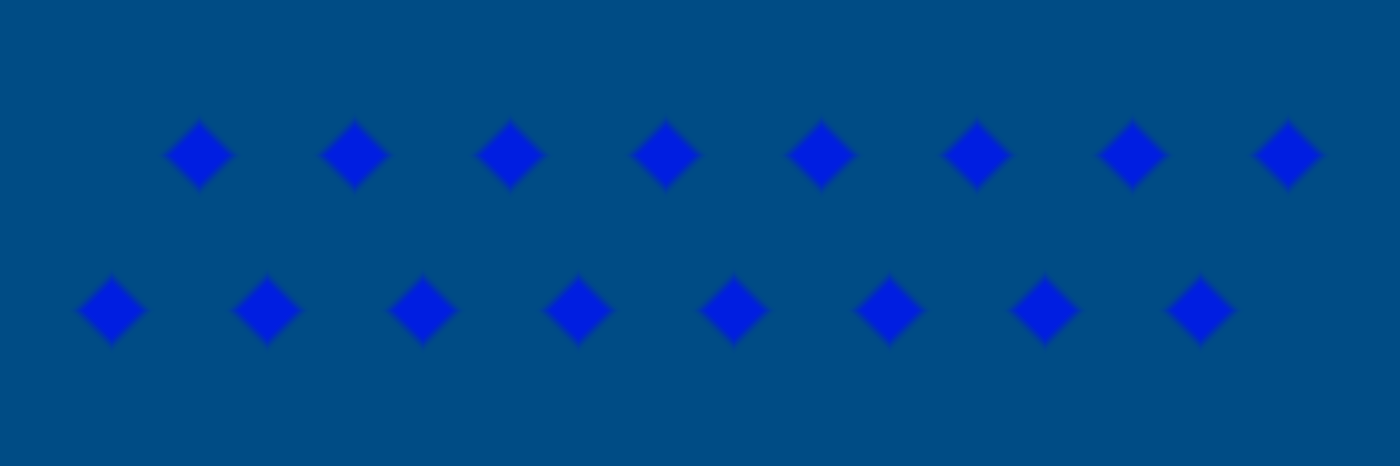

shape_mode=polygon, n_sides=3
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


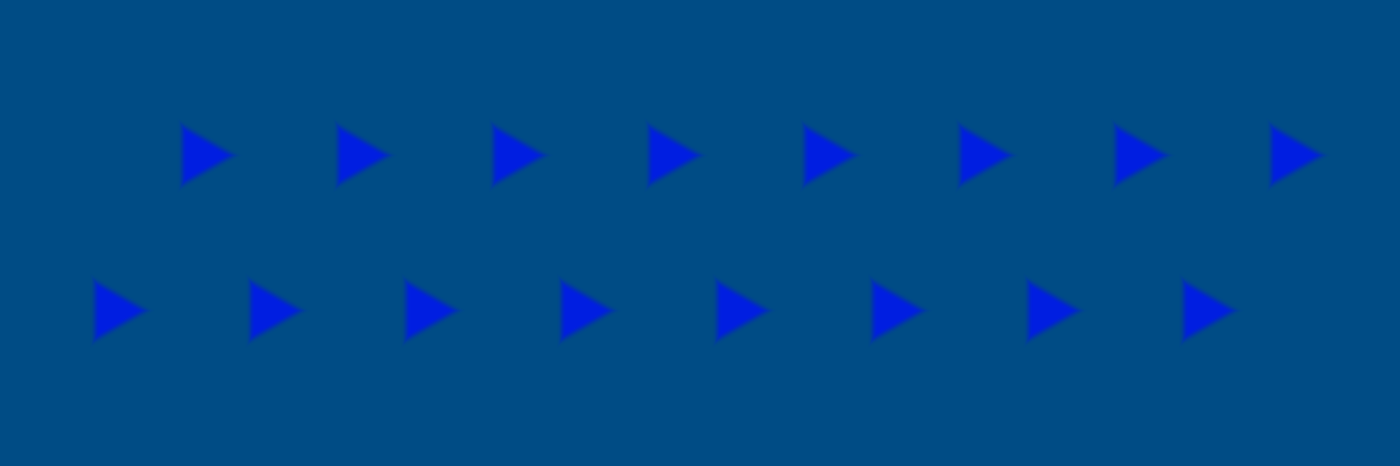

shape_mode=polygon, n_sides=4
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


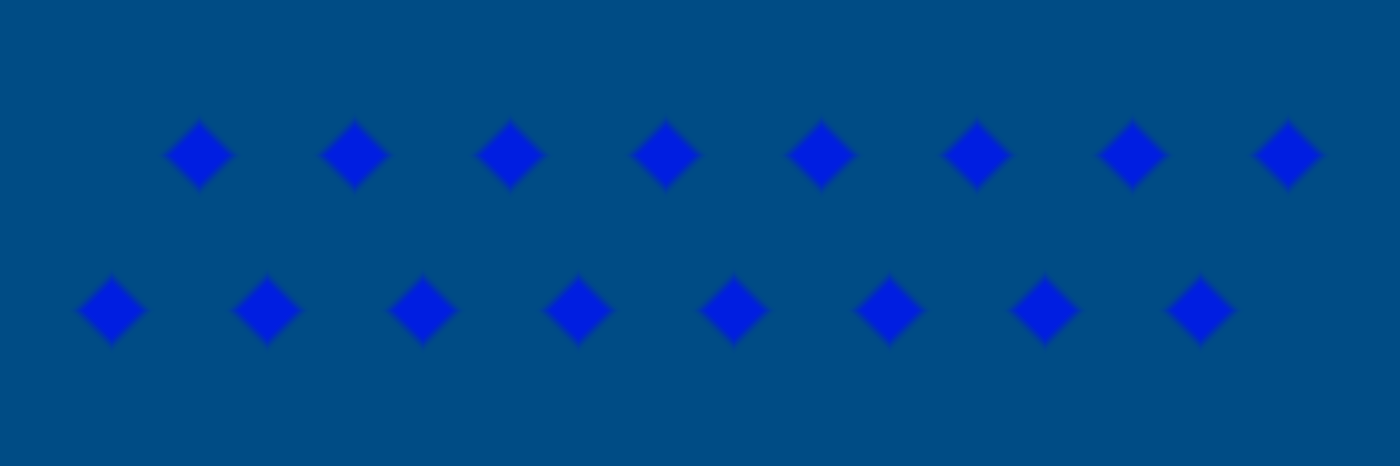

shape_mode=polygon, n_sides=5
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


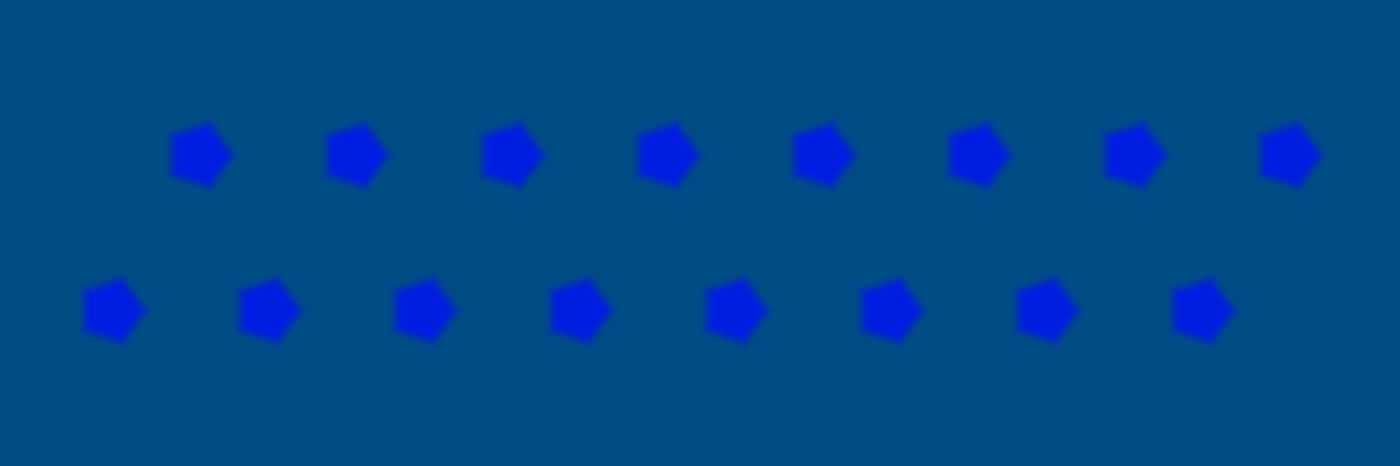

shape_mode=polygon, n_sides=6
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


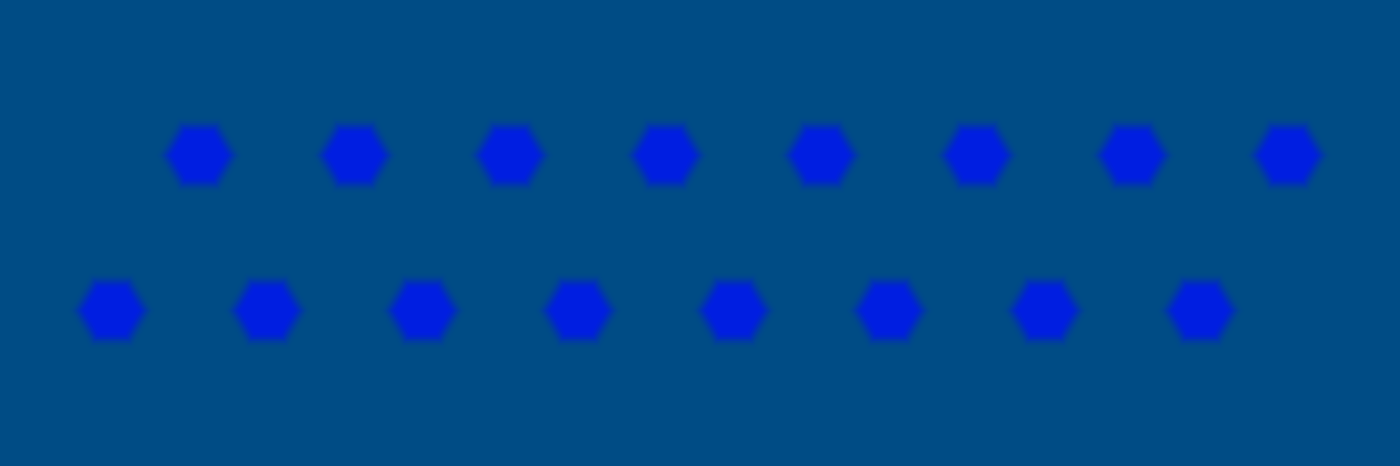

shape_mode=polygon, n_sides=8
rgb_ref=array([0.  , 0.3 , 0.52]), rgb=array([0.  , 0.12, 0.89]), lambda_ref_mean=473.00, lambda_ref_std=80.00, lambda_dev=-0.00, lambda_std=2.00


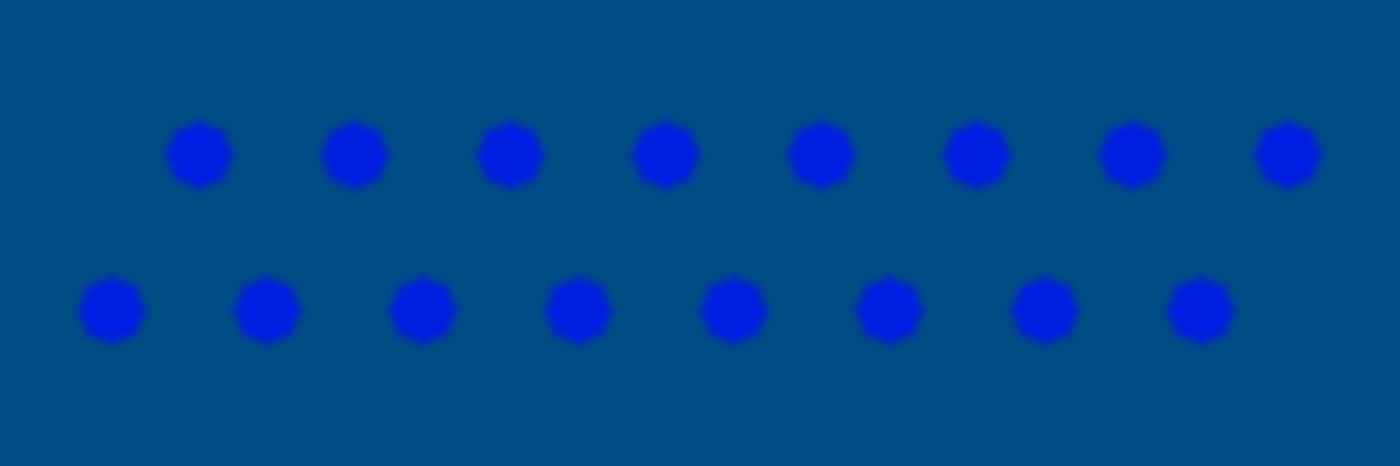

In [48]:
# Exploration of different shape families
opts_ = opts.copy()
# opts_.update(size_mag=.5, N_H=max(6, N_H//2), N_W=max(6, N_W//2))

shape_configs = [
    ('random', 6),
    ('circle', 6),
    ('diagonal', 4),
    ('polygon', 3),
    ('polygon', 4),
    ('polygon', 5),
    ('polygon', 6),
    ('polygon', 8),
]

for shape_mode_, n_sides_ in shape_configs:
    opts_.update(shape_mode=shape_mode_, n_sides=n_sides_)
    print(f'shape_mode={shape_mode_}, n_sides={n_sides_}')

    @disp
    def draw(cr, N_height=N_height, N_width=N_width):
        cr = hexagonal_grid(cr, **opts_)


## Discussion and Conclusion

The results of these parameter sweeps demonstrate that the ambiguity illusion is most potent when the stimulus sits precisely at a perceptual threshold. By jointly tuning dot size, chromatic deviation ($\lambda_{dev}$), lattice density, and shape complexity, we can create an image where central segmentation is reliable while peripheral structure remains unstable.

This behavior is entirely coherent with retinal physiology:
- **Foveal/Parafoveal Processing:** High cone density enables the fine spatial and chromatic discrimination required to resolve individual dots against the background.
- **Peripheral Processing:** Rod dominance and larger receptive field pooling lead to a "smoothing" effect, where the dot lattice is perceived as a coarse, continuous texture.

In practical terms, the illusion's strength depends on preventing the dots from becoming either globally invisible (too small/low contrast) or globally obvious (too large/high contrast). The macular scale—roughly the apparent size of a thumb at arm's length—provides a reliable perceptual anchor for where this high-fidelity parsing should remain stable.

**Future Directions:**
The next logical step is to move from qualitative observation to quantitative psychophysics. This would involve measuring dot detectability as a function of eccentricity and mapping the precise multi-dimensional parameter region that maximizes the delta between central and peripheral perception.

## some book keeping for the notebook

In [43]:
%pwd

'/Users/laurentperrinet/sdrive_cnrs/blog/laurentperrinet.github.io_sciblog/posts'

In [44]:
%load_ext watermark
%watermark -i -h -m -v -p numpy,cairo  -r -g -b

Python implementation: CPython
Python version       : 3.14.7
IPython version      : 9.16.0

numpy: 2.5.1
cairo: unknown

Compiler    : Clang 17.0.0 (clang-1700.6.4.2)
OS          : Darwin
Release     : 24.6.0
Machine     : x86_64
Processor   : i386
CPU cores   : 36
Architecture: 64bit

Hostname: Ahsoka

Git hash: 593362f28722650ae71e22e4b7d0f03f2708a531

Git repo: https://github.com/laurentperrinet/sciblog

Git branch: master

